# Исследование: ИТ-сбои цифровых сервисов и реакция фондового рынка
## Анализ пользовательских жалоб с Downdetector.ru и рыночных данных MOEX

---

**Структура ноутбука:**
- **Этап A.** Аудит и описание исходных данных
- **Этап B.** Подготовка и агрегация жалоб
- **Этап C.** Анализ текстов и вспомогательных метаданных
- **Этап D.** Подготовка рыночных данных
- **Этап E.** Детектирование outage-like событий
- **Модель 1.** Event Study
- **Модель 2.** Панельная эконометрическая модель



Удаляю ненужные компании ( по ним нет эмитетов)

In [1]:
# import pandas as pd
# import os

# GRAPH_PATH = "graph_data.csv"
# MESSAGES_PATH = "user_messages.csv"
# CLOUD_TAGS_PATH = "cloud_tags.csv"
# HISTOGRAMS_PATH = "histograms.csv"

# # Компании, которые нужно удалить
# exclude_companies = [
#     "alfa-bank", "avito", "aliekspress", "discord", "financeozon",
#     "maxru", "megafon", "psb", "steam", "telegram", "whatsapp", "wildberries"
# ]

# def load_and_filter(path):
#     df = pd.read_csv(path,encoding="utf-8-sig", sep=';')
#     df.columns = [col.strip() for col in df.columns]
#     if "Компания" not in df.columns:
#         raise ValueError(f"В файле {path} нет столбца 'Компания'")   
#     df["Компания_clean"] = df["Компания"].astype(str).str.strip().str.lower()
#     df = df[~df["Компания_clean"].isin(exclude_companies)].copy()   
#     df.drop(columns=["Компания_clean"], inplace=True)    
#     return df


# graph_data = load_and_filter(GRAPH_PATH)
# user_messages = load_and_filter(MESSAGES_PATH)
# cloud_tags = load_and_filter(CLOUD_TAGS_PATH)
# histograms = load_and_filter(HISTOGRAMS_PATH)


# os.makedirs("processed_data", exist_ok=True)

# graph_data.to_csv("processed_data/graph_data_cleaned.csv",encoding="utf-8-sig", index=False)
# user_messages.to_csv("processed_data/user_messages_cleaned.csv", encoding="utf-8-sig", index=False)
# cloud_tags.to_csv("processed_data/cloud_tags_cleaned.csv", encoding="utf-8-sig", index=False)
# histograms.to_csv("processed_data/histograms_cleaned.csv", encoding="utf-8-sig", index=False)



## 0. Конфигурация и глобальные параметры

Все ключевые параметры, словари сопоставлений и пути к файлам вынесены в единый блок конфигурации

In [2]:

%pip install pandas numpy matplotlib seaborn scipy statsmodels
%pip install scikit-learn xgboost lightgbm openpyxl
%pip install linearmodels pingouin

import warnings
warnings.filterwarnings('ignore')

import os
import re
import json
from pathlib import Path
from datetime import date, timedelta
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac
from sklearn.linear_model import LogisticRegression, ElasticNet
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, TimeSeriesSplit
from sklearn.metrics import (roc_auc_score, classification_report,
                              roc_curve, precision_recall_curve, f1_score,
                              precision_score, recall_score)
from sklearn.pipeline import Pipeline
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('Все библиотеки успешно импортированы.')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Все библиотеки успешно импортированы.


In [3]:
DATA_DIR   = Path('.')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

FILES = {
    'graph_data'   : DATA_DIR / 'graph_data.csv',
    'user_messages': DATA_DIR / 'user_messages.csv',
    'cloud_tags'   : DATA_DIR / 'cloud_tags.csv',
    'histograms'   : DATA_DIR / 'histograms.csv',
    'stock_prices' : DATA_DIR / 'Цены_акций.csv',
}

COMPANY_DISPLAY = {
    'sberbank'     : 'Сбербанк',
    'tinkoff'      : 'Тинькофф',
    'bank-vtb'     : 'ВТБ',
    'gazprombank'  : 'Газпромбанк',
    'mts'          : 'МТС',
    'tele2'        : 'Tele2',
    'rostelekom'   : 'Ростелеком',
    'bilajn'       : 'Билайн',
    'vkontakte'    : 'VK',
    'odnoklassniki': 'Одноклассники',
    'ozon'         : 'Ozon',
    'marketyandex' : 'Яндекс Маркет',
    'financeozon'  : 'Finance Ozon',
    'maxru'        : 'Mail.ru / Max',
}

SERVICE_TO_ISSUER = {
    'sberbank'     : 'sberbank',
    'tinkoff'      : 'tinkoff',
    'bank-vtb'     : 'bank-vtb',
    'gazprombank'  : 'gazprombank',
    'mts'          : 'mts',
    'tele2'        : 'rostelekom',    
    'rostelekom'   : 'rostelekom',
    'bilajn'       : None,            # нет бумаги -> исключается из рын. моделей
    'vkontakte'    : 'vkontakte',
    'odnoklassniki': 'vkontakte',    
    'ozon'         : 'ozon',
    'marketyandex' : 'marketyandex',
    'financeozon'  : 'ozon',          
    'maxru'        : 'vkontakte',     
}

SECTOR_MAP = {
    'sberbank'     : 'Банки',
    'tinkoff'      : 'Банки',
    'bank-vtb'     : 'Банки',
    'gazprombank'  : 'Банки',
    'mts'          : 'Телеком',
    'tele2'        : 'Телеком',
    'rostelekom'   : 'Телеком',
    'bilajn'       : 'Телеком',
    'vkontakte'    : 'Соцсети',
    'odnoklassniki': 'Соцсети',
    'ozon'         : 'Маркетплейсы',
    'marketyandex' : 'Маркетплейсы',
    'financeozon'  : 'Банки',
    'maxru'        : 'Соцсети',
}

SYSTEMIC_BANKING_OUTAGES = [
    pd.Timestamp('2025-12-29'),
    pd.Timestamp('2026-04-03'),
]
OZON_RESTRUCTURING_DATE = pd.Timestamp('2025-09-26')

MOEX_HOLIDAYS = set([
    date(2025, 1, 1), date(2025, 1, 2), date(2025, 1, 7),
    date(2025, 2, 23), date(2025, 3, 8),
    date(2025, 5, 1), date(2025, 5, 9),
    date(2025, 6, 12), date(2025, 11, 4), date(2025, 12, 31),
    date(2026, 1, 1), date(2026, 1, 2), date(2026, 1, 3), date(2026, 1, 4),
    date(2026, 1, 7),
    date(2026, 2, 23), date(2026, 3, 8),
    date(2026, 5, 1), date(2026, 5, 9),
    date(2026, 6, 12), date(2026, 11, 4), date(2026, 12, 31),
])

MOEX_TRADING_HOURS = list(range(7, 24))  # 7:00 – 23:00

def is_trading_day(d):
    if isinstance(d, pd.Timestamp):
        d = d.date()
    return (d.weekday() < 5) and (d not in MOEX_HOLIDAYS)
EVENT_PERCENTILE_MAIN = 95
EVENT_PERCENTILE_ALT1 = 97.5
EVENT_Z_THRESHOLD     = 2.5


ESTIMATION_WINDOW = (-55, -6)
EVENT_WINDOWS = {
    '[0]'      : (0,  0),
    '[0;+1]'   : (0,  1),
    '[-1;+1]'  : (-1, 1),
    '[-2;+2]'  : (-2, 2),
}

print('Конфигурация загружена.')
print(f'Компаний с маппингом: {len(COMPANY_DISPLAY)}')
print(f'Выходная папка: {OUTPUT_DIR.resolve()}')


Конфигурация загружена.
Компаний с маппингом: 14
Выходная папка: D:\Home\Downloads\ВКР\outputs


---
## ЭТАП A. Аудит и описание исходных данных


In [4]:
def load_graph_data(path):
    """Загрузка graph_data.csv с разбором почасового datetime."""
    df = pd.read_csv(path, encoding='utf-8-sig')
    df.columns = df.columns.str.strip()
    rename_map = {
        'Компания'      : 'company_raw',
        'Дата парсинга' : 'date_raw',
        'Время'         : 'time_raw',
        'Жалобы'        : 'complaints',
        'Сбои'          : 'failures',
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
    df['company_raw'] = df['company_raw'].str.strip().str.lower()

    # Дата
    df['date'] = pd.to_datetime(df['date_raw'], dayfirst=True, errors='coerce')

    # Извлекаем час из time_raw (формат HH:MM:SS или H:MM)
    if 'time_raw' in df.columns:
        df['hour'] = (pd.to_datetime(df['time_raw'], format='%H:%M:%S', errors='coerce')
                      .dt.hour
                      .fillna(
                          pd.to_datetime(df['time_raw'], errors='coerce').dt.hour
                      ).astype('Int64'))
    else:
        df['hour'] = pd.NA

    df['datetime_hour'] = df['date'] + pd.to_timedelta(df['hour'].fillna(0).astype(int), unit='h')

    df['complaints'] = pd.to_numeric(df['complaints'], errors='coerce').fillna(0)
    df['failures']   = pd.to_numeric(df['failures'],   errors='coerce').fillna(0)
    return df


def load_user_messages(path):
    """Загрузка user_messages.csv."""
    df = pd.read_csv(path, encoding='utf-8-sig')
    df.columns = df.columns.str.strip()
    rename_map = {
        'Компания'      : 'company_raw',
        'Дата парсинга' : 'date_raw',
        'Время'         : 'time_raw',
        'Ник'           : 'user_nick',
        'Комментарий'   : 'comment',
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
    df['company_raw'] = df['company_raw'].str.strip().str.lower()
    df['date'] = pd.to_datetime(df['date_raw'], dayfirst=True, errors='coerce')
    df['comment'] = df['comment'].fillna('').astype(str)
    return df


def load_cloud_tags(path):
    """Загрузка cloud_tags.csv."""
    df = pd.read_csv(path, encoding='utf-8-sig')
    df.columns = df.columns.str.strip()
    rename_map = {
        'Компания'      : 'company_raw',
        'Дата парсинга' : 'date_raw',
        'Слово'         : 'word',
        'Частота'       : 'frequency',
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
    df['company_raw'] = df['company_raw'].str.strip().str.lower()
    df['date'] = pd.to_datetime(df['date_raw'], dayfirst=True, errors='coerce')
    df['frequency'] = pd.to_numeric(df['frequency'], errors='coerce').fillna(0)
    return df


def load_histograms(path):
    """Загрузка histograms.csv."""
    df = pd.read_csv(path, encoding='utf-8-sig')
    df.columns = df.columns.str.strip()
    rename_map = {
        'Компания'      : 'company_raw',
        'Дата парсинга' : 'date_raw',
        'Тип'           : 'category_type',
        'Название'      : 'category_name',
        'Процент'       : 'pct',
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
    df['company_raw'] = df['company_raw'].str.strip().str.lower()
    df['date'] = pd.to_datetime(df['date_raw'], dayfirst=True, errors='coerce')
    df['pct'] = pd.to_numeric(df['pct'], errors='coerce').fillna(0)
    return df


def load_stock_prices(path):
    df = pd.read_csv(path, encoding='cp1251', sep=';')
    df.columns = df.columns.str.strip()

    rename_map = {
        'Компания' : 'issuer_name',
        'Дата'     : 'date_raw',
        'Время'    : 'time_raw',
        'Первая'   : 'price_open',
        'Максимум' : 'price_high',
        'Минимум'  : 'price_low',
        'Закрытия' : 'close_price',
        'Объем'    : 'volume',
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
    df['issuer_name'] = df['issuer_name'].astype(str).str.strip().str.lower()

    num_cols = ['price_open', 'price_high', 'price_low', 'close_price']
    for col in num_cols:
        if col in df.columns:
            df[col] = (df[col].astype(str)
                       .str.replace('\xa0', '', regex=False)
                       .str.replace(' ', '', regex=False)
                       .str.replace(',', '.', regex=False)
                       .replace(['', 'nan', 'None'], np.nan))
            df[col] = pd.to_numeric(df[col], errors='coerce')

    if 'volume' in df.columns:
        df['volume'] = pd.to_numeric(
            df['volume'].astype(str).str.replace(' ', '').str.replace('\xa0', ''),
            errors='coerce')

    df['date'] = pd.to_datetime(df['date_raw'], dayfirst=True, errors='coerce')
    df['hour'] = (pd.to_datetime(df['time_raw'], format='%H:%M:%S', errors='coerce')
                  .dt.hour
                  .fillna(pd.to_datetime(df['time_raw'], errors='coerce').dt.hour)
                  .astype('Int64'))

    df['datetime_hour'] = df['date'] + pd.to_timedelta(df['hour'].fillna(0).astype(int), unit='h')

    return df


print('Загружаем файлы...')
graph_data    = load_graph_data(FILES['graph_data'])
user_messages = load_user_messages(FILES['user_messages'])
cloud_tags    = load_cloud_tags(FILES['cloud_tags'])
histograms    = load_histograms(FILES['histograms'])
stock_prices  = load_stock_prices(FILES['stock_prices'])

for df in [graph_data, user_messages, cloud_tags, histograms]:
    df['company_display'] = df['company_raw'].map(COMPANY_DISPLAY)
    df['sector']          = df['company_raw'].map(SECTOR_MAP)
    df['issuer_name']     = df['company_raw'].map(SERVICE_TO_ISSUER)

print(f'graph_data    : {len(graph_data):>8,} строк | часов/компании: ~{len(graph_data)//max(1,graph_data["company_raw"].nunique()):,}')
print(f'user_messages : {len(user_messages):>8,} строк')
print(f'cloud_tags    : {len(cloud_tags):>8,} строк')
print(f'histograms    : {len(histograms):>8,} строк')
print(f'stock_prices  : {len(stock_prices):>8,} строк (почасовые)')
print(f'\nЭмитенты в файле акций: {sorted(stock_prices["issuer_name"].unique())}')
print(f'Период акций: {stock_prices["date"].min().date()} → {stock_prices["date"].max().date()}')
print(f'Торговые часы: {sorted(stock_prices["hour"].dropna().astype(int).unique())}')


Загружаем файлы...
graph_data    :  328,850 строк | часов/компании: ~23,489
user_messages :  144,097 строк
cloud_tags    :    7,468 строк
histograms    :   12,664 строк
stock_prices  :   13,208 строк (почасовые)

Эмитенты в файле акций: ['bank-vtb', 'gazprombank', 'marketyandex', 'mts', 'ozon', 'rostelekom', 'sberbank', 'tinkoff', 'vkontakte']
Период акций: 2025-12-22 → 2026-04-09
Торговые часы: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


In [5]:
table_a1 = pd.DataFrame([
    ['graph_data.csv',    'company_raw, date, time, complaints, failures',
     'Внутридневная', str(graph_data['date'].min().date())+' — '+str(graph_data['date'].max().date()),
     'Основной источник жалоб и сбоев'],
    ['user_messages.csv', 'company_raw, date, time, user_nick, comment',
     'Внутридневная', str(user_messages['date'].min().date())+' — '+str(user_messages['date'].max().date()),
     'Текстовые комментарии пользователей'],
    ['cloud_tags.csv',    'company_raw, date, word, frequency',
     'Дневная',       str(cloud_tags['date'].min().date())+' — '+str(cloud_tags['date'].max().date()),
     'Облако частотных тегов'],
    ['histograms.csv',    'company_raw, date, category_type, category_name, pct',
     'Дневная',       str(histograms['date'].min().date())+' — '+str(histograms['date'].max().date()),
     'Распределение жалоб по категориям'],
    ['Цены_акций.csv',   'issuer_name, date, close_price, volume, ...',
     'Дневная',       str(stock_prices['date'].min().date())+' — '+str(stock_prices['date'].max().date()),
     'Рыночные данные MOEX'],
], columns=['Источник', 'Переменные', 'Частота', 'Период', 'Роль'])

display(table_a1)
table_a1.to_csv(OUTPUT_DIR / 'Table_A1_Sources.csv', index=False, encoding='utf-8-sig')
print('Таблица A1 сохранена.')

,Источник,Переменные,Частота,Период,Роль
0,graph_data.csv,"company_raw, date, time, complaints, failures",Внутридневная,2025-12-22 — 2026-04-09,Основной источник жалоб и сбоев
1,user_messages.csv,"company_raw, date, time, user_nick, comment",Внутридневная,2025-12-23 — 2026-04-09,Текстовые комментарии пользователей
2,cloud_tags.csv,"company_raw, date, word, frequency",Дневная,2025-12-23 — 2026-04-09,Облако частотных тегов
3,histograms.csv,"company_raw, date, category_type, category_nam...",Дневная,2025-12-23 — 2026-04-09,Распределение жалоб по категориям
4,Цены_акций.csv,"issuer_name, date, close_price, volume, ...",Дневная,2025-12-22 — 2026-04-09,Рыночные данные MOEX


Таблица A1 сохранена.


In [6]:
table_a2_rows = []
for raw, display_name in COMPANY_DISPLAY.items():
    issuer  = SERVICE_TO_ISSUER.get(raw, '—')
    sector  = SECTOR_MAP.get(raw, '—')
    note = ''
    if raw == 'odnoklassniki':
        note = 'Нет отдельных акций; используются данные VK'
    elif raw == 'gazprombank':
        note = 'Проверить наличие котируемой бумаги в выборке'
    elif raw == 'bilajn':
        note = 'Прямая бумага может отсутствовать; методол. комментарий'
    elif raw == 'tele2':
        note = 'Прямая бумага может отсутствовать; методол. комментарий'
    table_a2_rows.append([raw, display_name, sector, issuer, note])

table_a2 = pd.DataFrame(table_a2_rows,
    columns=['company_raw', 'Сервис (отображение)', 'Сектор', 'Эмитент (акции)', 'Примечание'])
display(table_a2)
table_a2.to_csv(OUTPUT_DIR / 'Table_A2_ServiceIssuerMapping.csv', index=False, encoding='utf-8-sig')
print('Таблица A2 сохранена.')

,company_raw,Сервис (отображение),Сектор,Эмитент (акции),Примечание
0,sberbank,Сбербанк,Банки,sberbank,
1,tinkoff,Тинькофф,Банки,tinkoff,
2,bank-vtb,ВТБ,Банки,bank-vtb,
3,gazprombank,Газпромбанк,Банки,gazprombank,Проверить наличие котируемой бумаги в выборке
4,mts,МТС,Телеком,mts,
5,tele2,Tele2,Телеком,rostelekom,Прямая бумага может отсутствовать; методол. ко...
6,rostelekom,Ростелеком,Телеком,rostelekom,
7,bilajn,Билайн,Телеком,NaN,Прямая бумага может отсутствовать; методол. ко...
8,vkontakte,VK,Соцсети,vkontakte,
9,odnoklassniki,Одноклассники,Соцсети,vkontakte,Нет отдельных акций; используются данные VK


Таблица A2 сохранена.


In [7]:
coverage_rows = []
for company in COMPANY_DISPLAY:
    sub = graph_data[graph_data['company_raw'] == company]
    msg_sub = user_messages[user_messages['company_raw'] == company]
    if len(sub) == 0:
        continue
    coverage_rows.append({
        'Сервис'            : COMPANY_DISPLAY[company],
        'Сектор'            : SECTOR_MAP[company],
        'Первая дата'       : sub['date'].min().date(),
        'Последняя дата'    : sub['date'].max().date(),
        'Число дней'        : sub['date'].dt.date.nunique(),
        'Число точек'       : len(sub),
        'Жалоб (сумма)'     : int(sub['complaints'].sum()),
        'Комментариев'      : len(msg_sub),
        'Пропуски жалоб, %' : round(sub['complaints'].isna().mean() * 100, 2),
    })

table_a3 = pd.DataFrame(coverage_rows)
display(table_a3)
table_a3.to_csv(OUTPUT_DIR / 'Table_A3_Coverage.csv', index=False, encoding='utf-8-sig')
print('Таблица A3 сохранена.')

,Сервис,Сектор,Первая дата,Последняя дата,Число дней,Число точек,Жалоб (сумма),Комментариев,"Пропуски жалоб, %"
0,Сбербанк,Банки,2025-12-22,2026-04-09,109,24358,165435,17800,0.0000
1,Тинькофф,Банки,2025-12-22,2026-04-09,109,24358,116660,9665,0.0000
2,ВТБ,Банки,2025-12-23,2026-04-09,108,23946,41899,9219,0.0000
3,Газпромбанк,Банки,2025-12-23,2026-04-09,108,23848,9224,2131,0.0000
4,МТС,Телеком,2025-12-23,2026-04-09,108,23750,84279,16751,0.0000
5,Tele2,Телеком,2025-12-23,2026-04-09,107,23750,58178,12708,0.0000
6,Ростелеком,Телеком,2025-12-23,2026-04-09,107,23652,186301,25274,0.0000
7,Билайн,Телеком,2025-12-23,2026-04-09,105,23142,86227,16731,0.0000
8,VK,Соцсети,2025-12-23,2026-04-09,105,22926,96703,13363,0.0000
9,Одноклассники,Соцсети,2025-12-24,2026-04-09,106,22808,16600,2934,0.0000


Таблица A3 сохранена.


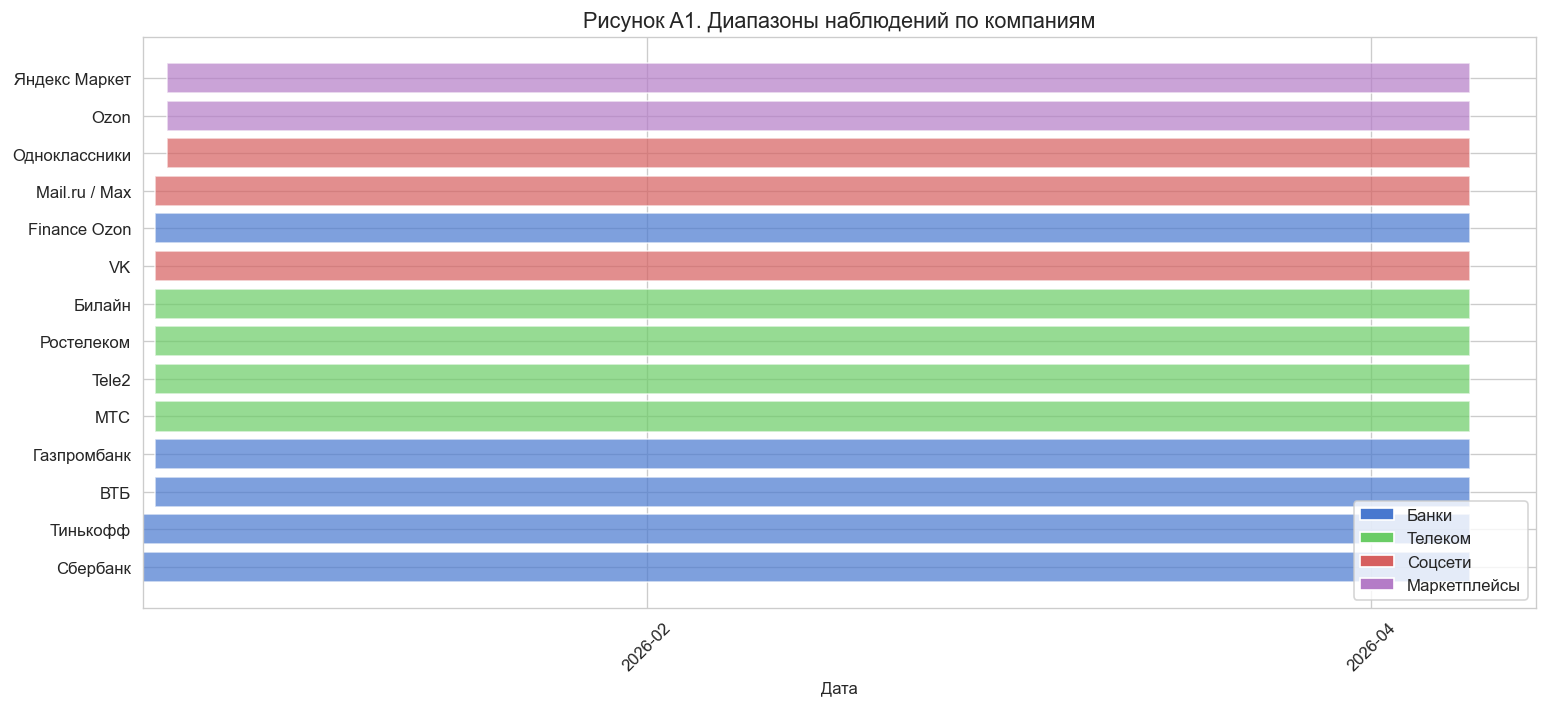

Рисунок A1 сохранён.


In [8]:
fig, ax = plt.subplots(figsize=(13, 6))

companies_sorted = table_a3.sort_values('Первая дата')['Сервис'].tolist()
color_sector = {'Банки': '#4878CF', 'Телеком': '#6ACC65', 'Соцсети': '#D65F5F', 'Маркетплейсы': '#B47CC7'}

for i, row in table_a3.sort_values('Первая дата').iterrows():
    start = pd.Timestamp(row['Первая дата'])
    end   = pd.Timestamp(row['Последняя дата'])
    color = color_sector.get(row['Сектор'], 'grey')
    ax.barh(row['Сервис'], (end - start).days, left=start, color=color, alpha=0.7, edgecolor='white')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.set_xlabel('Дата')
ax.set_title('Рисунок A1. Диапазоны наблюдений по компаниям', fontsize=13)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in color_sector.items()]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Fig_A1_CoverageGantt.png', dpi=150)
plt.show()
print('Рисунок A1 сохранён.')

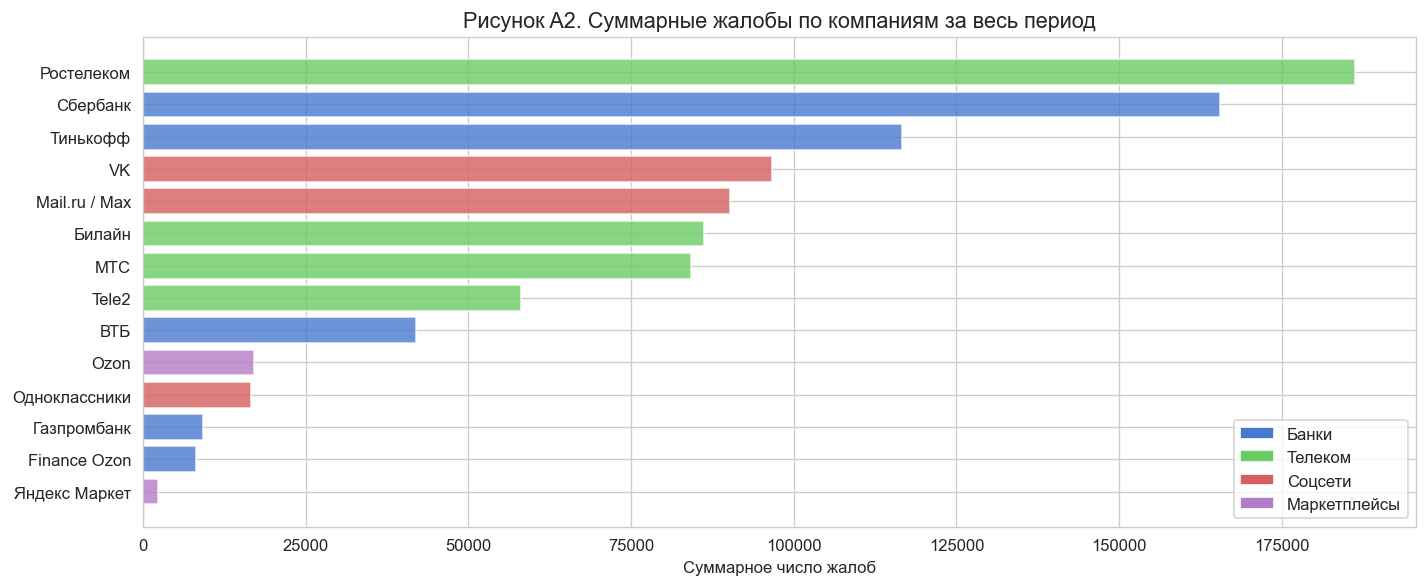

Рисунок A2 сохранён.


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_df = table_a3.sort_values('Жалоб (сумма)', ascending=True)
colors  = [color_sector.get(s, 'grey') for s in plot_df['Сектор']]
ax.barh(plot_df['Сервис'], plot_df['Жалоб (сумма)'], color=colors, alpha=0.8, edgecolor='white')
ax.set_xlabel('Суммарное число жалоб')
ax.set_title('Рисунок A2. Суммарные жалобы по компаниям за весь период', fontsize=13)
legend_elements = [Patch(facecolor=c, label=s) for s, c in color_sector.items()]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Fig_A2_TotalComplaints.png', dpi=150)
plt.show()
print('Рисунок A2 сохранён.')

## ЭТАП B. Подготовка и агрегация жалоб



In [10]:
def build_daily_complaints(df):
    grp = df.groupby(['company_raw', 'date'])
    d = grp.agg(
        complaints_sum   = ('complaints', 'sum'),
        complaints_max   = ('complaints', 'max'),
        complaints_mean  = ('complaints', 'mean'),
        complaints_std   = ('complaints', 'std'),
        complaints_n_pts = ('complaints', 'count'),
        failures_sum     = ('failures',   'sum'),
        failures_any     = ('failures',   lambda x: int((x > 0).any())),
    ).reset_index()
    d['complaints_std']   = d['complaints_std'].fillna(0)
    d['company_display']  = d['company_raw'].map(COMPANY_DISPLAY)
    d['sector']           = d['company_raw'].map(SECTOR_MAP)
    d['issuer_name']      = d['company_raw'].map(SERVICE_TO_ISSUER)
    return d


def build_hourly_complaints(df):
    grp = df.groupby(['company_raw', 'datetime_hour'])
    h = grp.agg(
        complaints_sum   = ('complaints', 'sum'),
        complaints_max   = ('complaints', 'max'),
        complaints_mean  = ('complaints', 'mean'),
        complaints_std   = ('complaints', 'std'),
        complaints_n_pts = ('complaints', 'count'),
        failures_sum     = ('failures',   'sum'),
        failures_any     = ('failures',   lambda x: int((x > 0).any())),
    ).reset_index()
    h['complaints_std']  = h['complaints_std'].fillna(0)
    h['company_display'] = h['company_raw'].map(COMPANY_DISPLAY)
    h['sector']          = h['company_raw'].map(SECTOR_MAP)
    h['issuer_name']     = h['company_raw'].map(SERVICE_TO_ISSUER)
    h['date'] = h['datetime_hour'].dt.normalize()
    h['hour'] = h['datetime_hour'].dt.hour
    return h

daily  = build_daily_complaints(graph_data)
hourly = build_hourly_complaints(graph_data)

print(f'Дневная панель  : {len(daily):,} строк  | компаний: {daily["company_raw"].nunique()}')
print(f'Почасовая панель: {len(hourly):,} строк | компаний: {hourly["company_raw"].nunique()}')
print(f'Среднее часов/компания: {len(hourly)/hourly["company_raw"].nunique():.0f}')


Дневная панель  : 1,499 строк  | компаний: 14
Почасовая панель: 34,440 строк | компаний: 14
Среднее часов/компания: 2460


In [11]:
msg_daily = user_messages.groupby(['company_raw', 'date']).agg(
    comments_count = ('comment', 'count'),
    unique_users   = ('user_nick', 'nunique'),
).reset_index()

daily = daily.merge(msg_daily, on=['company_raw', 'date'], how='left')
daily['comments_count'] = daily['comments_count'].fillna(0).astype(int)
daily['unique_users']   = daily['unique_users'].fillna(0).astype(int)

if 'time_raw' in user_messages.columns:
    user_messages['hour'] = (
        pd.to_datetime(user_messages['time_raw'], format='%H:%M:%S', errors='coerce')
        .dt.hour
        .fillna(pd.to_datetime(user_messages['time_raw'], errors='coerce').dt.hour)
        .astype('Int64'))
    user_messages['datetime_hour'] = (user_messages['date']
        + pd.to_timedelta(user_messages['hour'].fillna(0).astype(int), unit='h'))

    msg_hourly = user_messages.groupby(['company_raw', 'datetime_hour']).agg(
        comments_count = ('comment', 'count'),
        unique_users   = ('user_nick', 'nunique'),
    ).reset_index()
    hourly = hourly.merge(msg_hourly, on=['company_raw', 'datetime_hour'], how='left')
else:
    hourly['comments_count'] = 0
    hourly['unique_users']   = 0

hourly['comments_count'] = hourly['comments_count'].fillna(0).astype(int)
hourly['unique_users']   = hourly['unique_users'].fillna(0).astype(int)

print(f'Дневная  панель с комментариями: {len(daily):,} строк')
print(f'Почасовая панель с комментариями: {len(hourly):,} строк')


Дневная  панель с комментариями: 1,499 строк
Почасовая панель с комментариями: 34,440 строк


In [12]:
def add_calendar_features(df, datetime_col='datetime_hour'):
    d = df.copy()
    dt = d[datetime_col]

    d['date']        = dt.dt.normalize()
    d['hour']        = dt.dt.hour
    d['day_of_week'] = dt.dt.dayofweek          # 0=Пн
    d['is_monday']   = (d['day_of_week'] == 0).astype(int)
    d['is_friday']   = (d['day_of_week'] == 4).astype(int)
    d['month']       = dt.dt.month
    d['quarter']     = dt.dt.quarter
    d['season']      = d['month'].map(
        {12:'Зима',1:'Зима',2:'Зима',3:'Весна',4:'Весна',5:'Весна',
         6:'Лето',7:'Лето',8:'Лето',9:'Осень',10:'Осень',11:'Осень'})
    d['is_weekend']  = (d['day_of_week'] >= 5).astype(int)
    d['is_trading_hour'] = d['hour'].apply(
        lambda h: int(h in MOEX_TRADING_HOURS)).astype(int)
    d['is_trading_day']  = d['date'].apply(lambda x: int(is_trading_day(x)))

    d['is_morning_session']  = d['hour'].between(7, 11).astype(int)   
    d['is_afternoon_session']= d['hour'].between(12, 17).astype(int)  
    d['is_evening_session']  = d['hour'].between(18, 23).astype(int)  

    d['is_pre_holiday']  = d['date'].apply(
        lambda x: int(not is_trading_day(x + pd.Timedelta(days=1))))
    d['is_post_holiday'] = d['date'].apply(
        lambda x: int(not is_trading_day(x - pd.Timedelta(days=1))))
    return d

def add_load_features(df):
    d = df.copy()
    dom = d['date'].dt.day if 'date' in d.columns else d['datetime_hour'].dt.day
    d['end_of_month']       = (dom >= 28).astype(int)
    d['beginning_of_month'] = (dom <= 3).astype(int)
    d['salary_period']      = dom.apply(
        lambda x: int(x in [4,5,6,9,10,11,19,20,21,24,25,26,27,28,29,30]))
    d['pre_new_year']   = ((d['month'] == 12) & (dom >= 20)).astype(int)
    d['back_to_school'] = d['month'].isin([8, 9]).astype(int)
    d['holiday_shopping']= d['month'].isin([11, 12]).astype(int)
    return d

def add_lag_rolling_features_hourly(df, group_col='company_raw'):
    """Лаги по ЧАСАМ (предыдущий час = lag1)."""
    d = df.sort_values(['company_raw', 'datetime_hour']).copy()
    for lag in [1, 2, 3, 6, 24]:  
        d[f'complaints_lag{lag}h'] = d.groupby(group_col)['complaints_sum'].shift(lag)
    d['rolling_mean_24h'] = d.groupby(group_col)['complaints_sum'].transform(
        lambda x: x.shift(1).rolling(24,  min_periods=6).mean())
    d['rolling_mean_72h'] = d.groupby(group_col)['complaints_sum'].transform(
        lambda x: x.shift(1).rolling(72, min_periods=12).mean())
    d['rolling_std_24h']  = d.groupby(group_col)['complaints_sum'].transform(
        lambda x: x.shift(1).rolling(24,  min_periods=6).std())
    d['complaint_growth_1h'] = d.groupby(group_col)['complaints_sum'].pct_change(1)
    d['complaint_growth_24h']= d.groupby(group_col)['complaints_sum'].pct_change(24)
    d['z_score_company'] = d.groupby(group_col)['complaints_sum'].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-6))
    d['percentile_rank_company'] = d.groupby(group_col)['complaints_sum'].transform(
        lambda x: x.rank(pct=True))
    return d

def add_systemic_dummies(df):
    d = df.copy()
    dt_dates = d['datetime_hour'].dt.normalize() if 'datetime_hour' in d.columns else d['date']
    d['systemic_banking_outage'] = dt_dates.isin(
        pd.DatetimeIndex(SYSTEMIC_BANKING_OUTAGES)).astype(int)
    company_col = 'company_raw' if 'company_raw' in d.columns else 'issuer_name'
    d['post_ozon_restructuring'] = (
        (d[company_col].isin(['ozon', 'financeozon'])) &
        (dt_dates >= OZON_RESTRUCTURING_DATE)
    ).astype(int)
    return d

hourly = add_calendar_features(hourly, datetime_col='datetime_hour')
hourly = add_load_features(hourly)
hourly = add_lag_rolling_features_hourly(hourly)
hourly = add_systemic_dummies(hourly)

daily['datetime_hour'] = daily['date']  
daily = add_calendar_features(daily, datetime_col='datetime_hour')
daily = add_load_features(daily)
daily = add_systemic_dummies(daily)
daily.drop(columns=['datetime_hour'], inplace=True, errors='ignore')

for lag in [1, 2, 3, 7]:
    daily[f'complaints_lag{lag}'] = daily.groupby('company_raw')['complaints_sum'].shift(lag)
daily['rolling_mean_7d'] = daily.groupby('company_raw')['complaints_sum'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=3).mean())
daily['z_score_company'] = daily.groupby('company_raw')['complaints_sum'].transform(
    lambda x: (x - x.mean()) / (x.std() + 1e-6))

print(f'Почасовая панель: {len(hourly):,} строк × {hourly.shape[1]} столбцов')
print(f'Дневная   панель: {len(daily):,} строк × {daily.shape[1]} столбцов')
print(f'Примеры столбцов hourly: {[c for c in hourly.columns if c not in ["company_raw","datetime_hour"]][:10]}')


Почасовая панель: 34,440 строк × 50 столбцов
Дневная   панель: 1,499 строк × 43 столбцов
Примеры столбцов hourly: ['complaints_sum', 'complaints_max', 'complaints_mean', 'complaints_std', 'complaints_n_pts', 'failures_sum', 'failures_any', 'company_display', 'sector', 'issuer_name']


In [13]:
def desc_stats(df):
    rows = []
    for company in sorted(df['company_raw'].unique()):
        s = df[df['company_raw'] == company]['complaints_sum']
        rows.append({
            'Сервис'   : COMPANY_DISPLAY.get(company, company),
            'Сектор'   : SECTOR_MAP.get(company, ''),
            'N дней'   : len(s),
            'Среднее'  : round(s.mean(), 1),
            'Медиана'  : round(s.median(), 1),
            'Std'      : round(s.std(), 1),
            'P95'      : round(s.quantile(0.95), 1),
            'Максимум' : round(s.max(), 1),
            'Минимум'  : round(s.min(), 1),
        })
    return pd.DataFrame(rows)

table_b1 = desc_stats(daily)
display(table_b1)
table_b1.to_csv(OUTPUT_DIR / 'Table_B1_DescStats.csv', index=False, encoding='utf-8-sig')
print('Таблица B1 сохранена.')

,Сервис,Сектор,N дней,Среднее,Медиана,Std,P95,Максимум,Минимум
0,ВТБ,Банки,108,388.0000,206.0000,1371.5000,781.7000,14325,2
1,Билайн,Телеком,105,821.2000,817.0000,637.2000,2072.6000,2971,1
2,Finance Ozon,Банки,108,76.1000,42.5000,125.1000,242.7000,857,0
3,Газпромбанк,Банки,108,85.4000,50.0000,154.6000,183.9000,1047,0
4,Яндекс Маркет,Маркетплейсы,106,22.1000,9.0000,59.3000,64.5000,570,0
5,Mail.ru / Max,Соцсети,107,843.7000,567.0000,1541.6000,1963.8000,14679,1
6,МТС,Телеком,108,780.4000,794.5000,532.1000,1566.4000,2577,1
7,Одноклассники,Соцсети,106,156.6000,93.5000,303.6000,448.2000,1836,0
8,Ozon,Маркетплейсы,106,160.7000,132.0000,284.2000,348.2000,2785,0
9,Ростелеком,Телеком,107,1741.1000,1356.0000,4434.8000,3142.4000,45758,3


Таблица B1 сохранена.


In [14]:
USERS_MLN = {
    # Банки
    'sberbank'     : 84.8,   
    'tinkoff'      : 34.3,   
    'bank-vtb'     : 27.0,   
    'gazprombank'  : 5.0,    
    'financeozon'  : 41.7,  

    # Телеком
    'mts'          : 81.9,   
    'tele2'        : 48.9,   
    'rostelekom'   : 12.2,   
    'bilajn'       : 44.0,   

    # Соцсети
    'vkontakte'    : 93.5,   
    'odnoklassniki': 47.8,   
    'maxru'        : 45.0,   

    # Маркетплейсы
    'ozon'         : 65.1,   
    'marketyandex' : 18.2,   
}

daily['users_mln'] = daily['company_raw'].map(USERS_MLN)
daily['complaints_per_mln'] = daily['complaints_sum'] / daily['users_mln']

hourly['users_mln']          = hourly['company_raw'].map(USERS_MLN)
hourly['complaints_per_mln'] = hourly['complaints_sum'] / hourly['users_mln']

missing = daily[daily['users_mln'].isna()]['company_raw'].unique()
if len(missing):
    print(f'Нет данных по пользователям для: {list(missing)}')
else:
    print(f'Данные по пользователям покрыты для всех {daily["company_raw"].nunique()} сервисов.')



Данные по пользователям покрыты для всех 14 сервисов.


In [15]:
def desc_stats_normalized(df):
    rows = []
    for company in sorted(df['company_raw'].unique()):
        s = df[df['company_raw'] == company]['complaints_per_mln']
        users = USERS_MLN.get(company, float('nan'))
        rows.append({
            'Сервис'           : COMPANY_DISPLAY.get(company, company),
            'Сектор'           : SECTOR_MAP.get(company, ''),
            'Польз-ли, млн'    : users,
            'Среднее (на 1 млн)' : round(s.mean(), 2),
            'Медиана'          : round(s.median(), 2),
            'P95'              : round(s.quantile(0.95), 2),
            'Максимум'         : round(s.max(), 2),
        })
    return pd.DataFrame(rows).sort_values('Среднее (на 1 млн)', ascending=False)

table_b1_norm = desc_stats_normalized(daily)
print('Таблица 2.3 (в тексте работы). Нормированная интенсивность жалоб:')
display(table_b1_norm)
table_b1_norm.to_csv(OUTPUT_DIR / 'Table_B1_norm_ComplaintsPerMln.csv',
                     index=False, encoding='utf-8-sig')
print('Таблица B1-norm сохранена.')


Таблица 2.3 (в тексте работы). Нормированная интенсивность жалоб:


,Сервис,Сектор,"Польз-ли, млн",Среднее (на 1 млн),Медиана,P95,Максимум
9,Ростелеком,Телеком,12.2000,142.7200,111.1500,257.5700,3750.6600
12,Тинькофф,Банки,34.3000,31.2000,13.5600,81.7400,1240.2300
5,Mail.ru / Max,Соцсети,45.0000,18.7500,12.6000,43.6400,326.2000
1,Билайн,Телеком,44.0000,18.6600,18.5700,47.1000,67.5200
10,Сбербанк,Банки,84.8000,17.9000,6.6400,80.4300,349.6500
3,Газпромбанк,Банки,5.0000,17.0800,10.0000,36.7800,209.4000
0,ВТБ,Банки,27.0000,14.3700,7.6300,28.9500,530.5600
11,Tele2,Телеком,48.9000,11.1200,7.5500,35.8400,64.5200
13,VK,Соцсети,93.5000,9.8500,6.8600,26.7800,61.3200
6,МТС,Телеком,81.9000,9.5300,9.7000,19.1300,31.4700


Таблица B1-norm сохранена.


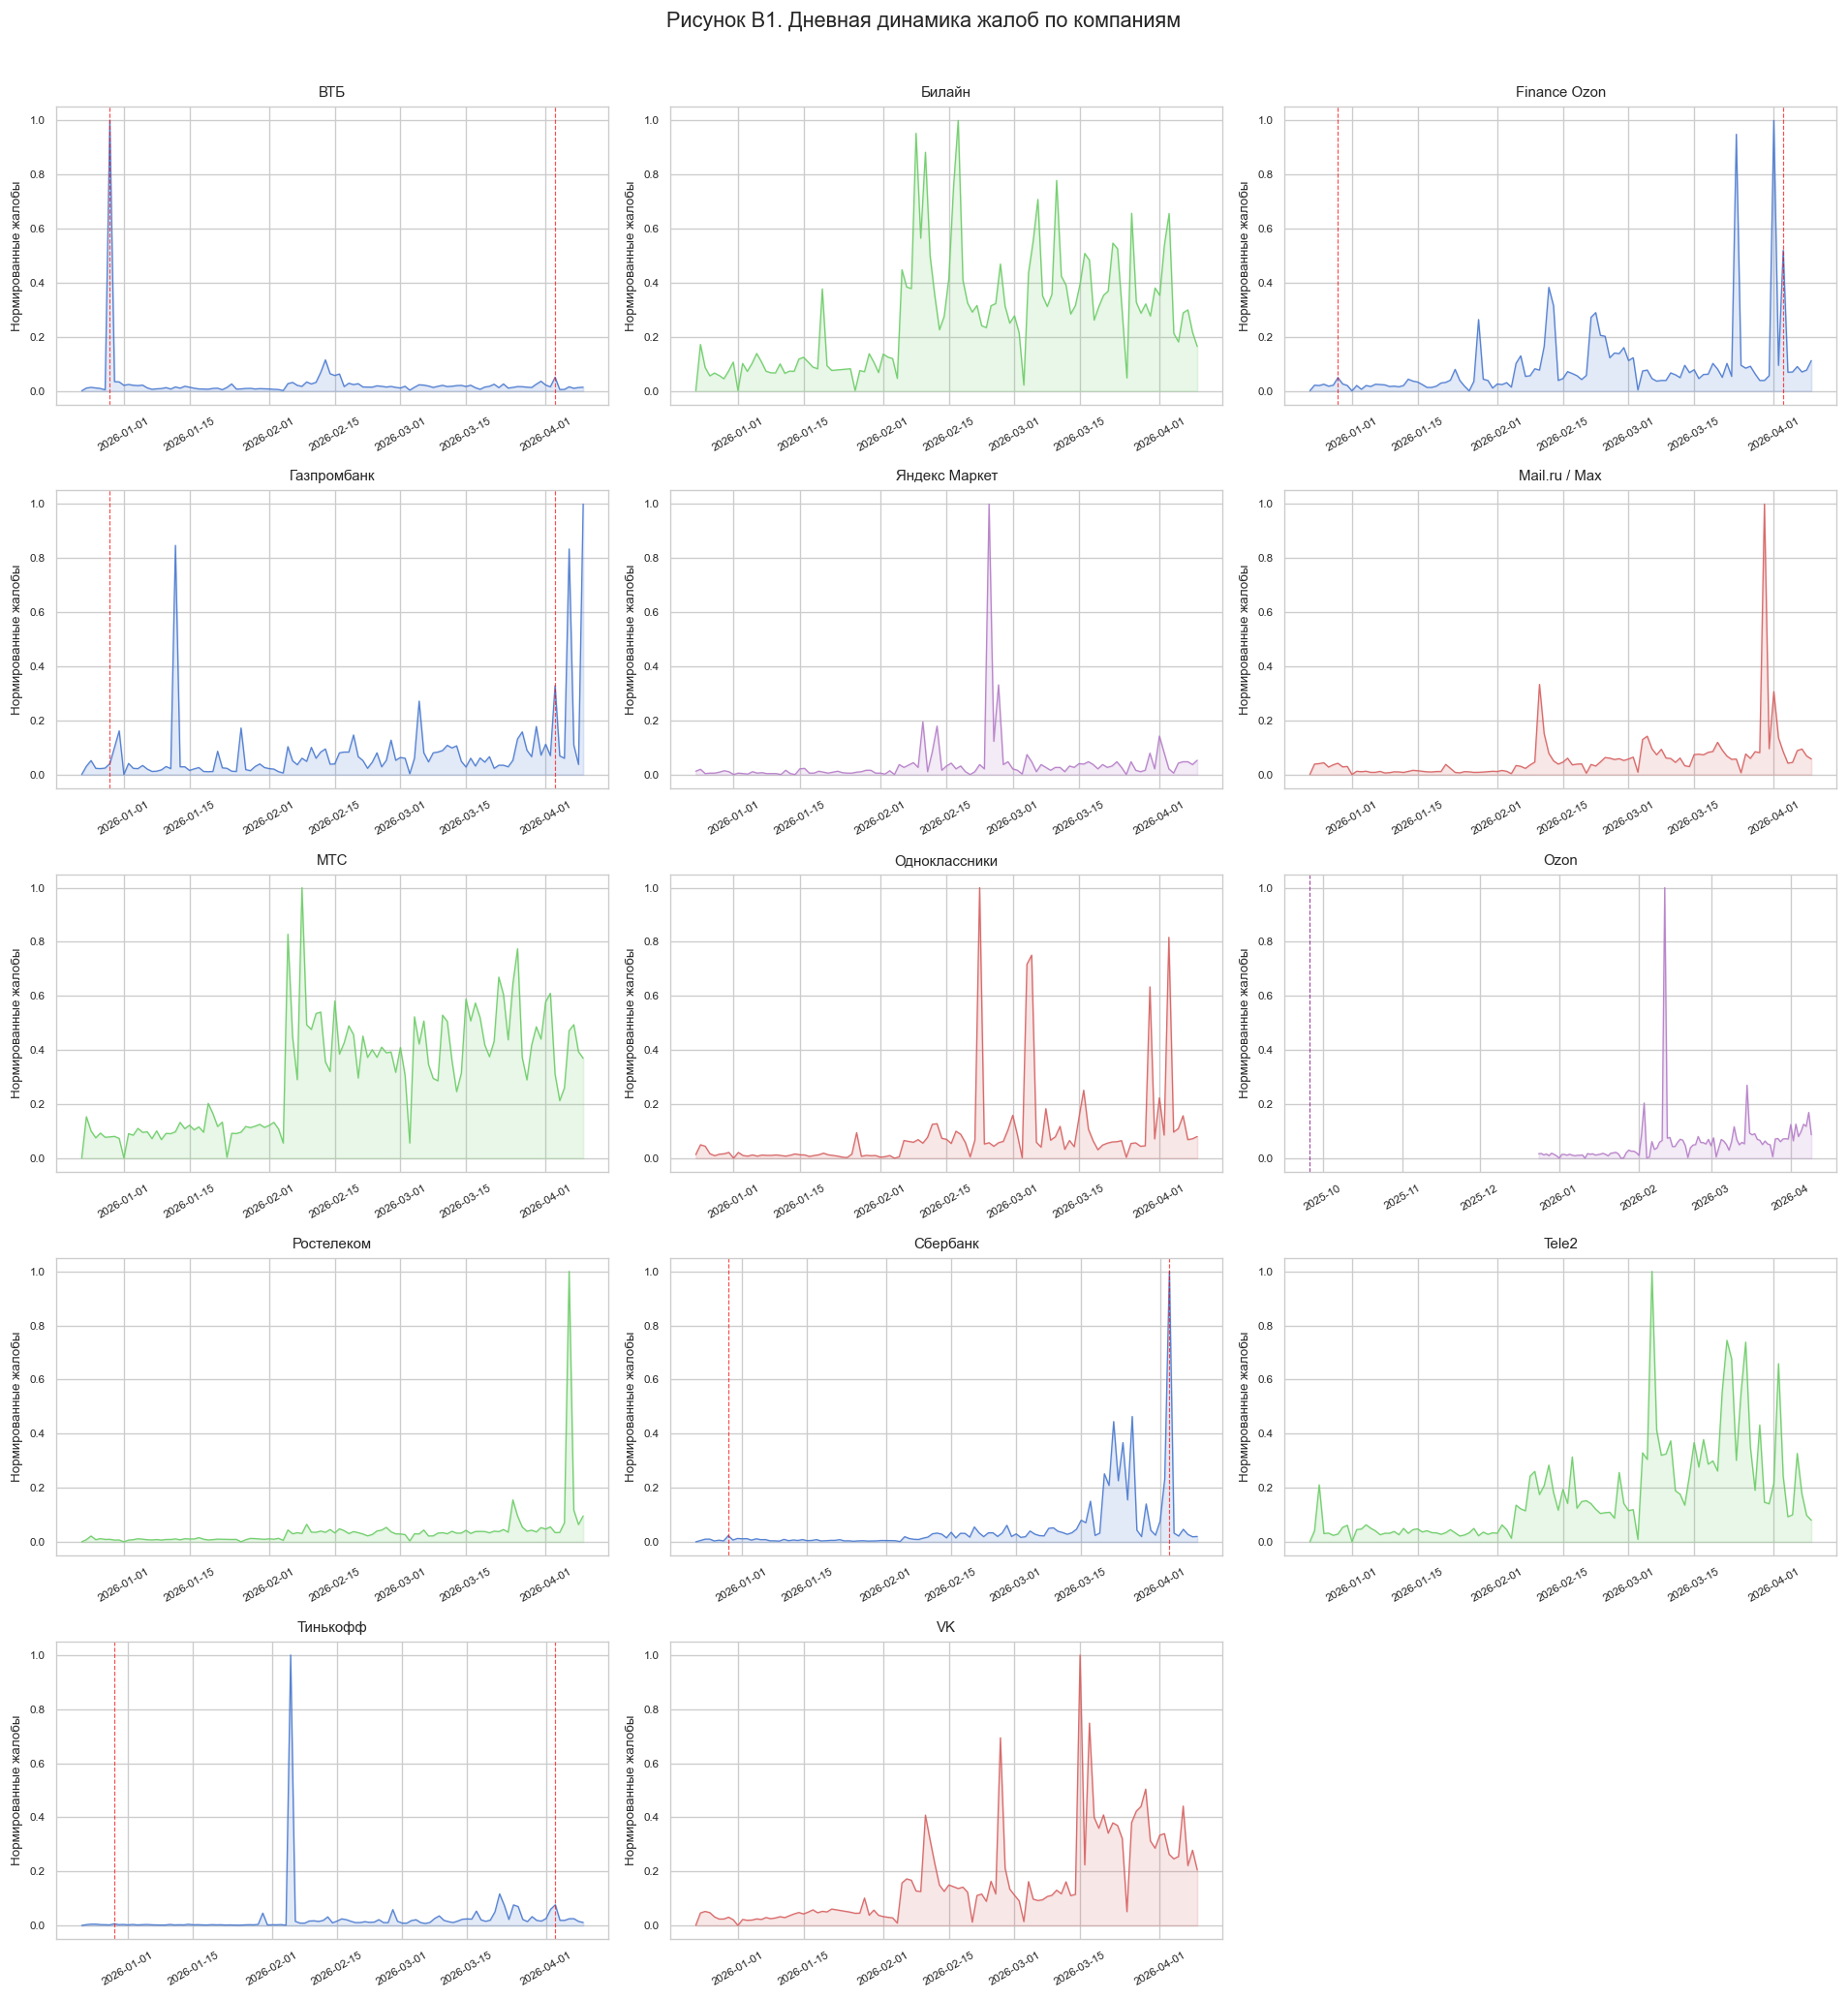

Рисунок B1 сохранён.


In [16]:
companies_list = sorted(daily['company_raw'].unique())
n_cols = 3
n_rows = (len(companies_list) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5), sharex=False)
axes = axes.flatten()

for idx, company in enumerate(companies_list):
    sub = daily[daily['company_raw'] == company].sort_values('date').copy()

    # нормализация
    sub['complaints_norm'] = sub['complaints_per_mln'] / (sub['complaints_per_mln'].max() + 1e-6)
    ax  = axes[idx]
    color = color_sector.get(SECTOR_MAP.get(company, ''), 'steelblue')
    # ax.plot(sub['date'], sub['complaints_sum'], color=color, linewidth=0.8, alpha=0.9)
    # ax.fill_between(sub['date'], sub['complaints_sum'], alpha=0.15, color=color)
    ax.plot(sub['date'], sub['complaints_norm'], color=color, linewidth=0.8, alpha=0.9)
    ax.fill_between(sub['date'], sub['complaints_norm'], alpha=0.15, color=color)
    # Отмечаем системные шоки
    for shock_date in SYSTEMIC_BANKING_OUTAGES:
        if SECTOR_MAP.get(company) == 'Банки':
            ax.axvline(shock_date, color='red', linestyle='--', linewidth=0.7, alpha=0.7)
    if company == 'ozon':
        ax.axvline(OZON_RESTRUCTURING_DATE, color='purple', linestyle='--', linewidth=0.7, alpha=0.7)
    ax.set_title(COMPANY_DISPLAY.get(company, company), fontsize=9)
    ax.set_ylabel('Нормированные жалобы', fontsize=8)
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7)

for i in range(len(companies_list), len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Рисунок B1. Дневная динамика жалоб по компаниям', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUTPUT_DIR / 'Fig_B1_DailyComplaints.png', dpi=150)
plt.show()
print('Рисунок B1 сохранён.')

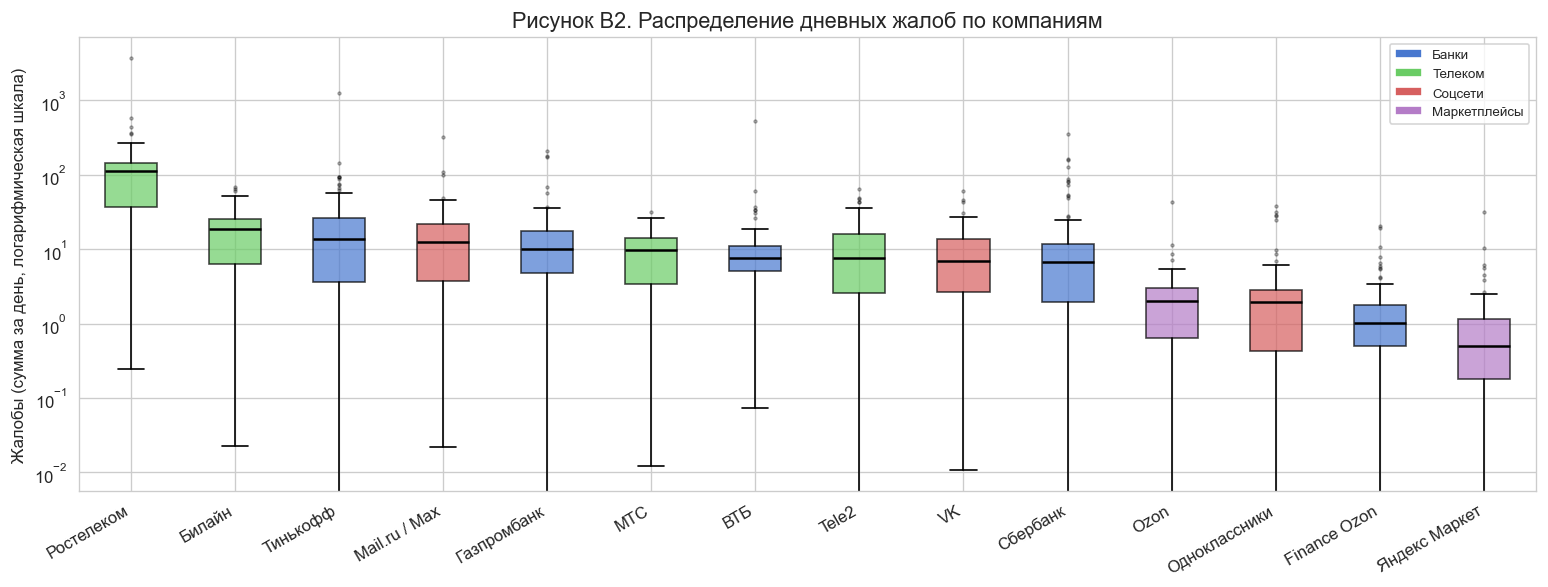

Рисунок B2 сохранён.


In [17]:
fig, ax = plt.subplots(figsize=(13, 5))
order = (daily.groupby('company_raw')['complaints_per_mln'].median()
         .sort_values(ascending=False).index.tolist())
box_data   = [daily[daily['company_raw'] == c]['complaints_per_mln'].dropna() for c in order]
box_labels = [COMPANY_DISPLAY.get(c, c) for c in order]
bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5),
                flierprops=dict(marker='.', markersize=3, alpha=0.4))
for patch, company in zip(bp['boxes'], order):
    patch.set_facecolor(color_sector.get(SECTOR_MAP.get(company, ''), 'grey'))
    patch.set_alpha(0.7)
# ax.set_ylabel('Жалобы (сумма за день)')
ax.set_yscale('log')
ax.set_ylabel('Жалобы (сумма за день, логарифмическая шкала)')
ax.set_title('Рисунок B2. Распределение дневных жалоб по компаниям', fontsize=13)
plt.xticks(rotation=30, ha='right')
legend_elements = [Patch(facecolor=c, label=s) for s, c in color_sector.items()]
ax.legend(handles=legend_elements, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Fig_B2_BoxplotComplaints.png', dpi=150)
plt.show()
print('Рисунок B2 сохранён.')

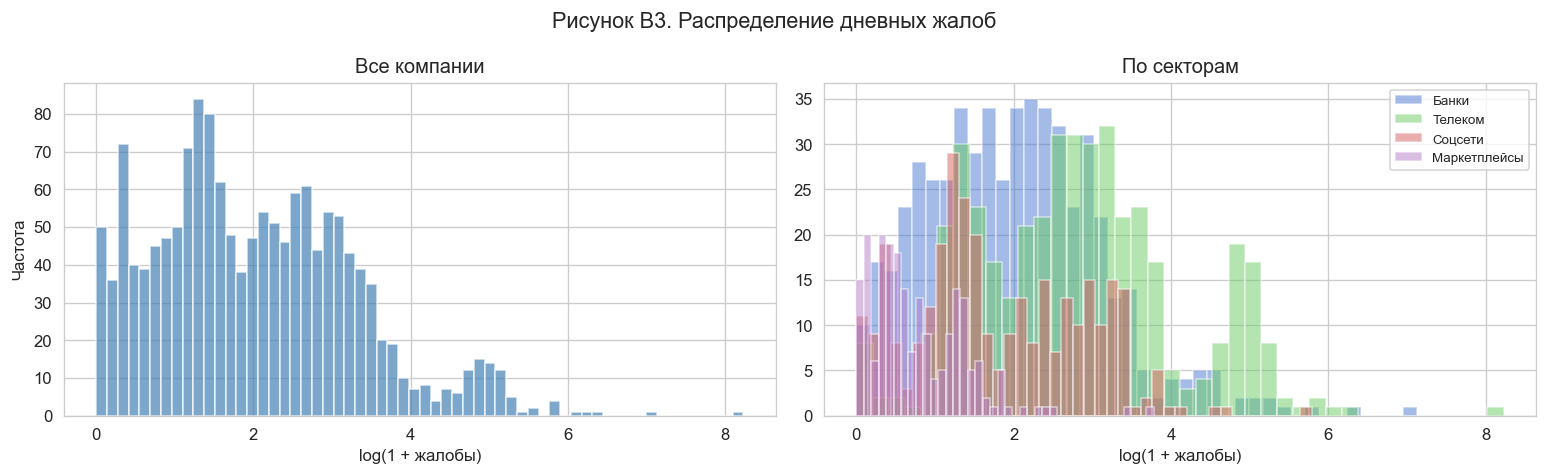

Рисунок B3 сохранён.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# vals = daily['complaints_sum'].replace(0, np.nan).dropna()
vals = daily['complaints_per_mln']
axes[0].hist(np.log1p(vals), bins=60, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_xlabel('log(1 + жалобы)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Все компании')

# По секторам
for sector, color in color_sector.items():
    # sub = daily[daily['sector'] == sector]['complaints_sum'].replace(0, np.nan).dropna()
    sub = daily[daily['sector'] == sector]['complaints_per_mln']
    if len(sub) > 0:
        axes[1].hist(np.log1p(sub), bins=40, alpha=0.5, label=sector, color=color, edgecolor='white')
axes[1].set_xlabel('log(1 + жалобы)')
axes[1].set_title('По секторам')
axes[1].legend(fontsize=8)

fig.suptitle('Рисунок B3. Распределение дневных жалоб', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Fig_B3_DensityComplaints.png', dpi=150)
plt.show()
print('Рисунок B3 сохранён.')

In [19]:
rows_b2 = []
for company in companies_list:
    sub = daily[daily['company_raw'] == company]['complaints_per_mln']
    p95  = sub.quantile(0.95)
    p975 = sub.quantile(0.975)
    rows_b2.append({
        'Сервис'                : COMPANY_DISPLAY.get(company, company),
        'P95 порог'             : round(p95, 1),
        'Доля дней > P95 (%)'   : round((sub > p95).mean() * 100, 1),
        'Доля дней > P97.5 (%)' : round((sub > p975).mean() * 100, 1),
    })
table_b2 = pd.DataFrame(rows_b2)
display(table_b2)
table_b2.to_csv(OUTPUT_DIR / 'Table_B2_AnomalyDays.csv', index=False, encoding='utf-8-sig')
print('Таблица B2 сохранена.')

,Сервис,P95 порог,Доля дней > P95 (%),Доля дней > P97.5 (%)
0,ВТБ,29.0000,5.6000,2.8000
1,Билайн,47.1000,5.7000,2.9000
2,Finance Ozon,5.8000,5.6000,2.8000
3,Газпромбанк,36.8000,5.6000,2.8000
4,Яндекс Маркет,3.5000,5.7000,2.8000
5,Mail.ru / Max,43.6000,5.6000,2.8000
6,МТС,19.1000,5.6000,2.8000
7,Одноклассники,9.4000,5.7000,2.8000
8,Ozon,5.3000,5.7000,2.8000
9,Ростелеком,257.6000,5.6000,2.8000


Таблица B2 сохранена.


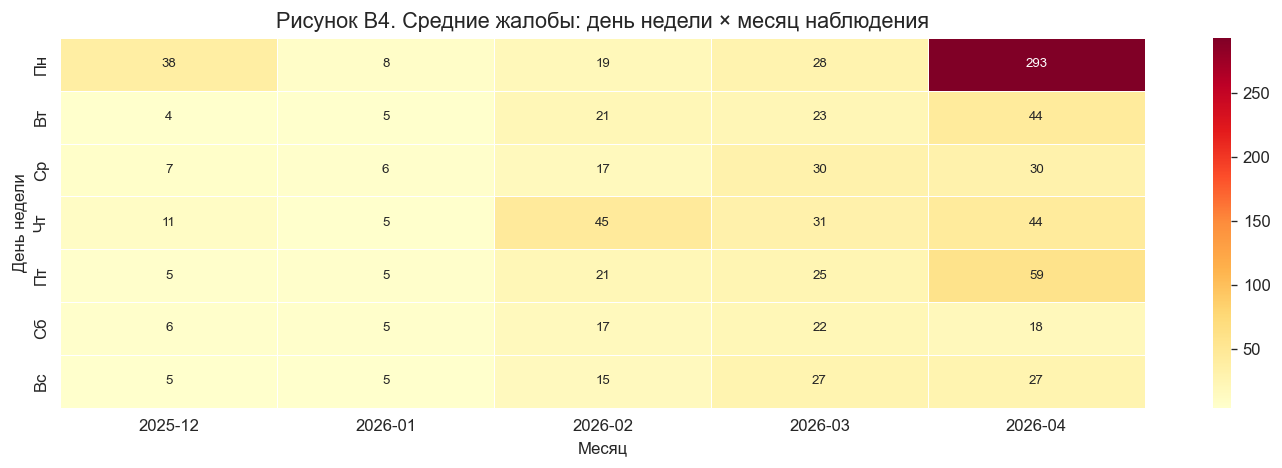

Рисунок B4 сохранён.


In [20]:
day_labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

daily['year_month'] = daily['date'].dt.to_period('M').astype(str)

pivot = (daily.groupby(['day_of_week', 'year_month'])['complaints_per_mln']
         .mean()
         .unstack(fill_value=0))

pivot.index = [day_labels[i] for i in pivot.index]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    annot=True,
    fmt='.0f',
    annot_kws={'size': 8}
)

ax.set_title('Рисунок B4. Средние жалобы: день недели × месяц наблюдения', fontsize=13)
ax.set_xlabel('Месяц')
ax.set_ylabel('День недели')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Fig_B4_SeasonalHeatmap.png', dpi=150)
plt.show()
print('Рисунок B4 сохранён.')


## ЭТАП C. Анализ текстов и вспомогательных метаданных


In [21]:
TOPIC_KEYWORDS = {
    'payment': [
        'оплат', 'платёж', 'платеж', 'перевод', 'транзакц', 'карт', 'деньг',
        'списани', 'зачислени', 'банк', 'счёт', 'счет'
    ],
    'login': [
        'войти', 'вход', 'авториз', 'пароль', 'логин', 'аккаунт',
        'профил', 'личный кабинет', 'подтвержд'
    ],
    'technical': [
        'не работает', 'ошибка', 'сбой', 'упал', 'недоступ', 'завис',
        'вылет', 'глюк', 'баг', 'проблем', 'технич'
    ],
    'delivery': [
        'доставк', 'курьер', 'заказ', 'отслежив', 'посылк', 'пункт выдачи'
    ],
    'connection': [
        'интернет', 'связь', 'сеть', '4g', '5g', 'wi-fi', 'wifi',
        'мобильн', 'сигнал', 'роуминг'
    ],
}

table_c1 = pd.DataFrame([
    {'Тема': topic, 'Ключевые слова': ', '.join(keywords)}
    for topic, keywords in TOPIC_KEYWORDS.items()
])
display(table_c1)
table_c1.to_csv(OUTPUT_DIR / 'Table_C1_TopicDictionaries.csv', index=False, encoding='utf-8-sig')
print('Таблица C1 сохранена.')


def count_topic_mentions(text, keywords):
    """Считает общее число вхождений ключевых слов в тексте."""
    text = str(text).lower()
    return sum(text.count(kw) for kw in keywords)


# Считаем тематические упоминания по каждому комментарию
for topic, kws in TOPIC_KEYWORDS.items():
    user_messages[f'topic_{topic}'] = user_messages['comment'].apply(
        lambda t: count_topic_mentions(t, kws)
    )

topic_cols = [f'topic_{topic}' for topic in TOPIC_KEYWORDS.keys()]

# Агрегируем к дневному уровню
text_daily = (
    user_messages
    .groupby(['company_raw', 'date'])
    .agg(
        comments_count_text=('comment', 'count'),
        **{col: (col, 'sum') for col in topic_cols}
    )
    .reset_index()
)

# Общее число тематических упоминаний
text_daily['total_mentions'] = text_daily[topic_cols].sum(axis=1)

# Доли тем среди всех тематических упоминаний
for col in topic_cols:
    text_daily[col.replace('topic_', 'share_') + '_words'] = (
        text_daily[col] / (text_daily['total_mentions'] + 1e-6)
    )

# Дополнительно: интенсивность темы на один комментарий
for col in topic_cols:
    text_daily[col.replace('topic_', 'share_') + '_comments'] = (
        text_daily[col] / (text_daily['comments_count_text'] + 1e-6)
    )

# Присоединяем к дневной панели
share_cols = [c for c in text_daily.columns if c.startswith('share_')]

daily = daily.merge(
    text_daily[['company_raw', 'date', 'comments_count_text'] + share_cols],
    on=['company_raw', 'date'],
    how='left'
)

daily['comments_count_text'] = daily['comments_count_text'].fillna(0).astype(int)
for col in share_cols:
    daily[col] = daily[col].fillna(0)

print('Текстовые признаки добавлены.')
print('Добавленные столбцы:')
print(['comments_count_text'] + share_cols)

,Тема,Ключевые слова
0,payment,"оплат, платёж, платеж, перевод, транзакц, карт..."
1,login,"войти, вход, авториз, пароль, логин, аккаунт, ..."
2,technical,"не работает, ошибка, сбой, упал, недоступ, зав..."
3,delivery,"доставк, курьер, заказ, отслежив, посылк, пунк..."
4,connection,"интернет, связь, сеть, 4g, 5g, wi-fi, wifi, мо..."


Таблица C1 сохранена.
Текстовые признаки добавлены.
Добавленные столбцы:
['comments_count_text', 'share_payment_words', 'share_login_words', 'share_technical_words', 'share_delivery_words', 'share_connection_words', 'share_payment_comments', 'share_login_comments', 'share_technical_comments', 'share_delivery_comments', 'share_connection_comments']


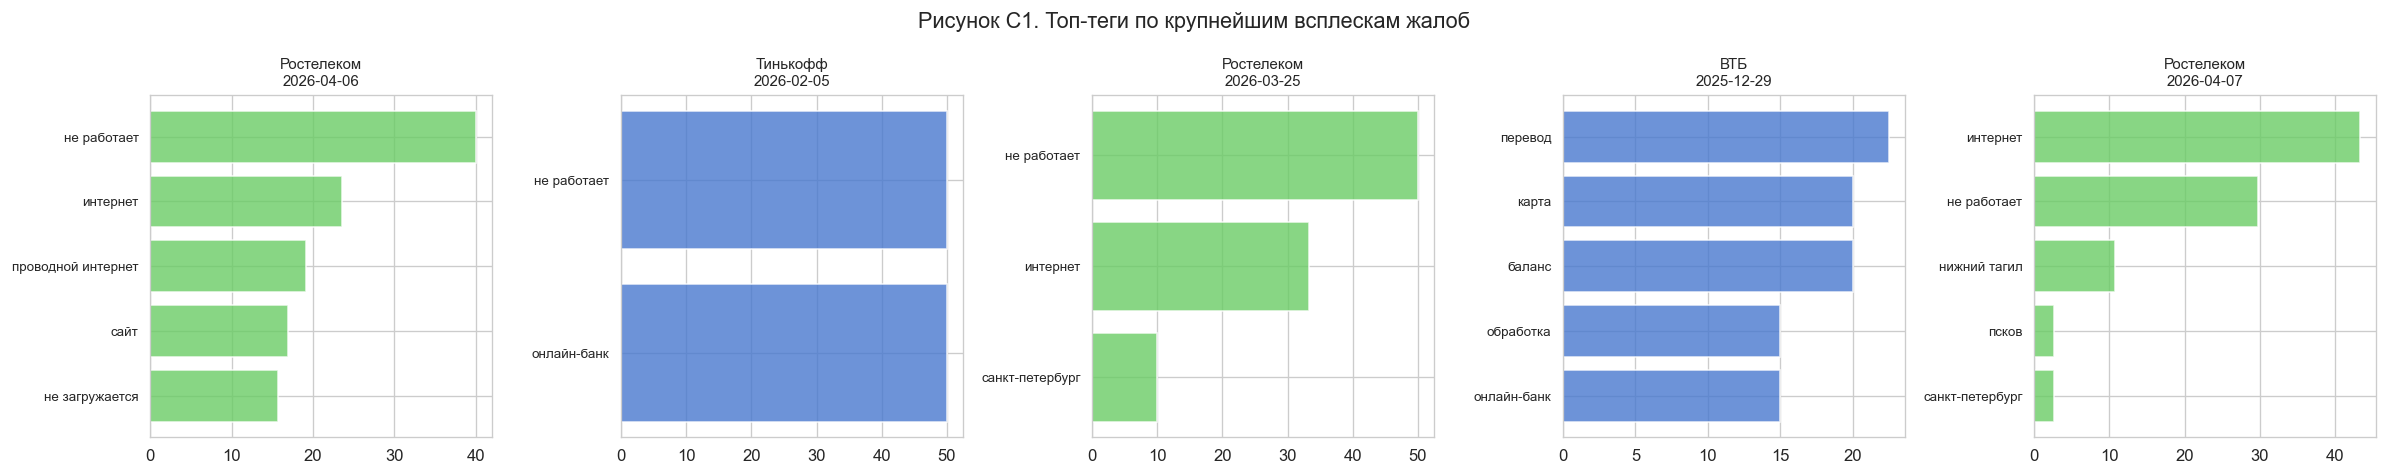

Рисунок C1 сохранён.


In [22]:
top_events = (
    daily.nlargest(5, 'complaints_per_mln')[['company_raw', 'date', 'complaints_per_mln']]
         .reset_index(drop=True)
)

n_events = len(top_events)
fig, axes = plt.subplots(1, n_events, figsize=(4 * n_events, 4))

if n_events == 1:
    axes = [axes]

for i, row in top_events.iterrows():
    tags = cloud_tags[
        (cloud_tags['company_raw'] == row['company_raw']) &
        (cloud_tags['date'] == row['date'])
    ].nlargest(5, 'frequency')

    ax = axes[i]

    if len(tags) > 0:
        tags = tags.sort_values('frequency', ascending=True)

        ax.barh(
            tags['word'].astype(str),
            tags['frequency'],
            color=color_sector.get(SECTOR_MAP.get(row['company_raw'], ''), 'steelblue'),
            alpha=0.8
        )
        ax.set_title(
            f"{COMPANY_DISPLAY.get(row['company_raw'], row['company_raw'])}\n{row['date'].date()}",
            fontsize=9
        )
        ax.tick_params(axis='y', labelsize=8)
    else:
        ax.text(0.5, 0.5, 'Нет тегов', ha='center', va='center', fontsize=10)
        ax.set_title(
            f"{COMPANY_DISPLAY.get(row['company_raw'], row['company_raw'])}\n{row['date'].date()}",
            fontsize=9
        )
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle('Рисунок C1. Топ-теги по крупнейшим всплескам жалоб', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Fig_C1_TopTagsEvents.png', dpi=150)
plt.show()
print('Рисунок C1 сохранён.')

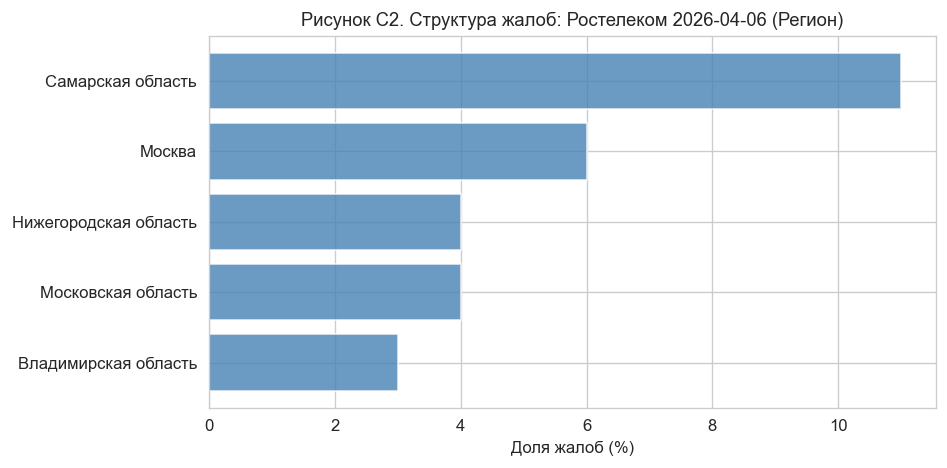

Этап C завершён.


In [23]:
top_event = top_events.iloc[0]  # крупнейшее событие

hist_sub = histograms[
    (histograms['company_raw'] == top_event['company_raw']) &
    (histograms['date'] == top_event['date'])
].copy()

if len(hist_sub) > 0:
    types_available = hist_sub['category_type'].dropna().astype(str).unique().tolist()

    if 'Регион' in types_available:
        chosen_type = 'Регион'
    else:
        chosen_type = types_available[0]

    hist_plot = (
        hist_sub[hist_sub['category_type'] == chosen_type]
        .nlargest(10, 'pct')
        .sort_values('pct', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(
        hist_plot['category_name'].astype(str),
        hist_plot['pct'],
        color='steelblue',
        alpha=0.8
    )
    ax.set_xlabel('Доля жалоб (%)')
    ax.set_title(
        f"Рисунок C2. Структура жалоб: "
        f"{COMPANY_DISPLAY.get(top_event['company_raw'], '')} "
        f"{top_event['date'].date()} ({chosen_type})",
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'Fig_C2_RegionalComplaints.png', dpi=150)
    plt.show()
else:
    print('Нет данных histograms для крупнейшего события — рисунок C2 пропущен.')

print('Этап C завершён.')

In [24]:
table_c2_rows = []
for _, ev in top_events.iterrows():
    msg_sub = user_messages[
        (user_messages['company_raw'] == ev['company_raw']) &
        (user_messages['date'] == ev['date'])
    ]
    table_c2_rows.append({
        'Сервис'           : COMPANY_DISPLAY.get(ev['company_raw'], ev['company_raw']),
        'Дата'             : ev['date'].date(),
        'Жалобы (сумма)'   : int(ev['complaints_per_mln']),
        'Комментариев'     : len(msg_sub),
        'Уникальных юзеров': msg_sub['user_nick'].nunique() if len(msg_sub) > 0 else 0,
    })
table_c2 = pd.DataFrame(table_c2_rows)
display(table_c2)
table_c2.to_csv(OUTPUT_DIR / 'Table_C2_TopEventsComments.csv', index=False, encoding='utf-8-sig')
print('Таблица C2 сохранена.')

,Сервис,Дата,Жалобы (сумма),Комментариев,Уникальных юзеров
0,Ростелеком,2026-04-06,3750,1275,99
1,Тинькофф,2026-02-05,1240,784,104
2,Ростелеком,2026-03-25,580,223,24
3,ВТБ,2025-12-29,530,1515,156
4,Ростелеком,2026-04-07,439,279,27


Таблица C2 сохранена.



## ЭТАП D. Подготовка рыночных данных



In [25]:
def build_market_features_hourly(df):
    d = df.sort_values(['issuer_name', 'datetime_hour']).copy()
    d['close_price'] = pd.to_numeric(d['close_price'], errors='coerce')
    d['return'] = d.groupby('issuer_name')['close_price'].transform(
        lambda x: np.log(x / x.shift(1)))
    d['abs_return'] = d['return'].abs()
    d['lagged_return'] = d.groupby('issuer_name')['return'].shift(1)
    d['rolling_vol_24h'] = d.groupby('issuer_name')['return'].transform(
        lambda x: x.shift(1).rolling(24, min_periods=6).std())
    d['rolling_vol_48h'] = d.groupby('issuer_name')['return'].transform(
        lambda x: x.shift(1).rolling(48, min_periods=12).std())

    return d


stock = build_market_features_hourly(stock_prices)

market_stats = (
    stock.groupby('datetime_hour')['return']
    .agg(['sum', 'count'])
    .reset_index()
    .rename(columns={'sum': 'mkt_sum', 'count': 'mkt_count'})
)

stock = stock.merge(market_stats, on='datetime_hour', how='left')
stock['market_return'] = np.where(
    stock['mkt_count'] > 1,
    (stock['mkt_sum'] - stock['return']) / (stock['mkt_count'] - 1),
    np.nan
)
stock.drop(columns=['mkt_sum', 'mkt_count'], inplace=True)

# Торговый флаг
stock['is_trading_day_stock'] = stock['date'].apply(lambda x: int(is_trading_day(x)))
stock['is_trading_hour_stock']= stock['hour'].apply(
    lambda h: int(h in MOEX_TRADING_HOURS) if pd.notna(h) else 0)

print(f'Рыночные данные: {len(stock):,} строк (почасовые)')
print(f'Эмитентов: {stock["issuer_name"].nunique()}')
print(f'Период: {stock["date"].min().date()} → {stock["date"].max().date()}')
print(f'Пример доходностей (sberbank):')
print(stock[stock['issuer_name']=='sberbank'][
    ['datetime_hour','close_price','return','market_return']].head(5).to_string())


Рыночные данные: 13,208 строк (почасовые)
Эмитентов: 9
Период: 2025-12-22 → 2026-04-09
Пример доходностей (sberbank):
           datetime_hour  close_price  return  market_return
8806 2025-12-22 07:00:00     300.2000     NaN            NaN
8807 2025-12-22 08:00:00     299.8900 -0.0010        -0.0002
8808 2025-12-22 09:00:00     299.4300 -0.0015        -0.0039
8809 2025-12-22 10:00:00     297.6500 -0.0060        -0.0056
8810 2025-12-22 11:00:00     298.0300  0.0013         0.0057


In [26]:
desc_market = []
for issuer in sorted(stock['issuer_name'].dropna().unique()):
    s = stock[stock['issuer_name'] == issuer]['return'].dropna()
    if len(s) == 0:
        continue
    desc_market.append({
        'Эмитент'       : issuer,
        'N торг. дней'  : len(s),
        'Среднее (%)'   : round(s.mean() * 100, 3),
        'Медиана (%)'   : round(s.median() * 100, 3),
        'Std (%)'       : round(s.std() * 100, 3),
        'Min (%)'       : round(s.min() * 100, 2),
        'Max (%)'       : round(s.max() * 100, 2),
        'Skewness'      : round(stats.skew(s), 3),
        'Kurtosis'      : round(stats.kurtosis(s), 3),
    })
table_d1 = pd.DataFrame(desc_market)
display(table_d1)
table_d1.to_csv(OUTPUT_DIR / 'Table_D1_ReturnStats.csv', index=False, encoding='utf-8-sig')
print('Таблица D1 сохранена.')

,Эмитент,N торг. дней,Среднее (%),Медиана (%),Std (%),Min (%),Max (%),Skewness,Kurtosis
0,bank-vtb,1467,0.0140,0.0000,0.3410,-2.3600,1.8900,0.3130,7.3380
1,gazprombank,1467,0.0010,0.0000,0.3520,-2.7500,4.8700,1.5950,32.0300
2,marketyandex,1467,-0.0040,0.0000,0.3050,-2.4000,1.7500,-0.1350,5.8950
3,mts,1467,0.0020,0.0000,0.2400,-1.1500,1.9900,0.3150,5.6250
4,ozon,1465,0.0040,0.0000,0.3600,-2.2100,2.0500,0.0500,4.6230
5,rostelekom,1467,-0.0070,0.0000,0.3290,-3.0600,1.7800,-0.8240,9.0540
6,sberbank,1467,0.0040,0.0000,0.1700,-0.9700,1.1300,0.6570,7.5670
7,tinkoff,1465,-0.0000,-0.0060,0.2100,-1.2700,1.9300,0.4740,9.4960
8,vkontakte,1467,-0.0040,-0.0170,0.3660,-2.0700,2.9800,0.6110,7.5160


Таблица D1 сохранена.


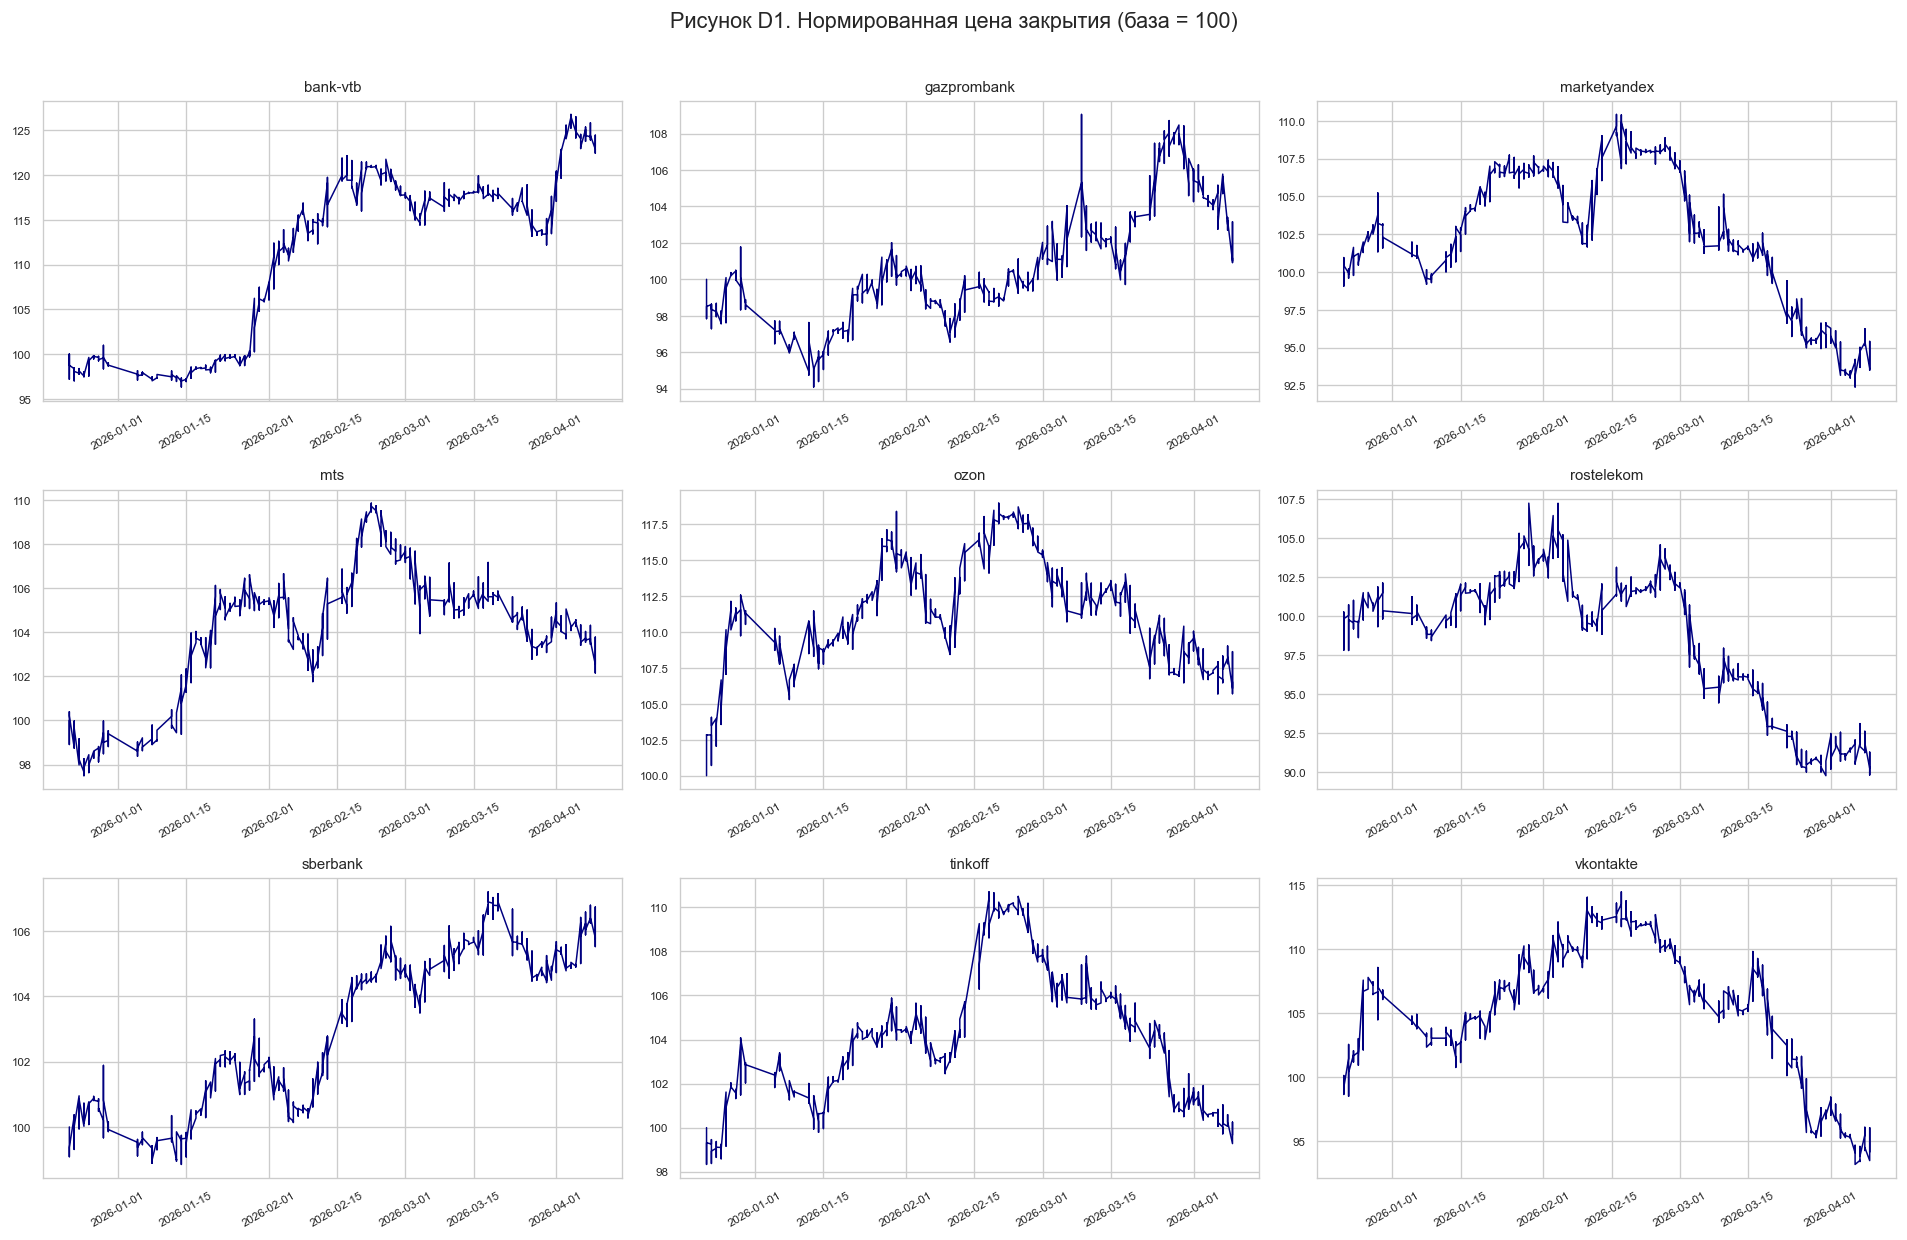

Рисунок D1 сохранён.


In [27]:
valid_issuers = (
    stock.groupby('issuer_name')['close_price']
    .apply(lambda x: x.notna().sum() > 1)
)

issuers = valid_issuers[valid_issuers].index.tolist()
issuers = sorted(issuers)
n_cols_d  = 3
n_rows_d  = (len(issuers) + n_cols_d - 1) // n_cols_d
fig, axes = plt.subplots(n_rows_d, n_cols_d, figsize=(16, n_rows_d * 3.5))
axes = axes.flatten()

for idx, issuer in enumerate(issuers):
    sub = stock[stock['issuer_name'] == issuer].sort_values('date')
    prices = sub.set_index('date')['close_price'].dropna()
    if len(prices) == 0:
        continue
    norm_prices = prices / prices.iloc[0] * 100
    ax = axes[idx]
    ax.plot(norm_prices.index, norm_prices.values, linewidth=0.9, color='navy')
    ax.set_title(issuer, fontsize=9)
    # ax.set_ylim(90, 140)
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7)

for i in range(len(issuers), len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Рисунок D1. Нормированная цена закрытия (база = 100)', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUTPUT_DIR / 'Fig_D1_NormalizedPrices.png', dpi=150)
plt.show()
print('Рисунок D1 сохранён.')

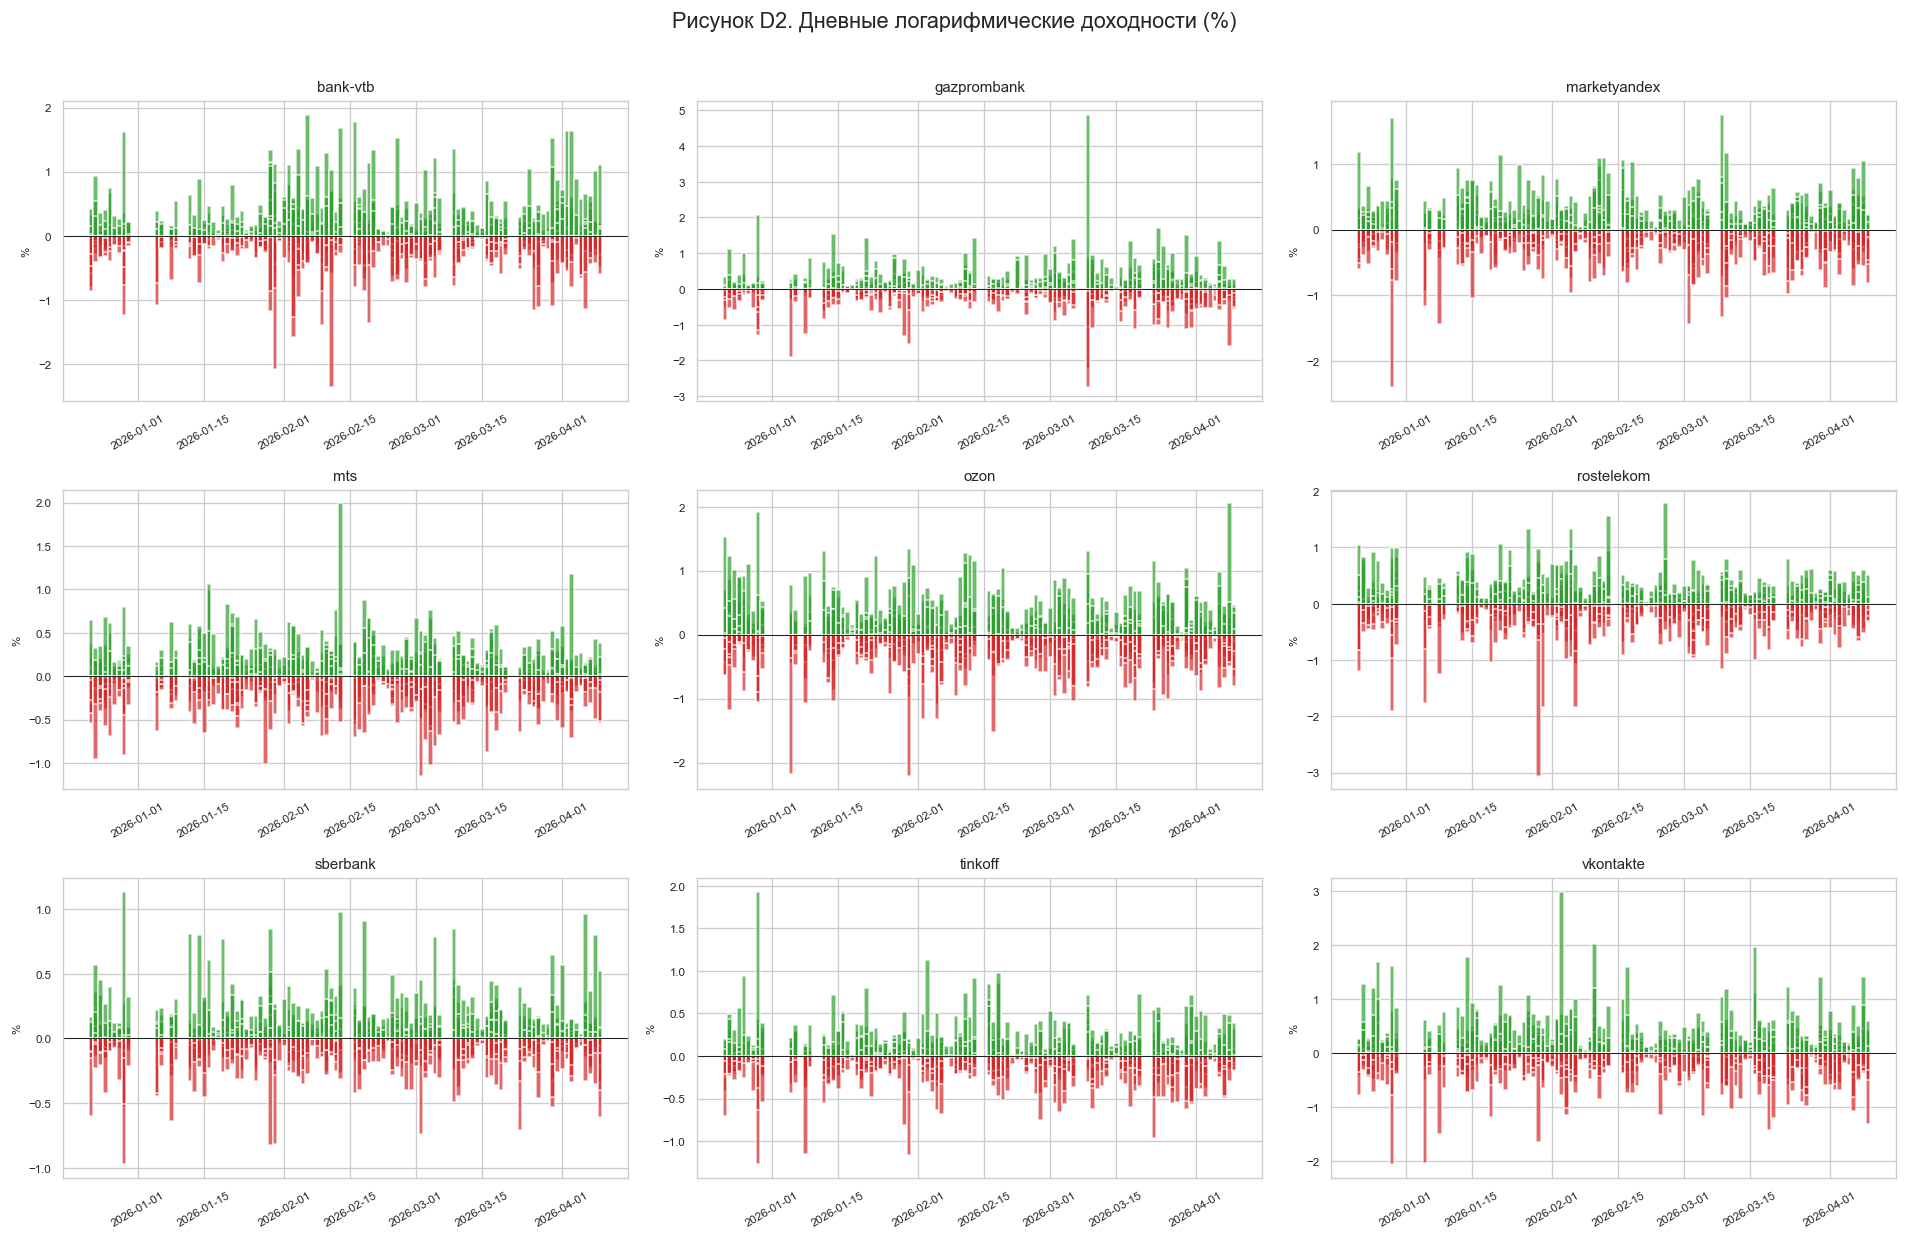

Рисунок D2 сохранён.


In [28]:
fig, axes = plt.subplots(n_rows_d, n_cols_d, figsize=(16, n_rows_d * 3.5))
axes = axes.flatten()

for idx, issuer in enumerate(issuers):
    sub = stock[stock['issuer_name'] == issuer].sort_values('date')
    ret = sub.set_index('date')['return'].dropna()
    ax  = axes[idx]
    ax.bar(ret.index, ret.values * 100,
           color=np.where(ret.values >= 0, '#2ca02c', '#d62728'),
           width=1.0, alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(issuer, fontsize=9)
    ax.set_ylabel('%', fontsize=7)
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7)

for i in range(len(issuers), len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Рисунок D2. Дневные логарифмические доходности (%)', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUTPUT_DIR / 'Fig_D2_DailyReturns.png', dpi=150)
plt.show()
print('Рисунок D2 сохранён.')

Почасовая панель: 34,440 строк × 62 столбцов
  Из них с доходностями: 17,932
  Торговые часы с доходностями: 17,932

Дневная панель (для event study): 1,499 строк × 63 столбцов
  Дней с доходностями: 1,212


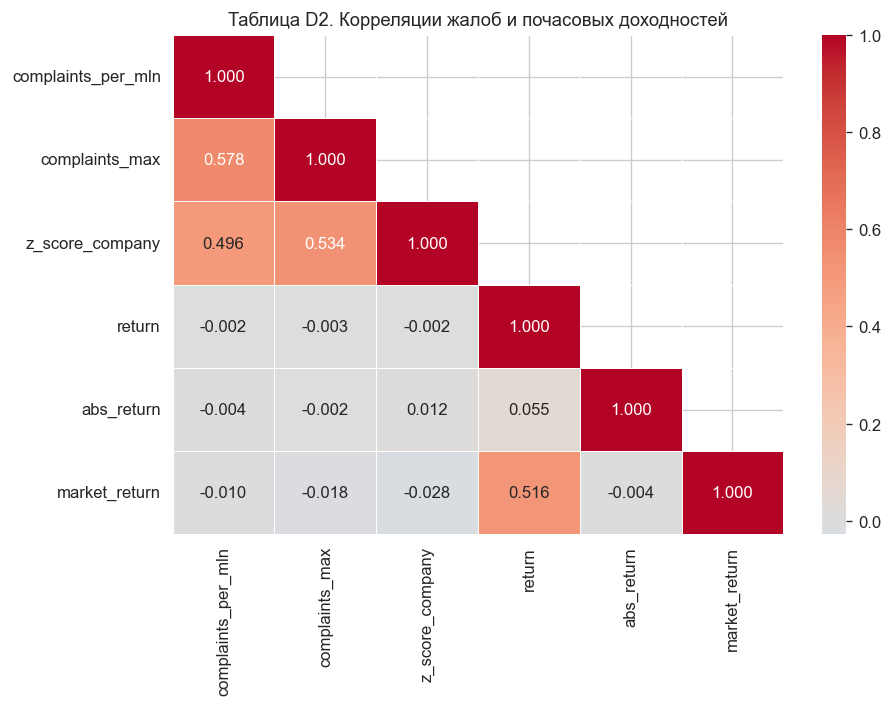

Корреляционная матрица сохранена.


In [29]:
stock_slim = stock[[
    'issuer_name', 'datetime_hour', 'date', 'hour',
    'close_price', 'return', 'abs_return',
    'lagged_return', 'rolling_vol_24h', 'rolling_vol_48h',
    'market_return', 'is_trading_day_stock', 'is_trading_hour_stock'
] + (['volume'] if 'volume' in stock.columns else [])].copy()

panel_hourly = hourly.merge(
    stock_slim,
    on=['issuer_name', 'datetime_hour'],
    how='left',
    suffixes=('', '_stock'))

for col in ['date_stock', 'hour_stock']:
    if col in panel_hourly.columns:
        panel_hourly.drop(columns=[col], inplace=True)

print(f'Почасовая панель: {len(panel_hourly):,} строк × {panel_hourly.shape[1]} столбцов')
print(f'  Из них с доходностями: {panel_hourly["return"].notna().sum():,}')
print(f'  Торговые часы с доходностями: '
      f'{panel_hourly[panel_hourly["is_trading_hour_stock"]==1]["return"].notna().sum():,}')

stock_daily = (stock.sort_values(['issuer_name', 'datetime_hour'])
               .groupby(['issuer_name', 'date'])
               .agg(
                   close_price_daily    = ('close_price', 'last'),
                   return_daily         = ('return',      'sum'),   
                   abs_return_daily     = ('abs_return',  'sum'),
                   market_return_daily  = ('market_return','mean'),
                   volume_daily         = ('volume',       'sum') if 'volume' in stock.columns else ('close_price','count'),
               ).reset_index())
stock_daily.rename(columns={
    'return_daily'       : 'return',
    'abs_return_daily'   : 'abs_return',
    'market_return_daily': 'market_return',
    'close_price_daily'  : 'close_price',
}, inplace=True)
stock_daily['lagged_return'] = stock_daily.groupby('issuer_name')['return'].shift(1)
stock_daily['rolling_vol_5d']= stock_daily.groupby('issuer_name')['return'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=3).std())

panel = daily.merge(
    stock_daily[['issuer_name','date','close_price','return','abs_return',
                 'market_return','lagged_return','rolling_vol_5d']],
    on=['issuer_name', 'date'], how='left')

print(f'\nДневная панель (для event study): {len(panel):,} строк × {panel.shape[1]} столбцов')
print(f'  Дней с доходностями: {panel["return"].notna().sum():,}')

panel_trade_h = panel_hourly[
    (panel_hourly['return'].notna()) &
    (panel_hourly['is_trading_hour_stock'] == 1)].copy()

corr_cols = ['complaints_per_mln', 'complaints_max', 'z_score_company',
             'return', 'abs_return', 'market_return']
corr_cols = [c for c in corr_cols if c in panel_trade_h.columns]
corr_matrix = panel_trade_h[corr_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.3, ax=ax, mask=mask)
ax.set_title('Таблица D2. Корреляции жалоб и почасовых доходностей', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Fig_D2_CorrelationHeatmap_Hourly.png', dpi=150)
plt.show()
corr_matrix.to_csv(OUTPUT_DIR / 'Table_D2_CorrelationMatrix_Hourly.csv', encoding='utf-8-sig')
print('Корреляционная матрица сохранена.')


---
## ЭТАП E. Детектирование outage-like событий



In [30]:
def detect_events(df, percentile=EVENT_PERCENTILE_MAIN,
                  z_threshold=EVENT_Z_THRESHOLD,
                  method='percentile',
                  gap_days=3):

    d = df.sort_values(['company_raw', 'date']).copy()
    d['event_flag_raw'] = 0

    # 1. Ставим первичный флаг аномального дня
    for company in d['company_raw'].dropna().unique():
        idx = d['company_raw'] == company
        vals = d.loc[idx, 'complaints_per_mln']

        if method == 'percentile':
            threshold = vals.quantile(percentile / 100)
            d.loc[idx, 'event_flag_raw'] = (vals > threshold).astype(int)

        elif method == 'zscore':
            zs = (vals - vals.mean()) / (vals.std() + 1e-6)
            d.loc[idx, 'event_flag_raw'] = (zs > z_threshold).astype(int)

        elif method == 'combined':
            threshold = vals.quantile(percentile / 100)
            zs = (vals - vals.mean()) / (vals.std() + 1e-6)
            d.loc[idx, 'event_flag_raw'] = (
                (vals > threshold) | (zs > z_threshold)
            ).astype(int)

    # 2. Схлопываем соседние аномальные дни в одно событие
    d['event_flag'] = 0

    for company in d['company_raw'].dropna().unique():
        sub_idx = d['company_raw'] == company
        sub = d.loc[sub_idx].sort_values('date').copy()

        event_dates = sub.loc[sub['event_flag_raw'] == 1, 'date'].tolist()

        kept_dates = []
        last_kept = None

        for dt in event_dates:
            if last_kept is None or (dt - last_kept).days > gap_days:
                kept_dates.append(dt)
                last_kept = dt

        d.loc[sub.index[sub['date'].isin(kept_dates)], 'event_flag'] = 1

    return d


# Основной критерий (P95)
panel = detect_events(panel, percentile=EVENT_PERCENTILE_MAIN, method='percentile', gap_days=3)

# Альтернативные для robustness
panel_alt1   = detect_events(panel.copy(), percentile=97.5, method='percentile', gap_days=3)
panel_zscore = detect_events(panel.copy(), z_threshold=2.5, method='zscore', gap_days=3)
panel_comb   = detect_events(panel.copy(), percentile=95, method='combined', gap_days=3)

panel['event_flag_p975']     = panel_alt1['event_flag']
panel['event_flag_zscore']   = panel_zscore['event_flag']
panel['event_flag_combined'] = panel_comb['event_flag']

print(f'Событий (P95)      : {panel["event_flag"].sum()}')
print(f'Событий (P97.5)    : {panel["event_flag_p975"].sum()}')
print(f'Событий (z>2.5)    : {panel["event_flag_zscore"].sum()}')
print(f'Событий (combined) : {panel["event_flag_combined"].sum()}')


Событий (P95)      : 54
Событий (P97.5)    : 33
Событий (z>2.5)    : 27
Событий (combined) : 54


In [31]:
event_rows = []
for company in companies_list:
    sub = panel[panel['company_raw'] == company]
    event_rows.append({
        'Сервис'           : COMPANY_DISPLAY.get(company, company),
        'Сектор'           : SECTOR_MAP.get(company, ''),
        'Всего дней'       : len(sub),
        'P95 событий'      : int(sub['event_flag'].sum()),
        'P97.5 событий'    : int(sub['event_flag_p975'].sum()),
        'z>2.5 событий'    : int(sub['event_flag_zscore'].sum()),
        'Combined событий' : int(sub['event_flag_combined'].sum()),
    })
table_e1 = pd.DataFrame(event_rows)
display(table_e1)
table_e1.to_csv(OUTPUT_DIR / 'Table_E1_EventsByCompany.csv', index=False, encoding='utf-8-sig')
print('Таблица E1 сохранена.')

,Сервис,Сектор,Всего дней,P95 событий,P97.5 событий,z>2.5 событий,Combined событий
0,ВТБ,Банки,108,3,2,1,3
1,Билайн,Телеком,105,4,2,2,4
2,Finance Ozon,Банки,108,4,2,2,4
3,Газпромбанк,Банки,108,5,2,2,5
4,Яндекс Маркет,Маркетплейсы,106,3,2,1,3
5,Mail.ru / Max,Соцсети,107,3,2,2,3
6,МТС,Телеком,108,4,2,1,4
7,Одноклассники,Соцсети,106,5,3,4,5
8,Ozon,Маркетплейсы,106,5,3,1,5
9,Ростелеком,Телеком,107,3,2,1,3


Таблица E1 сохранена.


In [32]:
table_e2 = panel.groupby('sector').agg(
    Дней=('event_flag', 'count'),
    Событий_P95=('event_flag', 'sum'),
    Событий_P975=('event_flag_p975', 'sum'),
    Событий_z=('event_flag_zscore', 'sum'),
).reset_index().rename(columns={'sector': 'Сектор'})
display(table_e2)
table_e2.to_csv(OUTPUT_DIR / 'Table_E2_EventsBySector.csv', index=False, encoding='utf-8-sig')
print('Таблица E2 сохранена.')

,Сектор,Дней,Событий_P95,Событий_P975,Событий_z
0,Банки,542,19,12,9
1,Маркетплейсы,212,8,5,2
2,Соцсети,318,12,7,8
3,Телеком,427,15,9,8


Таблица E2 сохранена.


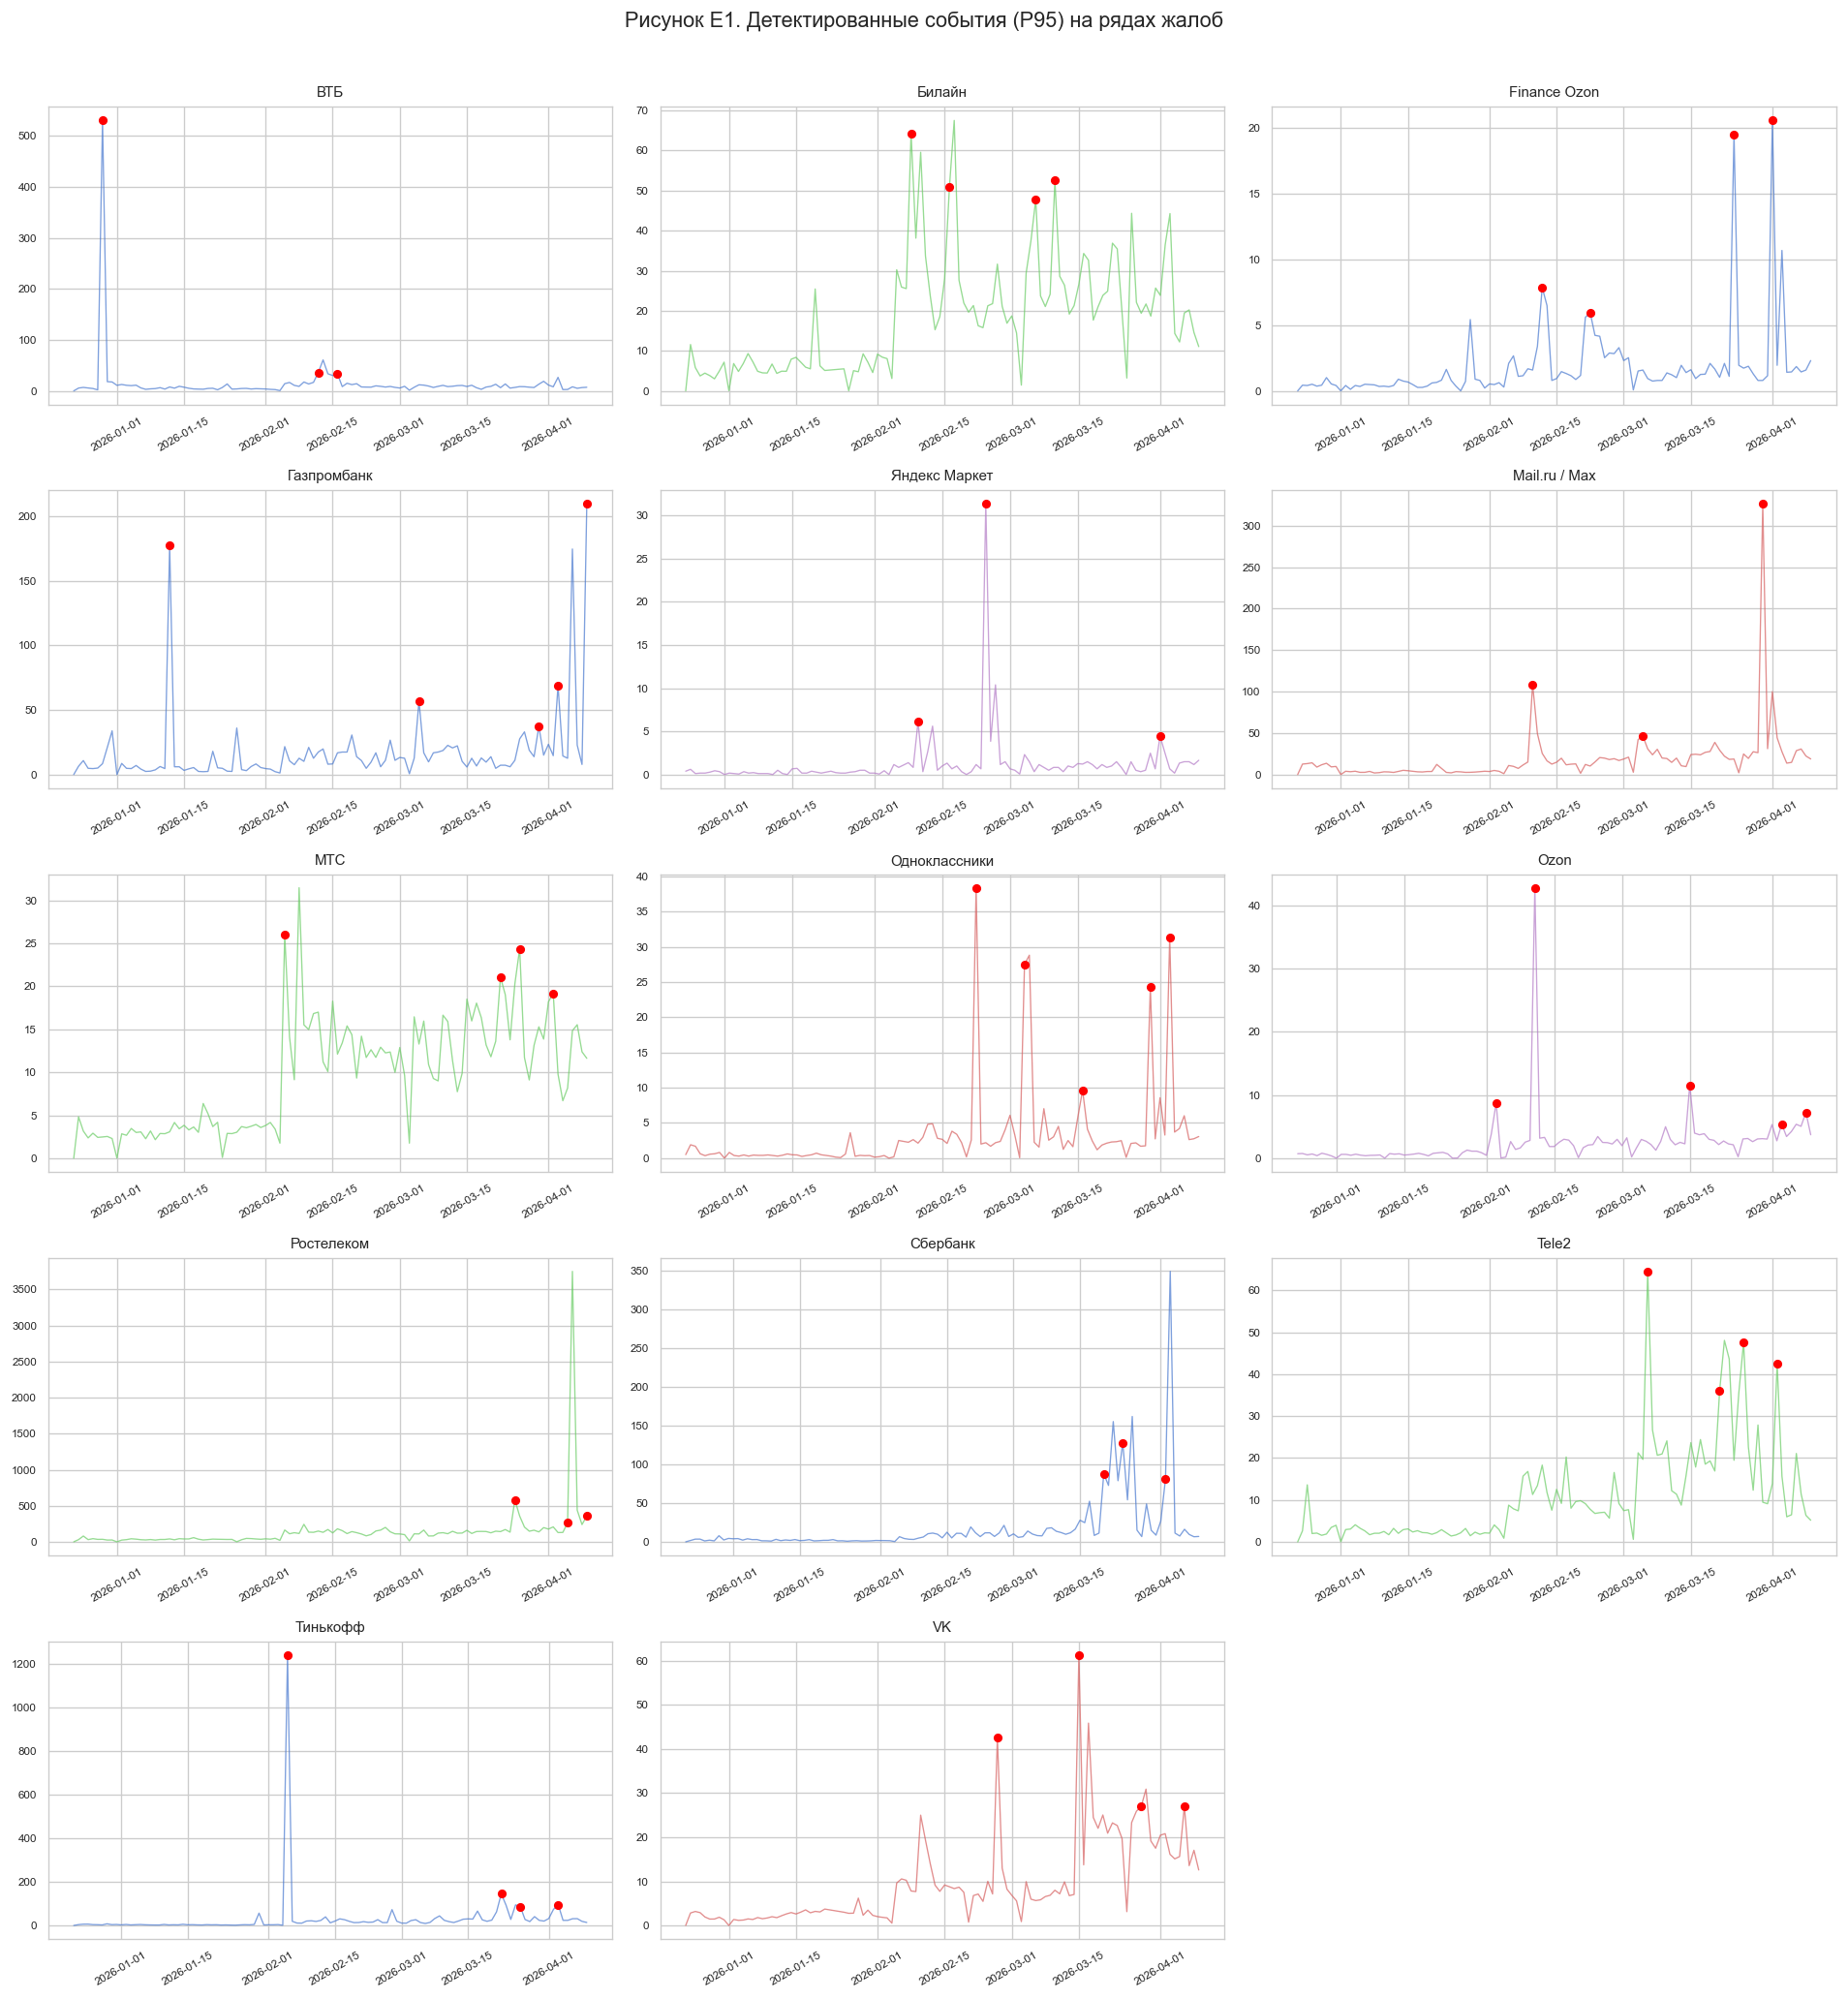

Рисунок E1 сохранён.


In [33]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for idx, company in enumerate(companies_list):
    sub = panel[panel['company_raw'] == company].sort_values('date')
    ax  = axes[idx]
    color = color_sector.get(SECTOR_MAP.get(company, ''), 'steelblue')
    ax.plot(sub['date'], sub['complaints_per_mln'], color=color, linewidth=0.8, alpha=0.7)
    events = sub[sub['event_flag'] == 1]
    ax.scatter(events['date'], events['complaints_per_mln'],
               color='red', zorder=5, s=20, label='Событие (P95)')
    ax.set_title(COMPANY_DISPLAY.get(company, company), fontsize=9)
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7)

for i in range(len(companies_list), len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Рисунок E1. Детектированные события (P95) на рядах жалоб', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUTPUT_DIR / 'Fig_E1_EventsOnTimeSeries.png', dpi=150)
plt.show()
print('Рисунок E1 сохранён.')

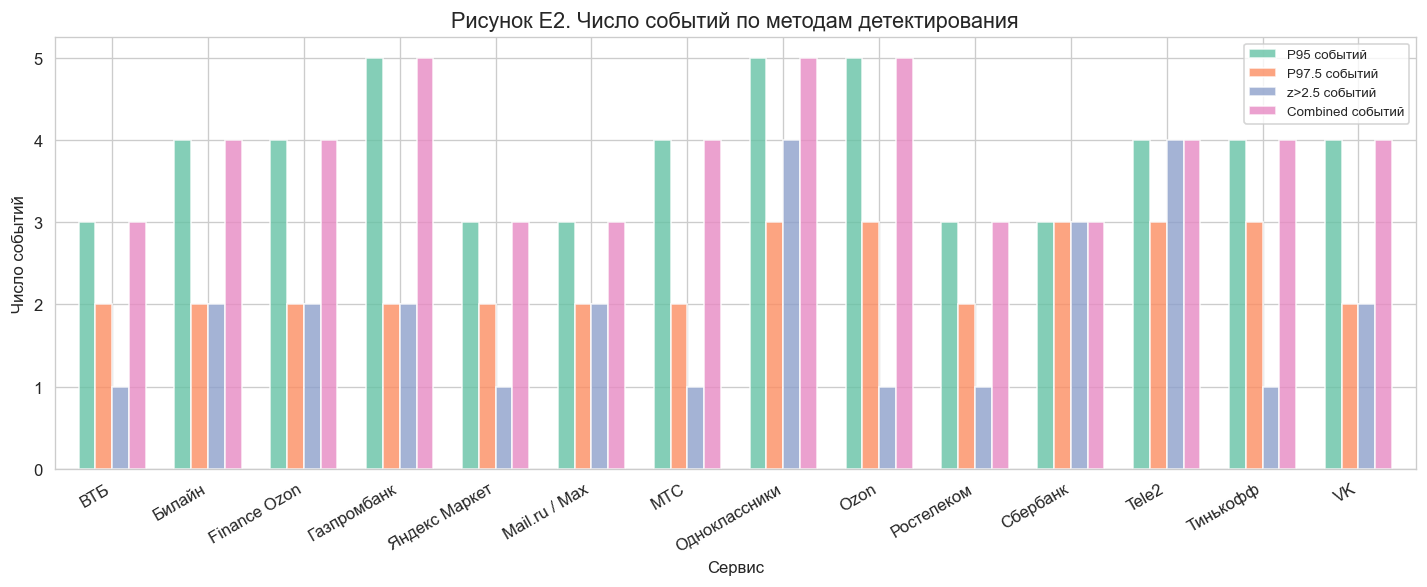

Рисунок E2 сохранён.


In [34]:
event_compare = table_e1.set_index('Сервис')[['P95 событий', 'P97.5 событий',
                                               'z>2.5 событий', 'Combined событий']]
fig, ax = plt.subplots(figsize=(12, 5))
event_compare.plot(kind='bar', ax=ax, alpha=0.8, edgecolor='white', width=0.7)
ax.set_ylabel('Число событий')
ax.set_title('Рисунок E2. Число событий по методам детектирования', fontsize=13)
ax.legend(fontsize=8)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Fig_E2_DetectionMethodsComparison.png', dpi=150)
plt.show()
print('Рисунок E2 сохранён.')

---
## МОДЕЛЬ 1. Event Study



In [35]:
ESTIMATION_WINDOW_CURRENT = (-40, -6)

def get_trading_sequence(stock_df, issuer, ref_date, window_start, window_end):
    """
    Возвращает торговые дни в окне [window_start; window_end] относительно ref_date.
    window_start, window_end — целые числа (дни, 0 = дата события).
    """
    sub = (
        stock_df[stock_df['issuer_name'] == issuer]
        .sort_values('date')[['date', 'return', 'market_return']]
        .dropna(subset=['return'])
        .reset_index(drop=True)
    )

    dates = sub['date'].tolist()

    if ref_date in dates:
        event_idx = dates.index(ref_date)
    else:
        later = [d for d in dates if d >= ref_date]
        if not later:
            return None
        event_idx = dates.index(later[0])

    start_idx = event_idx + window_start
    end_idx = event_idx + window_end

    if start_idx < 0 or end_idx >= len(dates):
        return None

    return sub.iloc[start_idx:end_idx + 1].copy()


def estimate_market_model(stock_df, issuer, event_date, est_start, est_end):

    est_data = get_trading_sequence(stock_df, issuer, event_date, est_start, est_end)

    if est_data is None or len(est_data) < 15:
        return None, None

    X = sm.add_constant(est_data['market_return'].values)
    y = est_data['return'].values

    try:
        result = sm.OLS(y, X).fit()
        return result.params[0], result.params[1]  
    except Exception:
        return None, None


def run_event_study(panel_df, stock_df,
                    event_col='event_flag',
                    event_windows=EVENT_WINDOWS,
                    est_start=ESTIMATION_WINDOW_CURRENT[0],
                    est_end=ESTIMATION_WINDOW_CURRENT[1],
                    exclude_systemic=False):

    events = panel_df[
        panel_df[event_col] == 1
    ][['company_raw', 'issuer_name', 'date', 'sector', 'systemic_banking_outage']].copy()

    if exclude_systemic:
        events = events[events['systemic_banking_outage'] == 0]

    results = []

    for _, ev in events.iterrows():
        issuer = ev['issuer_name']
        if pd.isna(issuer):
            continue

        alpha, beta = estimate_market_model(
            stock_df=stock_df,
            issuer=issuer,
            event_date=ev['date'],
            est_start=est_start,
            est_end=est_end
        )

        if alpha is None:
            continue

        row = {
            'company_raw': ev['company_raw'],
            'issuer_name': issuer,
            'sector': ev['sector'],
            'event_date': ev['date'],
            'alpha': alpha,
            'beta': beta,
        }

        for win_name, (w_start, w_end) in event_windows.items():
            win_data = get_trading_sequence(stock_df, issuer, ev['date'], w_start, w_end)

            if win_data is None or len(win_data) == 0:
                row[f'CAR_{win_name}'] = np.nan
                if win_name == '[0]':
                    row['AR_0'] = np.nan
            else:
                ar_vals = win_data['return'].values - (
                    alpha + beta * win_data['market_return'].values
                )

                row[f'CAR_{win_name}'] = ar_vals.sum()

                if win_name == '[0]':
                    row['AR_0'] = ar_vals[0] if len(ar_vals) > 0 else np.nan

        results.append(row)

    return pd.DataFrame(results)

es_results = run_event_study(panel, stock)

print(f'Event study завершён. Событий с результатами: {len(es_results)}')

if len(es_results) > 0:
    display(es_results.head())
else:
    print('Нет событий, для которых удалось оценить market model.')

Event study завершён. Событий с результатами: 50


,company_raw,issuer_name,sector,event_date,alpha,beta,CAR_[0],AR_0,CAR_[0;+1],CAR_[-1;+1],CAR_[-2;+2]
0,bank-vtb,bank-vtb,Банки,2025-12-29,0.0001,0.8739,0.0005,0.0005,0.0003,0.0000,-0.0014
1,bank-vtb,bank-vtb,Банки,2026-02-12,0.0002,1.4574,-0.0009,-0.0009,0.0007,0.0009,-0.0225
2,bank-vtb,bank-vtb,Банки,2026-02-16,-0.0002,1.2387,0.0033,0.0033,0.0036,0.0072,0.0055
3,financeozon,ozon,Банки,2026-02-12,-0.0001,1.2537,0.0028,0.0028,0.0025,0.0050,0.0140
4,financeozon,ozon,Банки,2026-02-22,0.0004,0.2193,-0.0004,-0.0004,-0.0012,-0.0024,-0.0040


In [36]:
summary = {}

if len(es_results) > 0:
    summary['AR_0_mean'] = es_results['AR_0'].mean()

    for col in es_results.columns:
        if col.startswith('CAR_'):
            summary[col + '_mean'] = es_results[col].mean()

summary_table = pd.DataFrame([summary])
display(summary_table)

summary_table.to_csv(OUTPUT_DIR / 'Table_F1_EventStudy_Summary.csv',
                     index=False, encoding='utf-8-sig')

print('Таблица F1 сохранена.')

,AR_0_mean,CAR_[0]_mean,CAR_[0;+1]_mean,CAR_[-1;+1]_mean,CAR_[-2;+2]_mean
0,0.0004,0.0004,0.0007,0.0005,0.0000


Таблица F1 сохранена.


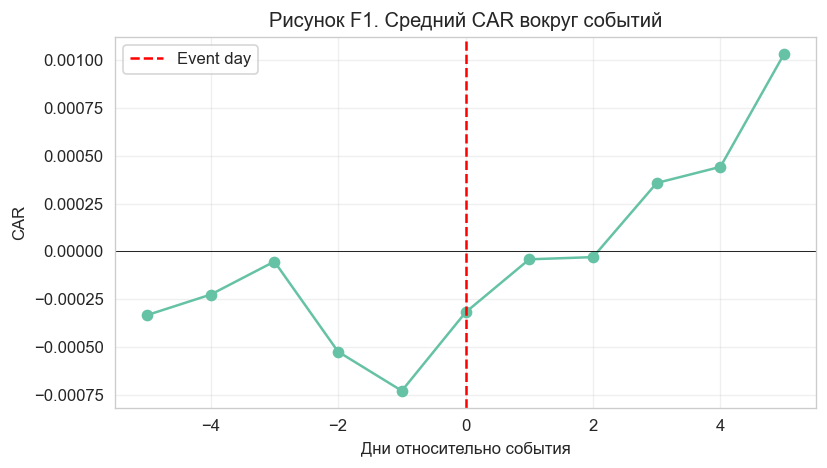

Рисунок F1 сохранён.


In [37]:
window_range = range(-5, 6)  # [-5, +5]
car_matrix = []

for _, ev in es_results.iterrows():
    issuer = ev['issuer_name']
    event_date = ev['event_date']

    win_data = get_trading_sequence(stock, issuer, event_date, -5, 5)
    if win_data is None or len(win_data) < 5:
        continue

    alpha = ev['alpha']
    beta  = ev['beta']

    ar_vals = win_data['return'].values - (
        alpha + beta * win_data['market_return'].values
    )

    car_vals = np.cumsum(ar_vals)
    car_matrix.append(car_vals)

if len(car_matrix) > 0:
    mean_car = np.mean(car_matrix, axis=0)

    plt.figure(figsize=(7, 4))
    plt.plot(window_range[:len(mean_car)], mean_car, marker='o')
    plt.axvline(0, color='red', linestyle='--', label='Event day')
    plt.axhline(0, color='black', linewidth=0.5)
    plt.title('Рисунок F1. Средний CAR вокруг событий')
    plt.xlabel('Дни относительно события')
    plt.ylabel('CAR')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(OUTPUT_DIR / 'Fig_F1_Mean_CAR.png', dpi=150)
    plt.show()

    print('Рисунок F1 сохранён.')
else:
    print('Недостаточно данных для графика CAR')

In [38]:
sector_summary = es_results.groupby('sector')[['AR_0'] + 
    [c for c in es_results.columns if c.startswith('CAR_')]].mean()

display(sector_summary)

sector_summary.to_csv(OUTPUT_DIR / 'Table_F2_CAR_BySector.csv',
                      encoding='utf-8-sig')

print('Таблица F2 сохранена.')

,AR_0,CAR_[0],CAR_[0;+1],CAR_[-1;+1],CAR_[-2;+2]
sector,,,,,
Банки,0.0002,0.0002,0.0007,0.0007,-0.0017
Маркетплейсы,-0.0003,-0.0003,0.0000,-0.0004,-0.0023
Соцсети,0.0017,0.0017,0.0015,0.0016,0.0036
Телеком,-0.0002,-0.0002,0.0002,-0.0005,0.0009


Таблица F2 сохранена.


In [39]:
from scipy.stats import wilcoxon

def summarize_car(es_df, group_col=None):
    car_cols = [c for c in es_df.columns if c.startswith("CAR_")]
    rows = []
    groups = es_df[group_col].unique() if group_col else ["All"]
    for grp in groups:
        sub = es_df if group_col is None else es_df[es_df[group_col] == grp]
        for col in car_cols:
            vals = sub[col].dropna()
            if len(vals) < 3:
                continue
            t_stat, p_val = stats.ttest_1samp(vals, 0)
            try:
                w_stat, w_pval = (wilcoxon(vals, alternative="two-sided")
                                  if len(vals) >= 5 and vals.abs().sum() > 0
                                  else (float("nan"), float("nan")))
            except Exception:
                w_stat, w_pval = float("nan"), float("nan")
            def sig(p):
                if p != p: return ""
                return "***" if p<0.01 else ("**" if p<0.05 else ("*" if p<0.10 else ""))
            rows.append({
                "Группа"      : grp,
                "Окно"         : col.replace("CAR_", ""),
                "N событий"    : len(vals),
                "Mean CAR (%)" : round(vals.mean()*100, 3),
                "Std CAR (%)"  : round(vals.std()*100,  3),
                "t-stat"       : round(t_stat, 3),
                "p (t-test)"   : round(p_val, 4),
                "W-stat"       : round(w_stat, 2) if w_stat==w_stat else "n/a",
                "p (Wilcoxon)" : round(w_pval, 4) if w_pval==w_pval else "n/a",
                "Знач. (t)"    : sig(p_val),
                "Знач. (W)"    : sig(w_pval),
            })
    return pd.DataFrame(rows)


table_m2 = summarize_car(es_results)
display(table_m2)
table_m2.to_csv(OUTPUT_DIR / "Table_M2_CAR_Windows.csv", index=False, encoding="utf-8-sig")

if "AR_0" in es_results.columns:
    ar0_vals = es_results["AR_0"].dropna()
    t0, p0 = stats.ttest_1samp(ar0_vals, 0)
    try:
        w0, wp0 = (wilcoxon(ar0_vals, alternative="two-sided")
                   if len(ar0_vals) >= 5 else (float("nan"), float("nan")))
    except Exception:
        w0, wp0 = float("nan"), float("nan")
    table_m1 = pd.DataFrame([{
        "N событий"      : len(ar0_vals),
        "Mean AR_0 (%)"   : round(ar0_vals.mean()*100, 3),
        "Std AR_0 (%)"    : round(ar0_vals.std()*100,  3),
        "t-stat"          : round(t0, 3),
        "p (t-test)"      : round(p0, 4),
        "p (Wilcoxon)"    : round(wp0, 4) if wp0==wp0 else "n/a",
    }])
    display(table_m1)
    table_m1.to_csv(OUTPUT_DIR / "Table_M1_AR0.csv", index=False, encoding="utf-8-sig")

print("Таблицы M1, M2 сохранены.")


,Группа,Окно,N событий,Mean CAR (%),Std CAR (%),t-stat,p (t-test),W-stat,p (Wilcoxon),Знач. (t),Знач. (W)
0,All,[0],50,0.0410,0.2540,1.1450,0.2577,474.0000,0.1145,,
1,All,[0;+1],50,0.0690,0.3000,1.6260,0.1104,438.0000,0.0541,,*
2,All,[-1;+1],50,0.0480,0.4900,0.6980,0.4886,598.0000,0.7030,,
3,All,[-2;+2],50,0.0020,0.8290,0.0200,0.9844,588.0000,0.6328,,


,N событий,Mean AR_0 (%),Std AR_0 (%),t-stat,p (t-test),p (Wilcoxon)
0,50,0.0410,0.2540,1.1450,0.2577,0.1145


Таблицы M1, M2 сохранены.


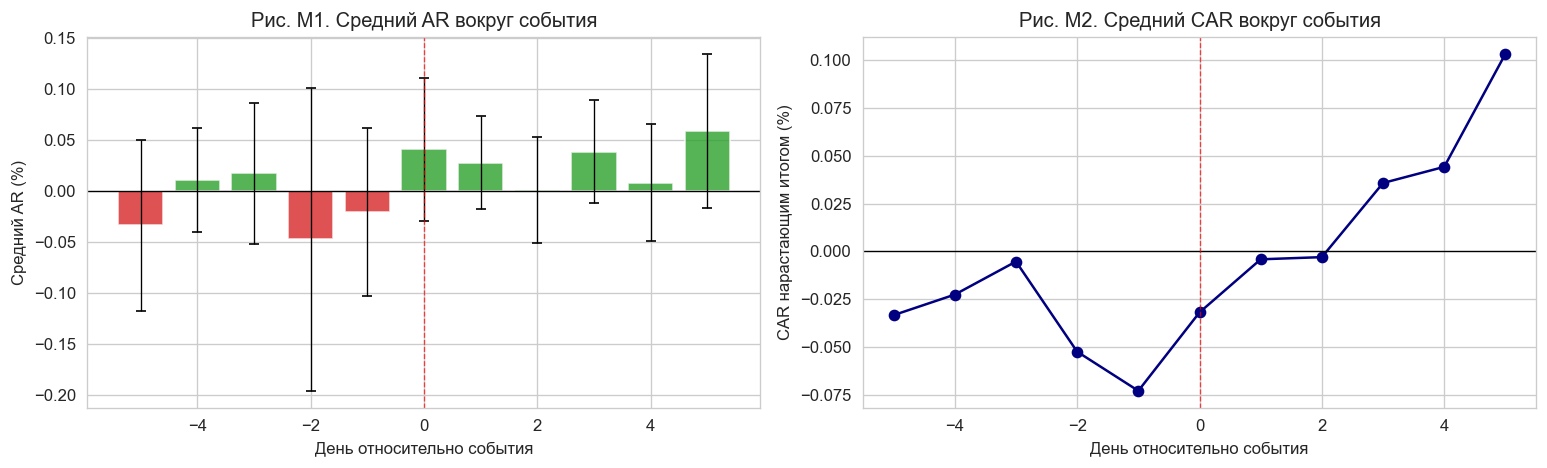

Рисунки M1, M2 сохранены.
    day  mean_ar  se_ar   n  cum_ar
0    -5  -0.0003 0.0004  50 -0.0003
1    -4   0.0001 0.0003  50 -0.0002
2    -3   0.0002 0.0004  50 -0.0001
3    -2  -0.0005 0.0008  50 -0.0005
4    -1  -0.0002 0.0004  50 -0.0007
5     0   0.0004 0.0004  50 -0.0003
6     1   0.0003 0.0002  50 -0.0000
7     2   0.0000 0.0003  50 -0.0000
8     3   0.0004 0.0003  50  0.0004
9     4   0.0001 0.0003  50  0.0004
10    5   0.0006 0.0004  50  0.0010


In [40]:
def compute_ar_around_event(panel_df, stock_df, event_col='event_flag',
                            window=5, est_start=-40, est_end=-6):
    """Считает AR для каждого дня [-window; +window] вокруг события."""
    events = panel_df[panel_df[event_col] == 1][['company_raw', 'issuer_name', 'date']].copy()
    all_ar = {d: [] for d in range(-window, window + 1)}

    for _, ev in events.iterrows():
        issuer = ev['issuer_name']
        if pd.isna(issuer):
            continue

        alpha, beta = estimate_market_model(stock_df, issuer, ev['date'], est_start, est_end)
        if alpha is None:
            continue

        for d in range(-window, window + 1):
            wd = get_trading_sequence(stock_df, issuer, ev['date'], d, d)
            if wd is not None and len(wd) == 1:
                ar = wd['return'].values[0] - (
                    alpha + beta * wd['market_return'].values[0]
                )
                all_ar[d].append(ar)

    summary = pd.DataFrame({
        'day': list(all_ar.keys()),
        'mean_ar': [np.mean(v) if len(v) > 0 else np.nan for v in all_ar.values()],
        'se_ar': [np.std(v, ddof=1) / np.sqrt(len(v)) if len(v) > 1 else np.nan for v in all_ar.values()],
        'n': [len(v) for v in all_ar.values()],
    }).sort_values('day')

    return summary


ar_around = compute_ar_around_event(panel, stock, window=5, est_start=-40, est_end=-6)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(
    ar_around['day'],
    ar_around['mean_ar'] * 100,
    color=np.where(ar_around['mean_ar'].fillna(0) >= 0, '#2ca02c', '#d62728'),
    alpha=0.8,
    edgecolor='white'
)
ax.errorbar(
    ar_around['day'],
    ar_around['mean_ar'] * 100,
    yerr=ar_around['se_ar'] * 100 * 1.96,
    fmt='none',
    color='black',
    capsize=3,
    linewidth=0.8
)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_xlabel('День относительно события')
ax.set_ylabel('Средний AR (%)')
ax.set_title('Рис. M1. Средний AR вокруг события')

ax = axes[1]
ar_around['cum_ar'] = ar_around['mean_ar'].cumsum()
ax.plot(
    ar_around['day'],
    ar_around['cum_ar'] * 100,
    marker='o',
    color='navy',
    linewidth=1.5
)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_xlabel('День относительно события')
ax.set_ylabel('CAR нарастающим итогом (%)')
ax.set_title('Рис. M2. Средний CAR вокруг события')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Fig_M1_M2_AR_CAR_Around_Event.png', dpi=150)
plt.show()

print('Рисунки M1, M2 сохранены.')
print(ar_around)

---
### Дополнение M3. Анализ экстремальных положительных значений AR


Порог P95 положительного хвоста AR_0: 0.515%

Таблица M2.7. Выбросы AR_0 > 0.515% (2 наблюдений):


,Дата,Компания,Сектор,AR_0 (%)
27,2026-02-03,Ozon,Маркетплейсы,0.6070
5,2026-03-24,Finance Ozon,Банки,0.5430



Сохранено в глобальной переменной `outlier_dates` (2 пар дата-компания) — используется в robustness 8.


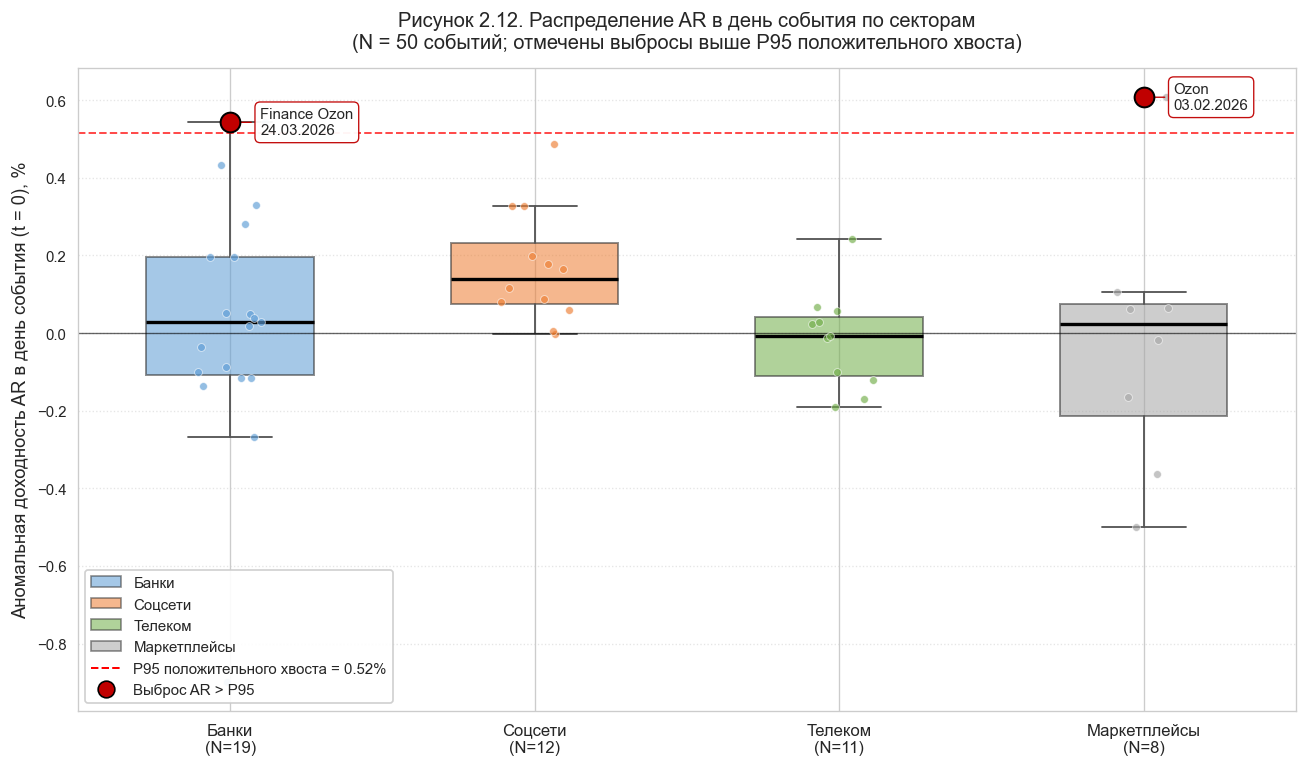

Рисунок 2.12 (boxplot AR по секторам) сохранён.


In [41]:
if 'AR_0' in es_results.columns:
    pos_ar = es_results[es_results['AR_0'] > 0].copy()
    if len(pos_ar) > 0:
        p95_pos = pos_ar['AR_0'].quantile(0.95)
        print(f'Порог P95 положительного хвоста AR_0: {p95_pos*100:.3f}%')

        outliers = es_results[es_results['AR_0'] > p95_pos].copy()
        outliers = outliers.sort_values('AR_0', ascending=False)
        outliers['company_display'] = outliers['company_raw'].map(COMPANY_DISPLAY)
        outliers['AR_0 (%)'] = (outliers['AR_0'] * 100).round(3)

        table_m27 = outliers[['event_date', 'company_display', 'sector', 'AR_0 (%)']].copy()
        table_m27 = table_m27.rename(columns={
            'event_date': 'Дата',
            'company_display': 'Компания',
            'sector': 'Сектор',
        })
        print(f'\nТаблица M2.7. Выбросы AR_0 > {p95_pos*100:.3f}% '
              f'({len(table_m27)} наблюдений):')
        display(table_m27)
        table_m27.to_csv(OUTPUT_DIR / 'Table_M2_7_AR_Outliers.csv',
                         index=False, encoding='utf-8-sig')

        outlier_dates = set(zip(outliers['event_date'].dt.date, outliers['company_raw']))
        print(f'\nСохранено в глобальной переменной `outlier_dates` '
              f'({len(outlier_dates)} пар дата-компания) — используется в robustness 8.')
    else:
        print('В выборке нет положительных AR.')
        outlier_dates = set()
        p95_pos = None
else:
    print('В es_results отсутствует колонка AR_0.')
    outlier_dates = set()
    p95_pos = None

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Готовим данные: AR_0 в процентах по секторам
es_plot = es_results.dropna(subset=['AR_0', 'sector']).copy()
es_plot['AR_0_pct'] = es_plot['AR_0'] * 100
es_plot['company_display'] = es_plot['company_raw'].map(COMPANY_DISPLAY)
sector_order = (es_plot.groupby('sector').size()
                .sort_values(ascending=False).index.tolist())

sector_colors = {
    'Банки':        '#5B9BD5',
    'Телеком':      '#70AD47',
    'Соцсети':      '#ED7D31',
    'Маркетплейсы': '#A5A5A5',
}


box_data   = [es_plot.loc[es_plot['sector'] == s, 'AR_0_pct'].values for s in sector_order]
box_sizes  = [len(d) for d in box_data]
box_labels = [f'{s}\n(N={n})' for s, n in zip(sector_order, box_sizes)]

fig, ax = plt.subplots(figsize=(11, 6.5))

bp = ax.boxplot(
    box_data,
    labels=box_labels,
    patch_artist=True,
    widths=0.55,
    showfliers=False,                                       # выбросы вручную
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='#555555', linewidth=1.1),
    capprops=dict(color='#555555', linewidth=1.1),
    boxprops=dict(linewidth=1.2, edgecolor='#333333'),
)

# Заливка боксов цветом сектора
for patch, sec in zip(bp['boxes'], sector_order):
    patch.set_facecolor(sector_colors.get(sec, '#BBBBBB'))
    patch.set_alpha(0.55)

rng = np.random.default_rng(seed=42)
for i, sec in enumerate(sector_order, start=1):
    sub = es_plot.loc[es_plot['sector'] == sec, 'AR_0_pct'].values
    jitter = rng.uniform(-0.12, 0.12, size=len(sub))
    ax.scatter(np.full_like(sub, i, dtype=float) + jitter, sub,
               s=22, alpha=0.65,
               color=sector_colors.get(sec, '#666666'),
               edgecolor='white', linewidth=0.5, zorder=3)

# Нулевая линия для ориентира
ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)

# Линия P95 положительного хвоста
if p95_pos is not None:
    p95_pct = p95_pos * 100
    ax.axhline(p95_pct, color='red', linestyle='--', linewidth=1.2, alpha=0.7,
               label=f'P95 положительного хвоста = {p95_pct:.2f}%')

if p95_pos is not None and len(outliers) > 0:
    for _, row in outliers.iterrows():
        sec = row['sector']
        if sec not in sector_order:
            continue
        x_pos = sector_order.index(sec) + 1
        y_pos = row['AR_0'] * 100
        ax.scatter([x_pos], [y_pos], s=140, color='#C00000',
                   edgecolor='black', linewidth=1.2, zorder=5)
        label = f"{row['company_display']}\n{row['event_date'].strftime('%d.%m.%Y')}"
        ax.annotate(
            label,
            xy=(x_pos, y_pos),
            xytext=(18, 0),
            textcoords='offset points',
            fontsize=9, va='center', ha='left',
            bbox=dict(boxstyle='round,pad=0.35',
                      facecolor='white', edgecolor='#C00000', linewidth=0.8, alpha=0.95),
            arrowprops=dict(arrowstyle='-', color='#C00000', lw=0.8),
        )

ax.set_ylabel('Аномальная доходность AR в день события (t = 0), %', fontsize=11)
ax.set_title('Рисунок 2.12. Распределение AR в день события по секторам\n'
             f'(N = {len(es_plot)} событий; отмечены выбросы выше P95 положительного хвоста)',
             fontsize=12, pad=12)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.set_axisbelow(True)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=9)

# Легенда
legend_handles = [
    mpatches.Patch(facecolor=sector_colors[s], alpha=0.55,
                   edgecolor='#333333', label=s)
    for s in sector_order
]
if p95_pos is not None:
    legend_handles.append(
        plt.Line2D([0], [0], color='red', linestyle='--', linewidth=1.2,
                   label=f'P95 положительного хвоста = {p95_pos*100:.2f}%')
    )
legend_handles.append(
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#C00000',
               markeredgecolor='black', markersize=10, label='Выброс AR > P95')
)
ax.legend(handles=legend_handles, loc='lower left', fontsize=9, framealpha=0.92)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Fig_2_12_AR_Boxplot_Sectors.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Рисунок 2.12 (boxplot AR по секторам) сохранён.')

In [42]:
if 'AR_0' in es_results.columns:
    # Положительные AR и их P95
    pos_ar = es_results[es_results['AR_0'] > 0].copy()
    if len(pos_ar) > 0:
        p95_pos = pos_ar['AR_0'].quantile(0.95)
        print(f'Порог P95 положительного хвоста AR_0: {p95_pos*100:.3f}%')

        outliers = es_results[es_results['AR_0'] > p95_pos].copy()
        outliers = outliers.sort_values('AR_0', ascending=False)
        outliers['company_display'] = outliers['company_raw'].map(COMPANY_DISPLAY)
        outliers['AR_0 (%)'] = (outliers['AR_0'] * 100).round(3)

        table_m27 = outliers[['event_date', 'company_display', 'sector', 'AR_0 (%)']].copy()
        table_m27 = table_m27.rename(columns={
            'event_date': 'Дата',
            'company_display': 'Компания',
            'sector': 'Сектор',
        })
        print(f'\nТаблица M2.7. Выбросы AR_0 > {p95_pos*100:.3f}% '
              f'({len(table_m27)} наблюдений):')
        display(table_m27)
        table_m27.to_csv(OUTPUT_DIR / 'Table_M2_7_AR_Outliers.csv',
                         index=False, encoding='utf-8-sig')

        # Список дат для дальнейшей проверки новостного фона
        outlier_dates = set(zip(outliers['event_date'].dt.date, outliers['company_raw']))
        print(f'\nСохранено в глобальной переменной `outlier_dates` '
              f'({len(outlier_dates)} пар дата-компания) — используется в robustness 8.')
    else:
        print('В выборке нет положительных AR.')
        outlier_dates = set()
else:
    print('В es_results отсутствует колонка AR_0.')
    outlier_dates = set()


Порог P95 положительного хвоста AR_0: 0.515%

Таблица M2.7. Выбросы AR_0 > 0.515% (2 наблюдений):


,Дата,Компания,Сектор,AR_0 (%)
27,2026-02-03,Ozon,Маркетплейсы,0.6070
5,2026-03-24,Finance Ozon,Банки,0.5430



Сохранено в глобальной переменной `outlier_dates` (2 пар дата-компания) — используется в robustness 8.


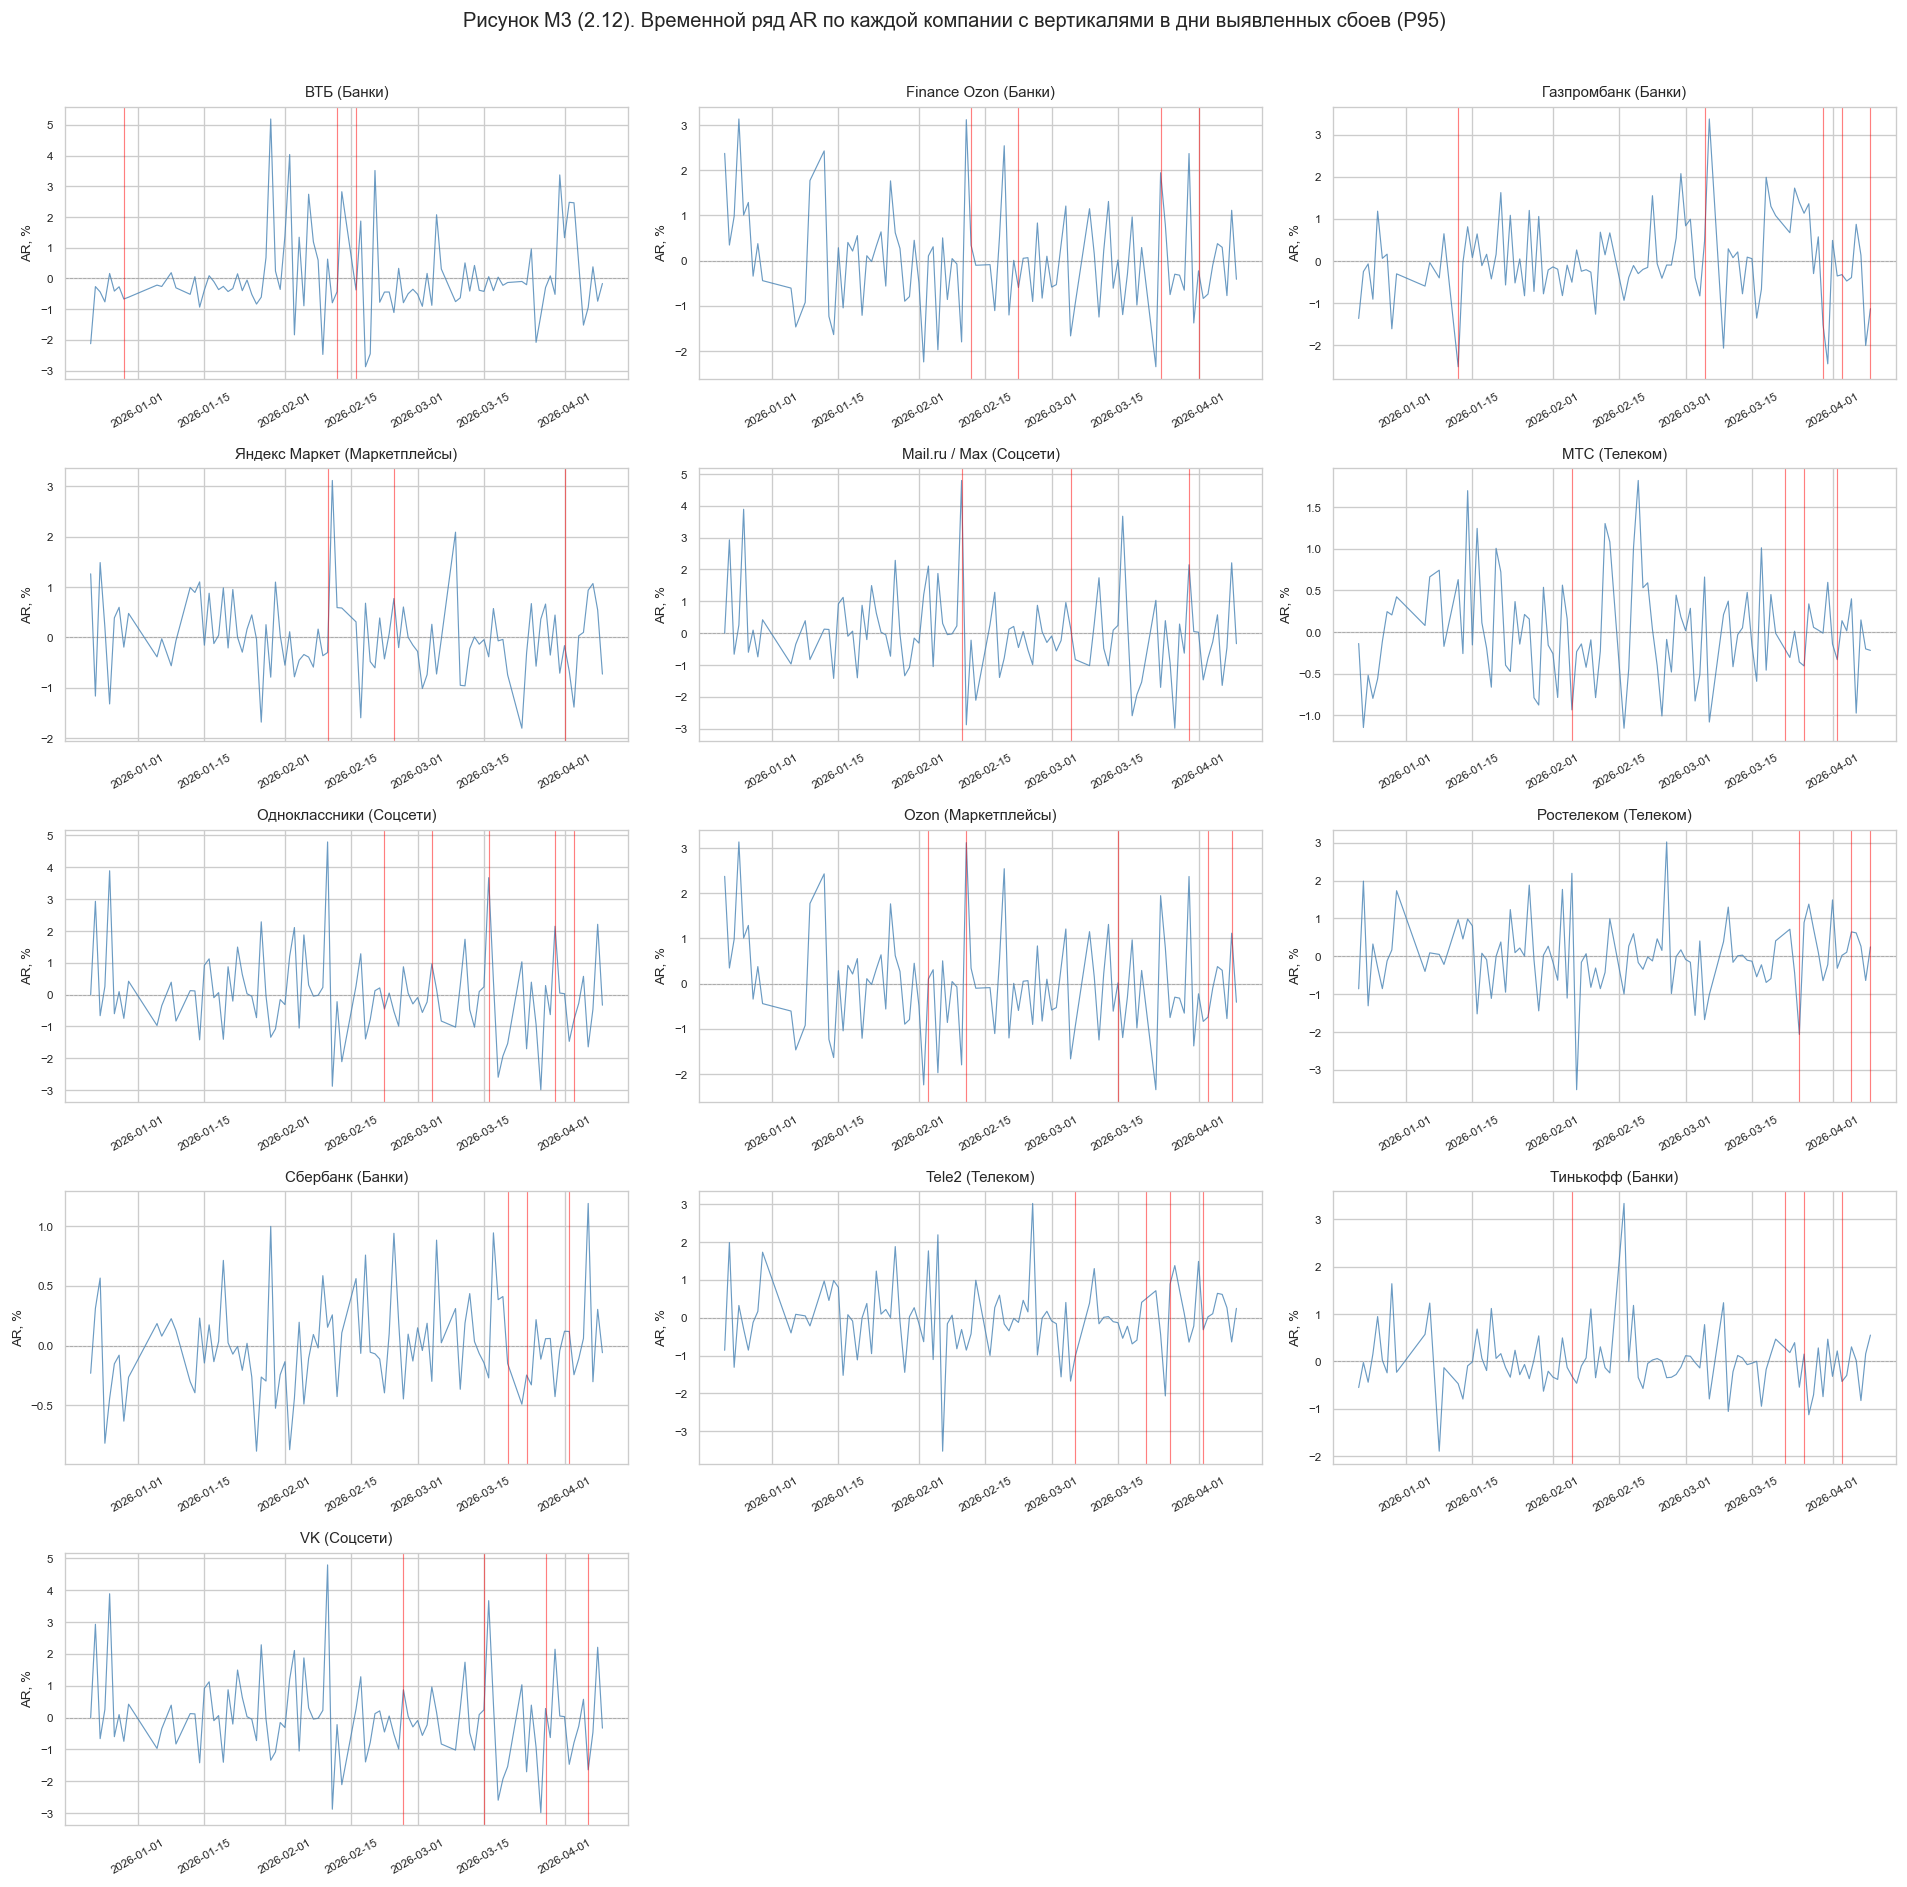

Рисунок M3 (2.12) сохранён.


In [43]:
ar_timeseries = []
for issuer in sorted(stock_daily['issuer_name'].dropna().unique()):
    sub = stock_daily[stock_daily['issuer_name'] == issuer][
        ['date', 'return', 'market_return']].dropna().sort_values('date')
    if len(sub) < 20:
        continue
    X = sm.add_constant(sub['market_return'].values)
    y = sub['return'].values
    try:
        ols = sm.OLS(y, X).fit()
        alpha, beta = ols.params
    except Exception:
        continue
    tmp = sub.copy()
    tmp['AR'] = tmp['return'] - (alpha + beta * tmp['market_return'])
    tmp['issuer_name'] = issuer
    ar_timeseries.append(tmp[['issuer_name', 'date', 'AR']])

ar_ts = pd.concat(ar_timeseries, ignore_index=True) if ar_timeseries else pd.DataFrame()
issuer_to_companies = {}
for comp, iss in SERVICE_TO_ISSUER.items():
    if iss is None:
        continue
    issuer_to_companies.setdefault(iss, []).append(comp)

companies_with_ar = [c for c in companies_list if SERVICE_TO_ISSUER.get(c) is not None]
n_cols_m3 = 3
n_rows_m3 = (len(companies_with_ar) + n_cols_m3 - 1) // n_cols_m3
fig, axes = plt.subplots(n_rows_m3, n_cols_m3,
                         figsize=(16, n_rows_m3 * 3.2), sharex=False)
axes = axes.flatten()

for idx, company in enumerate(companies_with_ar):
    issuer = SERVICE_TO_ISSUER[company]
    ax = axes[idx]

    # Сам временной ряд AR
    sub_ar = ar_ts[ar_ts['issuer_name'] == issuer].sort_values('date')
    if len(sub_ar):
        ax.plot(sub_ar['date'], sub_ar['AR'] * 100,
                color='steelblue', linewidth=0.7, alpha=0.8)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)

    evts = panel[(panel['company_raw'] == company) & (panel['event_flag'] == 1)]
    for d in evts['date']:
        ax.axvline(d, color='red', linewidth=0.7, alpha=0.5)

    sector = SECTOR_MAP.get(company, '')
    ax.set_title(f'{COMPANY_DISPLAY.get(company, company)} ({sector})', fontsize=9)
    ax.set_ylabel('AR, %', fontsize=8)
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7)

for i in range(len(companies_with_ar), len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Рисунок M3 (2.12). Временной ряд AR по каждой компании '
             'с вертикалями в дни выявленных сбоев (P95)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUTPUT_DIR / 'Fig_M3_AR_timeseries_2_12.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Рисунок M3 (2.12) сохранён.')


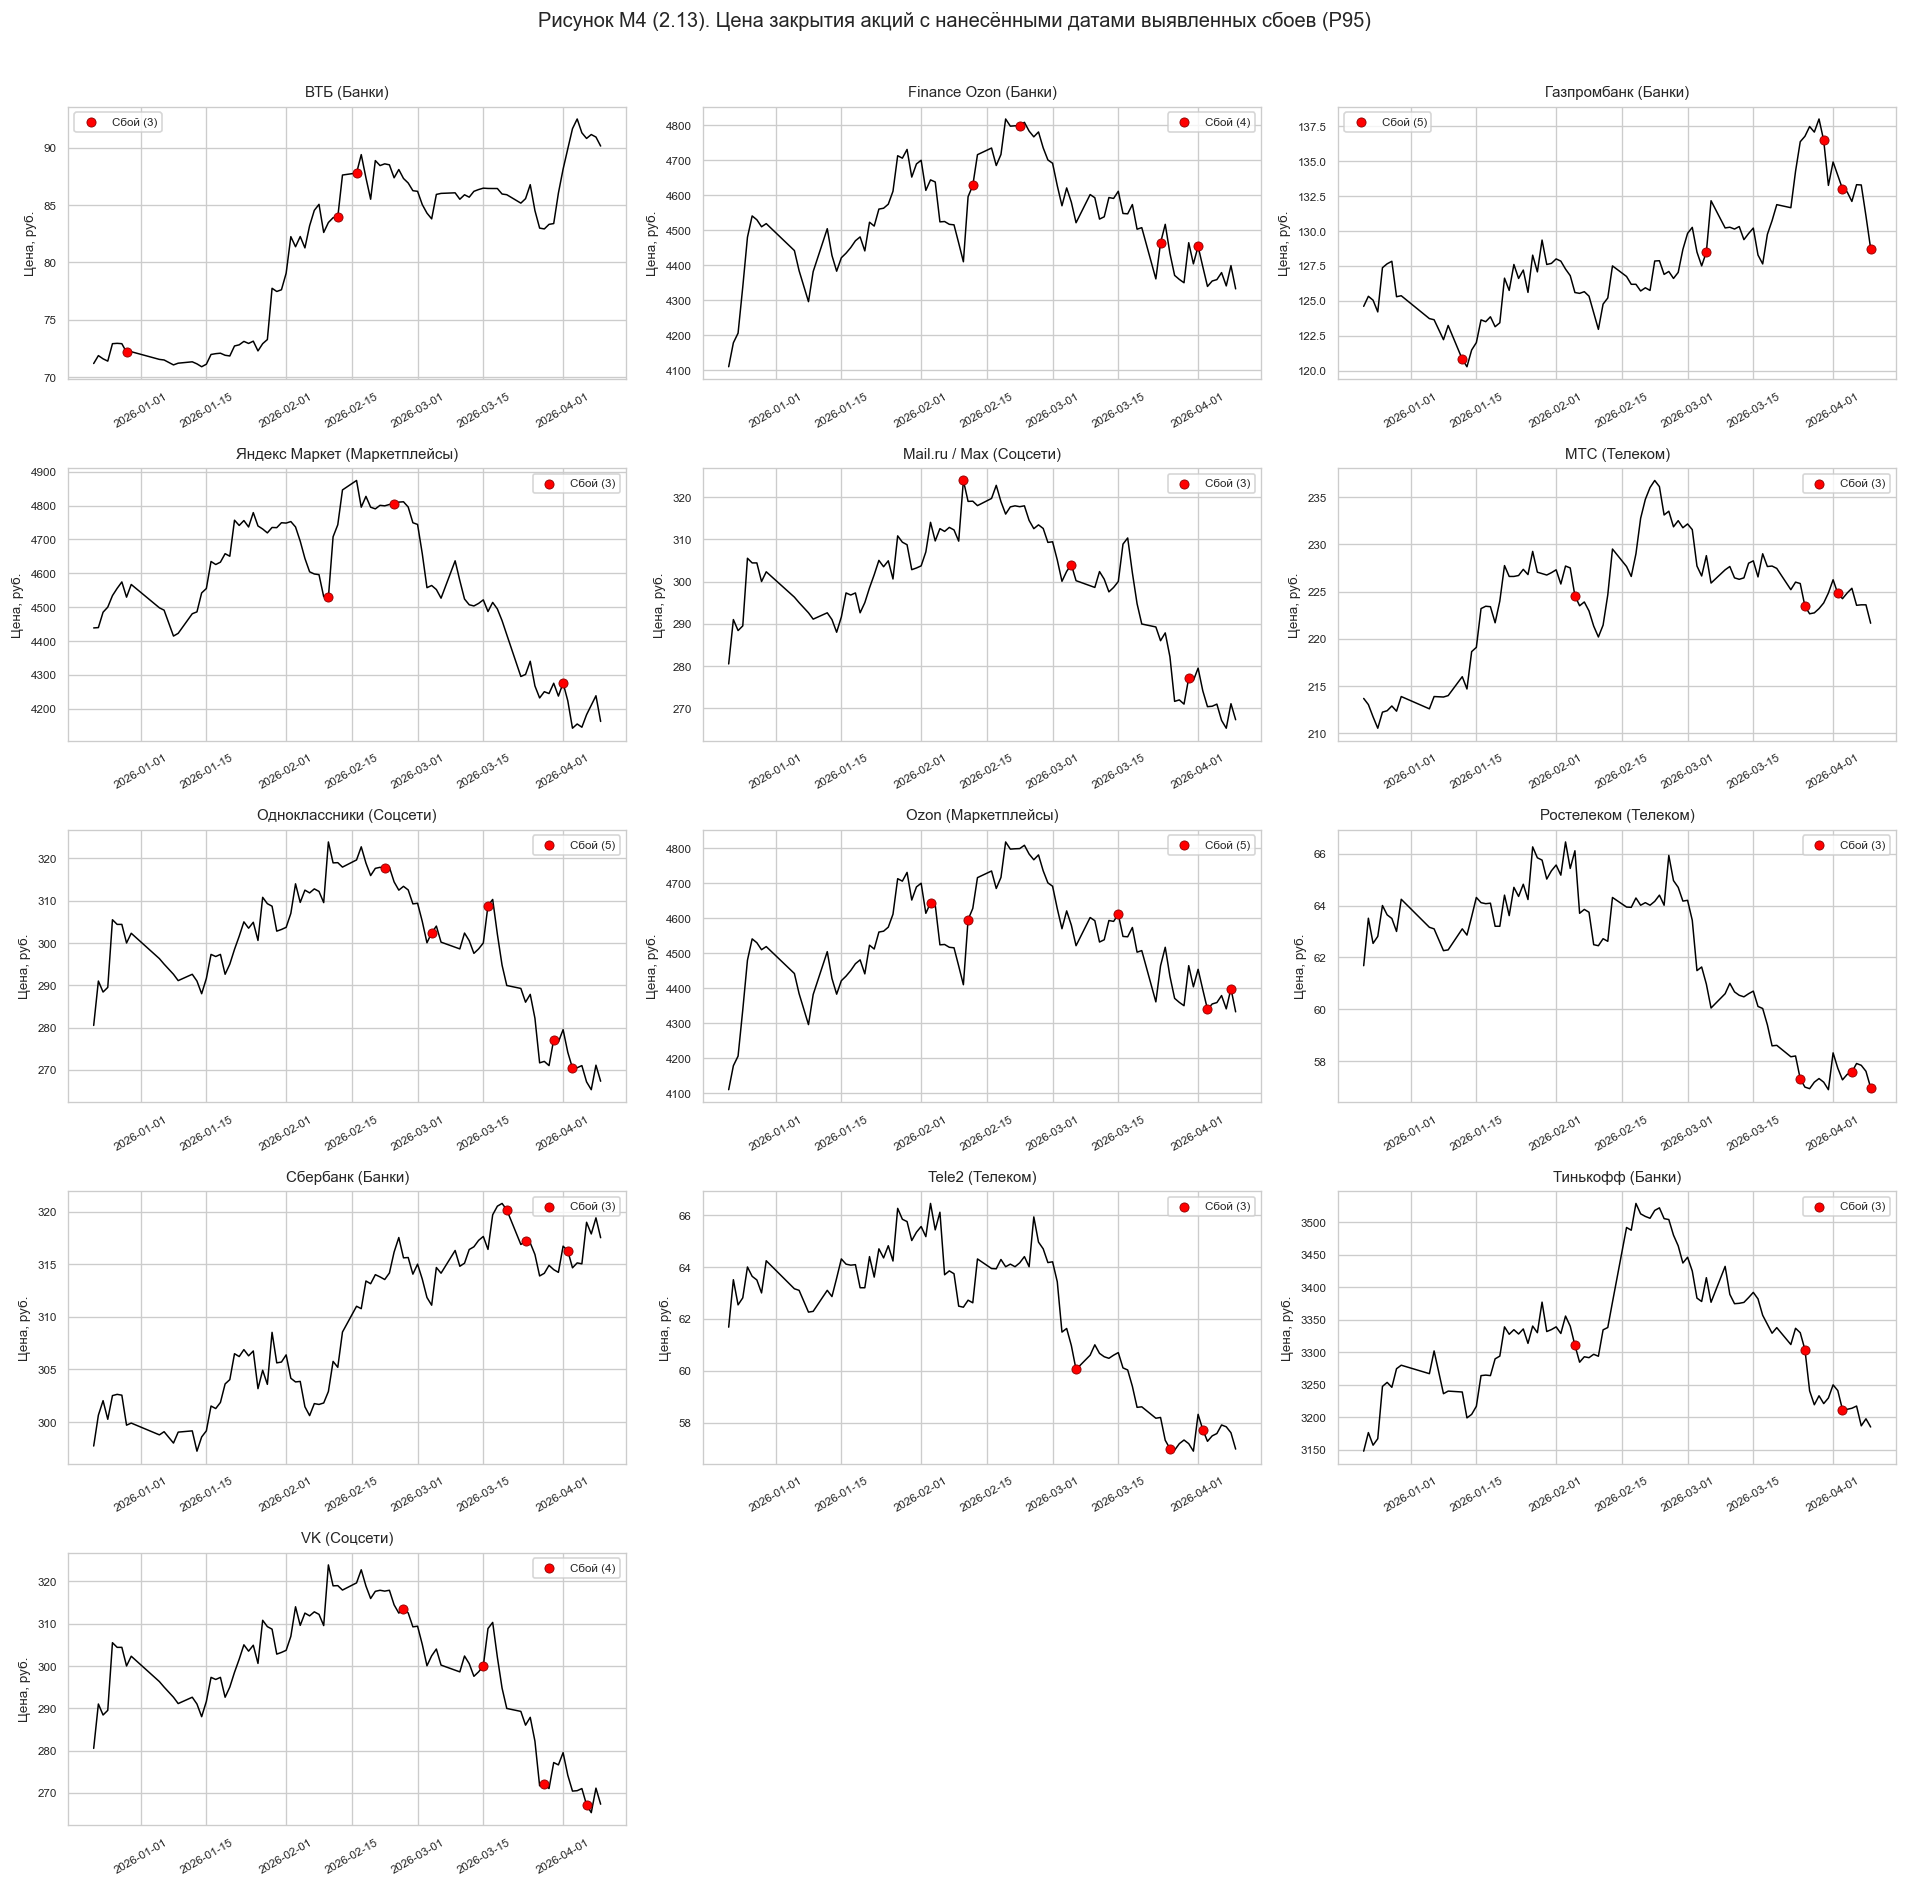

Рисунок M4 (2.13) сохранён.


In [44]:
fig, axes = plt.subplots(n_rows_m3, n_cols_m3,
                         figsize=(16, n_rows_m3 * 3.2), sharex=False)
axes = axes.flatten()

for idx, company in enumerate(companies_with_ar):
    issuer = SERVICE_TO_ISSUER[company]
    ax = axes[idx]
    sub_px = stock_daily[stock_daily['issuer_name'] == issuer][
        ['date', 'close_price']].dropna().sort_values('date')
    if len(sub_px):
        ax.plot(sub_px['date'], sub_px['close_price'],
                color='black', linewidth=0.9)

    evts = panel[(panel['company_raw'] == company) & (panel['event_flag'] == 1)][['date']]
    evts_with_px = evts.merge(sub_px, on='date', how='inner')
    if len(evts_with_px):
        ax.scatter(evts_with_px['date'], evts_with_px['close_price'],
                   color='red', s=30, marker='o', zorder=5,
                   edgecolor='darkred', linewidth=0.5,
                   label=f'Сбой ({len(evts_with_px)})')
        ax.legend(fontsize=7, loc='best')

    sector = SECTOR_MAP.get(company, '')
    ax.set_title(f'{COMPANY_DISPLAY.get(company, company)} ({sector})', fontsize=9)
    ax.set_ylabel('Цена, руб.', fontsize=8)
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7)

for i in range(len(companies_with_ar), len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Рисунок M4 (2.13). Цена закрытия акций с нанесёнными '
             'датами выявленных сбоев (P95)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUTPUT_DIR / 'Fig_M4_Prices_with_events_2_13.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Рисунок M4 (2.13) сохранён.')


In [45]:
table_m3 = summarize_car(es_results, group_col='sector')
display(table_m3)
table_m3.to_csv(OUTPUT_DIR / 'Table_M3_CAR_BySector.csv',
                index=False, encoding='utf-8-sig')

if 'systemic_banking_outage' in es_results.columns:
    es_no_systemic = es_results[es_results['systemic_banking_outage'] == 0]
else:
    es_no_systemic = es_results.copy()

table_m4 = summarize_car(es_no_systemic)
table_m4['Примечание'] = 'Без системных шоков'

display(table_m4)
table_m4.to_csv(OUTPUT_DIR / 'Table_M4_CAR_NoSystemic.csv',
                index=False, encoding='utf-8-sig')

print('Таблицы M3, M4 сохранены.')

,Группа,Окно,N событий,Mean CAR (%),Std CAR (%),t-stat,p (t-test),W-stat,p (Wilcoxon),Знач. (t),Знач. (W)
0,Банки,[0],19,0.0210,0.3060,0.3050,0.7640,81.0000,0.5949,,
1,Банки,[0;+1],19,0.0710,0.3750,0.8280,0.4188,68.0000,0.2935,,
2,Банки,[-1;+1],19,0.0740,0.5300,0.6110,0.5490,86.0000,0.7381,,
3,Банки,[-2;+2],19,-0.1730,1.0160,-0.7440,0.4665,86.0000,0.7381,,
4,Маркетплейсы,[0],8,-0.0250,0.3370,-0.2120,0.8380,17.0000,0.9453,,
5,Маркетплейсы,[0;+1],8,0.0030,0.3020,0.0270,0.9794,17.0000,0.9453,,
6,Маркетплейсы,[-1;+1],8,-0.0420,0.6860,-0.1730,0.8672,15.0000,0.7422,,
7,Маркетплейсы,[-2;+2],8,-0.2260,0.8800,-0.7250,0.4919,13.0000,0.5469,,
8,Соцсети,[0],12,0.1700,0.1470,3.9970,0.0021,1.0000,0.0010,***,***
9,Соцсети,[0;+1],12,0.1510,0.2570,2.0290,0.0674,12.0000,0.0332,*,**


,Группа,Окно,N событий,Mean CAR (%),Std CAR (%),t-stat,p (t-test),W-stat,p (Wilcoxon),Знач. (t),Знач. (W),Примечание
0,All,[0],50,0.0410,0.2540,1.1450,0.2577,474.0000,0.1145,,,Без системных шоков
1,All,[0;+1],50,0.0690,0.3000,1.6260,0.1104,438.0000,0.0541,,*,Без системных шоков
2,All,[-1;+1],50,0.0480,0.4900,0.6980,0.4886,598.0000,0.7030,,,Без системных шоков
3,All,[-2;+2],50,0.0020,0.8290,0.0200,0.9844,588.0000,0.6328,,,Без системных шоков


Таблицы M3, M4 сохранены.


In [46]:

from scipy.stats.mstats import winsorize as _winsorize
#  A. ПОЧАСОВАЯ ПАНЕЛЬ 
panel_reg = panel_hourly[
    (panel_hourly['return'].notna()) &
    (panel_hourly['is_trading_hour_stock'] == 1) &
    (panel_hourly['company_raw'].notna())
].copy()

panel_reg['log_complaints'] = np.log1p(panel_reg['complaints_per_mln'])
panel_reg['log_complaints_lag1'] = panel_reg.groupby('company_raw')['log_complaints'].shift(1)
panel_reg['log_comments'] = np.log1p(panel_reg['comments_count'])

panel_reg['return_w'] = _winsorize(panel_reg['return'].values, limits=[0.01, 0.01])
panel_reg['abs_return'] = panel_reg['return_w'].abs()

panel_reg['spike_p90'] = panel_reg.groupby('company_raw')['complaints_per_mln'].transform(
    lambda x: (x > x.quantile(0.90)).astype(int))
panel_reg['spike_p95'] = panel_reg.groupby('company_raw')['complaints_per_mln'].transform(
    lambda x: (x > x.quantile(0.95)).astype(int))

panel_reg['spike_p90_lag1'] = panel_reg.groupby('company_raw')['spike_p90'].shift(1)
panel_reg['spike_p95_lag1'] = panel_reg.groupby('company_raw')['spike_p95'].shift(1)

panel_reg['log_complaints_sq'] = panel_reg['log_complaints'] ** 2

panel_reg['complaints_cum_24h'] = panel_reg.groupby('company_raw')['complaints_per_mln'].transform(
    lambda x: x.shift(1).rolling(24, min_periods=6).sum())
panel_reg['log_complaints_cum_24h'] = np.log1p(panel_reg['complaints_cum_24h'].fillna(0))

panel_reg = panel_reg.dropna(
    subset=['log_complaints_lag1', 'market_return', 'lagged_return'])

hour_dummies = pd.get_dummies(panel_reg['hour'], prefix='h', drop_first=True).astype(float)
panel_reg = pd.concat(
    [panel_reg.reset_index(drop=True), hour_dummies.reset_index(drop=True)], axis=1)
HOUR_COLS = hour_dummies.columns.tolist()

month_dummies = pd.get_dummies(panel_reg['month'], prefix='m', drop_first=True).astype(float)
panel_reg = pd.concat(
    [panel_reg.reset_index(drop=True), month_dummies.reset_index(drop=True)], axis=1)
MONTH_COLS = month_dummies.columns.tolist()

sector_dummies = pd.get_dummies(panel_reg['sector'], prefix='sec', drop_first=True).astype(float)
panel_reg = pd.concat(
    [panel_reg.reset_index(drop=True), sector_dummies.reset_index(drop=True)], axis=1)
SECTOR_COLS = sector_dummies.columns.tolist()

print(f'Почасовая панель для регрессии: {len(panel_reg):,} строк')
print(f'Компаний: {panel_reg["company_raw"].nunique()}')
print()

for col in ['log_complaints', 'complaints_per_mln']:
    if col not in panel_reg.columns:
        continue
    wv = panel_reg.groupby('company_raw')[col].transform(lambda x: x - x.mean()).var()
    bv = panel_reg.groupby('company_raw')[col].mean().var()
    icc = bv / (bv + wv) if (bv + wv) > 0 else 0
    print(f'{col}: within-var={wv:.4f}, between-var={bv:.4f}, ICC={icc:.3f}')

#  B. ДНЕВНАЯ ПАНЕЛЬ (новая — основная для панельных моделей)
panel_daily = panel[panel['return'].notna()].copy()
panel_daily['return_w'] = _winsorize(panel_daily['return'].values, limits=[0.01, 0.01])
panel_daily['abs_return'] = panel_daily['return_w'].abs()
panel_daily['log_complaints'] = np.log1p(panel_daily['complaints_per_mln'])
panel_daily['log_complaints_lag1'] = panel_daily.groupby('company_raw')['log_complaints'].shift(1)
panel_daily['log_comments'] = np.log1p(panel_daily['comments_count'])
panel_daily['log_complaints_sq'] = panel_daily['log_complaints'] ** 2

panel_daily['spike_p90'] = panel_daily.groupby('company_raw')['complaints_per_mln'].transform(
    lambda x: (x > x.quantile(0.90)).astype(int))
panel_daily['spike_p95'] = panel_daily.groupby('company_raw')['complaints_per_mln'].transform(
    lambda x: (x > x.quantile(0.95)).astype(int))
panel_daily['spike_p90_lag1'] = panel_daily.groupby('company_raw')['spike_p90'].shift(1)

md_daily = pd.get_dummies(panel_daily['month'], prefix='m', drop_first=True).astype(float)
panel_daily = pd.concat(
    [panel_daily.reset_index(drop=True), md_daily.reset_index(drop=True)], axis=1)
MONTH_COLS_D = md_daily.columns.tolist()

dow_daily = pd.get_dummies(panel_daily['day_of_week'], prefix='dow', drop_first=True).astype(float)
panel_daily = pd.concat(
    [panel_daily.reset_index(drop=True), dow_daily.reset_index(drop=True)], axis=1)
DOW_COLS_D = dow_daily.columns.tolist()

sd_daily = pd.get_dummies(panel_daily['sector'], prefix='sec', drop_first=True).astype(float)
panel_daily = pd.concat(
    [panel_daily.reset_index(drop=True), sd_daily.reset_index(drop=True)], axis=1)
SECTOR_COLS_D = sd_daily.columns.tolist()

panel_daily = panel_daily.dropna(subset=['log_complaints_lag1', 'market_return'])
if 'lagged_return' in panel_daily.columns:
    panel_daily = panel_daily.dropna(subset=['lagged_return'])

print(f'\nДневная панель для регрессии: {len(panel_daily):,} строк')
print(f'Компаний: {panel_daily["company_raw"].nunique()}')
print(f'Дней / компанию: {len(panel_daily)/panel_daily["company_raw"].nunique():.0f}')


Почасовая панель для регрессии: 17,919 строк
Компаний: 13

log_complaints: within-var=0.1637, between-var=0.1840, ICC=0.529
complaints_per_mln: within-var=463.0559, between-var=5.3393, ICC=0.011

Дневная панель для регрессии: 1,199 строк
Компаний: 13
Дней / компанию: 92


In [47]:
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from statsmodels.stats.outliers_influence import variance_inflation_factor

def run_panel_model(df, y_col, x_cols,
                    entity_col='company_raw',
                    time_col='datetime_hour',
                    entity_effects=True,
                    time_effects=False,
                    se_type='clustered',         
                    verbose=True,
                    label='',
                    show_vif=False):
    cols_needed = [entity_col, time_col, y_col] + x_cols
    df_clean = df[cols_needed].dropna().copy()
    if len(df_clean) < 30:
        print(f"  Мало наблюдений: {len(df_clean)}")
        return None

    df_idx = df_clean.set_index([entity_col, time_col])
    y = df_idx[y_col]
    X = sm.add_constant(df_idx[x_cols].astype(float))

    model = PanelOLS(y, X,
                     entity_effects=entity_effects,
                     time_effects=time_effects,
                     drop_absorbed=True,
                     check_rank=False)

    if se_type == 'heteroskedastic':
        result = model.fit(cov_type='heteroskedastic')
    elif se_type == 'clustered':
        result = model.fit(cov_type='clustered', cluster_entity=True)
    elif se_type == 'driscoll-kraay':
        result = model.fit(cov_type='kernel', kernel='bartlett', bandwidth=6)
    else:
        result = model.fit()

    if verbose:
        params_df = pd.DataFrame({
            'Коэф.'   : result.params,
            'SE'      : result.std_errors,
            't-stat'  : result.tstats,
            'p-value' : result.pvalues,
        }).drop(index='const', errors='ignore')
        params_df['Знач.'] = params_df['p-value'].apply(
            lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else '')))

        fe_s = 'entity FE' + (', time FE' if time_effects else '')
        mc = len([c for c in x_cols if c.startswith('m_')])
        fe_s += (f', +{mc} month dummies' if mc > 0 else '')

        dropped = [c for c in x_cols if c not in result.params.index and c != 'const']
        if dropped:
            print(f"  [!] Absorbed (dropped): {dropped}")

        print(f"\n{'─'*60}")
        print(f"  {label}")
        print(f"  {fe_s} | SE: {se_type}")
        n_ent = result.entity_info['total']
        n_per = result.time_info['total']
        print(f"  N={result.nobs} | entities={n_ent} | periods={n_per}")
        print(f"  R²(within)={result.rsquared_within:.4f}")
        print(f"{'─'*60}")
        display(params_df)

        # VIF для ключевых переменных
        if show_vif:
            try:
                X_vif = df_clean[x_cols].astype(float).dropna()
                if len(X_vif) > 10 and X_vif.shape[1] < 20:
                    vif_data = pd.DataFrame({
                        'Переменная': X_vif.columns,
                        'VIF': [variance_inflation_factor(X_vif.values, i)
                                for i in range(X_vif.shape[1])]
                    })
                    vif_data = vif_data[~vif_data['Переменная'].str.startswith(('h_','m_','dow_'))]
                    print('\nVIF (мультиколлинеарность):')
                    display(vif_data.sort_values('VIF', ascending=False))
            except Exception as e:
                print(f'VIF error: {e}')

    return result


def extract_coefs_lm(result, label, x_cols):
    if result is None:
        return pd.DataFrame()
    rows = []
    ci = result.conf_int()
    for var in x_cols:
        if var not in result.params.index:
            continue
        p = float(result.pvalues[var])
        rows.append({
            'Модель'     : label,
            'Переменная' : var,
            'Коэф.'      : round(float(result.params[var]), 6),
            'SE'         : round(float(result.std_errors[var]), 6),
            't-stat'     : round(float(result.tstats[var]), 3),
            'p-value'    : round(p, 4),
            'Значимость' : '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else '')),
            'CI_lower'   : round(float(ci.loc[var, 'lower']), 6) if var in ci.index else float('nan'),
            'CI_upper'   : round(float(ci.loc[var, 'upper']), 6) if var in ci.index else float('nan'),
        })
    return pd.DataFrame(rows)



In [48]:
print('ДНЕВНЫЕ ПАНЕЛЬНЫЕ МОДЕЛИ')

print('\n=== A1. Базовая: event_flag + market_return (DAILY, clustered SE) ===')
x_a1 = ['event_flag', 'market_return']
x_a1 = [c for c in x_a1 if c in panel_daily.columns]
result_a1 = run_panel_model(
    panel_daily, 'return_w', x_a1,
    entity_col='company_raw', time_col='date',
    se_type='clustered', show_vif=True,
    label='A1: event_flag + market (DAILY, clustered SE)')


ДНЕВНЫЕ ПАНЕЛЬНЫЕ МОДЕЛИ

=== A1. Базовая: event_flag + market_return (DAILY, clustered SE) ===

────────────────────────────────────────────────────────────
  A1: event_flag + market (DAILY, clustered SE)
  entity FE | SE: clustered
  N=1199 | entities=13.0 | periods=94.0
  R²(within)=0.2536
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
event_flag,0.0018,0.0025,0.7264,0.4677,
market_return,13.3999,0.9048,14.8103,0.0000,***



VIF (мультиколлинеарность):


,Переменная,VIF
0,event_flag,1.0003
1,market_return,1.0003


In [49]:
print('\n=== B1. log-жалобы + spike (DAILY, clustered SE) ===')
x_b1 = ['log_complaints', 'log_complaints_lag1', 'spike_p90',
         'market_return', 'lagged_return']
x_b1 = [c for c in x_b1 if c in panel_daily.columns]
result_b1 = run_panel_model(
    panel_daily, 'return_w', x_b1,
    entity_col='company_raw', time_col='date',
    se_type='clustered', show_vif=True,
    label='B1: log_complaints + spike_p90 (DAILY, clustered SE)')



=== B1. log-жалобы + spike (DAILY, clustered SE) ===

────────────────────────────────────────────────────────────
  B1: log_complaints + spike_p90 (DAILY, clustered SE)
  entity FE | SE: clustered
  N=1199 | entities=13.0 | periods=94.0
  R²(within)=0.2604
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,0.0001,0.0005,0.1185,0.9057,
log_complaints_lag1,-0.0006,0.0005,-1.0609,0.2889,
spike_p90,0.0018,0.0011,1.6462,0.1000,*
market_return,13.3527,0.9124,14.6349,0.0000,***
lagged_return,-0.0662,0.0233,-2.8429,0.0045,***



VIF (мультиколлинеарность):


,Переменная,VIF
0,log_complaints,12.1346
1,log_complaints_lag1,10.8144
2,spike_p90,1.4342
4,lagged_return,1.0025
3,market_return,1.0019


In [50]:
print('\n=== C1. Расширенная (DAILY, clustered SE) ===')
x_c1 = ['log_complaints', 'log_complaints_lag1', 'spike_p90',
         'market_return', 'lagged_return',
         'failures_any', 'systemic_banking_outage',
         'is_monday', 'is_friday', 'end_of_month',
         'log_comments'] + MONTH_COLS_D + DOW_COLS_D
x_c1 = [c for c in x_c1 if c in panel_daily.columns]
result_c1 = run_panel_model(
    panel_daily, 'return_w', x_c1,
    entity_col='company_raw', time_col='date',
    se_type='clustered', show_vif=True,
    label='C1: Расширенная (DAILY, entity FE, clustered SE)')



=== C1. Расширенная (DAILY, clustered SE) ===
  [!] Absorbed (dropped): ['failures_any', 'dow_4', 'dow_6']

────────────────────────────────────────────────────────────
  C1: Расширенная (DAILY, entity FE, clustered SE)
  entity FE, +4 month dummies | SE: clustered
  N=1199 | entities=13.0 | periods=94.0
  R²(within)=0.2706
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,-0.0000,0.0009,-0.0454,0.9638,
log_complaints_lag1,-0.0003,0.0004,-0.7430,0.4576,
spike_p90,0.0018,0.0011,1.5329,0.1256,
market_return,12.4281,0.8309,14.9575,0.0000,***
lagged_return,-0.0779,0.0261,-2.9826,0.0029,***
systemic_banking_outage,-0.0049,0.0018,-2.6887,0.0073,***
is_monday,0.0004,0.0011,0.3361,0.7368,
is_friday,0.0002,0.0011,0.2017,0.8402,
end_of_month,-0.0003,0.0008,-0.3958,0.6923,
log_comments,0.0005,0.0003,1.3238,0.1858,


In [51]:
print('\n=== D1. Spike-only (DAILY, clustered SE) ===')
x_d1 = ['spike_p90', 'spike_p90_lag1',
         'market_return', 'lagged_return',
         'systemic_banking_outage'] + MONTH_COLS_D
x_d1 = [c for c in x_d1 if c in panel_daily.columns]
result_d1 = run_panel_model(
    panel_daily, 'return_w', x_d1,
    entity_col='company_raw', time_col='date',
    se_type='clustered',
    label='D1: Spike-only (DAILY, entity FE, clustered SE)')



=== D1. Spike-only (DAILY, clustered SE) ===

────────────────────────────────────────────────────────────
  D1: Spike-only (DAILY, entity FE, clustered SE)
  entity FE, +4 month dummies | SE: clustered
  N=1199 | entities=13.0 | periods=94.0
  R²(within)=0.2667
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
spike_p90,0.0020,0.0009,2.2854,0.0225,**
spike_p90_lag1,0.0004,0.0008,0.4843,0.6283,
market_return,12.6752,0.7918,16.0084,0.0000,***
lagged_return,-0.0832,0.0274,-3.0388,0.0024,***
systemic_banking_outage,-0.0048,0.0020,-2.4658,0.0138,**
m_2,0.0000,0.0004,0.0084,0.9933,
m_3,-0.0015,0.0006,-2.6507,0.0081,***
m_4,-0.0007,0.0006,-1.1032,0.2702,
m_12,0.0022,0.0014,1.6138,0.1068,


In [52]:
print('МОДЕЛИ ВОЛАТИЛЬНОСТИ (abs_return и return² как DV)')
print('\n=== V1. |return| ~ spike + controls (DAILY, clustered SE) ===')
if 'abs_return' not in panel_daily.columns:
    panel_daily['abs_return'] = panel_daily['return_w'].abs()

x_v1 = ['log_complaints', 'log_complaints_lag1', 'spike_p90',
         'market_return', 'lagged_return',
         'systemic_banking_outage', 'is_monday', 'is_friday',
         'end_of_month'] + MONTH_COLS_D
x_v1 = [c for c in x_v1 if c in panel_daily.columns]
result_v1 = run_panel_model(
    panel_daily, 'abs_return', x_v1,
    entity_col='company_raw', time_col='date',
    se_type='clustered',
    label='V1: |return| ~ complaints (DAILY, entity FE)')

print('\n=== V2. return² ~ spike + controls (DAILY, clustered SE) ===')
panel_daily['return_sq'] = panel_daily['return_w'] ** 2
result_v2 = run_panel_model(
    panel_daily, 'return_sq', x_v1,
    entity_col='company_raw', time_col='date',
    se_type='clustered',
    label='V2: return² ~ complaints (DAILY, entity FE)')

print('\n=== V3. Realized vol (daily std of hourly returns) ===')
rv = panel_hourly[panel_hourly['return'].notna()].groupby(
    ['company_raw', panel_hourly['datetime_hour'].dt.normalize()]
)['return'].agg(['std', 'count']).reset_index()
rv.columns = ['company_raw', 'date', 'realized_vol', 'n_hours']
rv = rv[rv['n_hours'] >= 3].copy() 

panel_rv = panel_daily.merge(rv[['company_raw', 'date', 'realized_vol']],
                              on=['company_raw', 'date'], how='left')
panel_rv = panel_rv.dropna(subset=['realized_vol'])
panel_rv['log_realized_vol'] = np.log1p(panel_rv['realized_vol'] * 100)

x_v3 = ['log_complaints', 'spike_p90',
         'systemic_banking_outage', 'is_monday',
         'end_of_month'] + MONTH_COLS_D
x_v3 = [c for c in x_v3 if c in panel_rv.columns]
result_v3 = run_panel_model(
    panel_rv, 'log_realized_vol', x_v3,
    entity_col='company_raw', time_col='date',
    se_type='clustered',
    label='V3: log(realized_vol) ~ complaints (DAILY, entity FE)')

МОДЕЛИ ВОЛАТИЛЬНОСТИ (abs_return и return² как DV)

=== V1. |return| ~ spike + controls (DAILY, clustered SE) ===

────────────────────────────────────────────────────────────
  V1: |return| ~ complaints (DAILY, entity FE)
  entity FE, +4 month dummies | SE: clustered
  N=1199 | entities=13.0 | periods=94.0
  R²(within)=0.0483
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,0.0005,0.0005,1.0707,0.2845,
log_complaints_lag1,-0.0006,0.0003,-2.0199,0.0436,**
spike_p90,0.0008,0.0010,0.8781,0.3801,
market_return,0.4202,0.4284,0.9810,0.3268,
lagged_return,0.0238,0.0074,3.1891,0.0015,***
systemic_banking_outage,0.0001,0.0010,0.1154,0.9081,
is_monday,0.0027,0.0003,8.0882,0.0000,***
is_friday,0.0030,0.0004,6.8525,0.0000,***
end_of_month,-0.0017,0.0006,-2.7918,0.0053,***
m_2,-0.0006,0.0012,-0.4778,0.6329,



=== V2. return² ~ spike + controls (DAILY, clustered SE) ===

────────────────────────────────────────────────────────────
  V2: return² ~ complaints (DAILY, entity FE)
  entity FE, +4 month dummies | SE: clustered
  N=1199 | entities=13.0 | periods=94.0
  R²(within)=0.0417
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,0.0000,0.0000,1.1237,0.2614,
log_complaints_lag1,-0.0000,0.0000,-0.7369,0.4613,
spike_p90,0.0000,0.0000,0.8740,0.3823,
market_return,0.0379,0.0090,4.2091,0.0000,***
lagged_return,-0.0001,0.0002,-0.3089,0.7574,
systemic_banking_outage,-0.0001,0.0000,-1.5967,0.1106,
is_monday,0.0001,0.0000,5.8009,0.0000,***
is_friday,0.0001,0.0000,4.9799,0.0000,***
end_of_month,-0.0000,0.0000,-1.9290,0.0540,*
m_2,-0.0000,0.0000,-0.1610,0.8721,



=== V3. Realized vol (daily std of hourly returns) ===

────────────────────────────────────────────────────────────
  V3: log(realized_vol) ~ complaints (DAILY, entity FE)
  entity FE, +4 month dummies | SE: clustered
  N=1185 | entities=13.0 | periods=94.0
  R²(within)=0.1085
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,0.0165,0.0079,2.0946,0.0364,**
spike_p90,-0.0118,0.0171,-0.6872,0.4921,
systemic_banking_outage,0.1092,0.0104,10.4760,0.0000,***
is_monday,0.0631,0.0063,10.0468,0.0000,***
end_of_month,0.0084,0.0087,0.9612,0.3367,
m_2,-0.0274,0.0175,-1.5646,0.1179,
m_3,-0.0184,0.0122,-1.5105,0.1312,
m_4,-0.0237,0.0191,-1.2378,0.2160,
m_12,0.0132,0.0076,1.7358,0.0829,*


In [53]:
vol_summary_rows = []
for label, result in [('V1: |return|', result_v1),
                       ('V2: return²',  result_v2),
                       ('V3: log(realized_vol)', result_v3)]:
    if result is None:
        continue
    row = {'Модель': label, 'N': result.nobs,
           'R²(within)': round(result.rsquared_within, 4)}
    for var in ['log_complaints', 'spike_p90']:
        if var in result.params.index:
            coef = float(result.params[var])
            t    = float(result.tstats[var])
            p    = float(result.pvalues[var])
            sig  = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))
            row[f'{var} коэф.'] = f'{coef:+.5f}{sig}'
            row[f'{var} t']     = f'{t:+.2f}'
        else:
            row[f'{var} коэф.'] = '—'
            row[f'{var} t']     = '—'
    vol_summary_rows.append(row)

table_2_10 = pd.DataFrame(vol_summary_rows)
print('Таблица 2.10 (в тексте работы). Сводные результаты моделей волатильности:')
display(table_2_10)
table_2_10.to_csv(OUTPUT_DIR / 'Table_2_10_Volatility_Summary.csv',
                   index=False, encoding='utf-8-sig')
print('Таблица 2.10 сохранена.')

Таблица 2.10 (в тексте работы). Сводные результаты моделей волатильности:


,Модель,N,R²(within),log_complaints коэф.,log_complaints t,spike_p90 коэф.,spike_p90 t
0,V1: |return|,1199,0.0483,+0.00053,+1.07,+0.00084,+0.88
1,V2: return²,1199,0.0417,+0.00002,+1.12,+0.00003,+0.87
2,V3: log(realized_vol),1185,0.1085,+0.01647**,+2.09,-0.01178,-0.69


Таблица 2.10 сохранена.


In [54]:
print('ОТДЕЛЬНЫЕ МОДЕЛИ ПО СЕКТОРАМ')
sector_results_daily = {}

for sector in ['Банки', 'Телеком', 'Соцсети', 'Маркетплейсы']:
    sub = panel_daily[panel_daily['sector'] == sector].copy()
    n_comp = sub['company_raw'].nunique()
    if len(sub) < 50 or n_comp < 2:
        print(f'\n  {sector}: пропущен (N={len(sub)}, компаний={n_comp})')
        continue

    print(f'\n=== Сектор: {sector} (N={len(sub)}, компаний={n_comp}) ===')
    x_sec = ['log_complaints', 'spike_p90',
             'market_return', 'lagged_return',
             'systemic_banking_outage'] + MONTH_COLS_D
    x_sec = [c for c in x_sec if c in sub.columns]

    res_ret = run_panel_model(
        sub, 'return_w', x_sec,
        entity_col='company_raw', time_col='date',
        se_type='clustered',
        label=f'{sector}: return ~ complaints (entity FE)')

    res_vol = run_panel_model(
        sub, 'abs_return', x_sec,
        entity_col='company_raw', time_col='date',
        se_type='clustered',
        label=f'{sector}: |return| ~ complaints (entity FE)')

    sector_results_daily[sector] = {'return': res_ret, 'volatility': res_vol}

sector_summary_rows = []
for sector, results in sector_results_daily.items():
    for dv_name, res in results.items():
        if res is None:
            continue
        for var in ['log_complaints', 'spike_p90']:
            if var in res.params.index:
                sector_summary_rows.append({
                    'Сектор': sector,
                    'DV': dv_name,
                    'Переменная': var,
                    'Коэф.': round(float(res.params[var]), 6),
                    'SE': round(float(res.std_errors[var]), 6),
                    't-stat': round(float(res.tstats[var]), 3),
                    'p-value': round(float(res.pvalues[var]), 4),
                    'Знач.': '***' if res.pvalues[var]<0.01 else (
                        '**' if res.pvalues[var]<0.05 else (
                        '*' if res.pvalues[var]<0.10 else '')),
                })

table_sectors = pd.DataFrame(sector_summary_rows)
print('СВОДНАЯ ТАБЛИЦА: ЭФФЕКТ ЖАЛОБ ПО СЕКТОРАМ')
display(table_sectors)
table_sectors.to_csv(OUTPUT_DIR / 'Table_Sectors_Daily.csv',
                     index=False, encoding='utf-8-sig')


ОТДЕЛЬНЫЕ МОДЕЛИ ПО СЕКТОРАМ

=== Сектор: Банки (N=467, компаний=5) ===

────────────────────────────────────────────────────────────
  Банки: return ~ complaints (entity FE)
  entity FE, +4 month dummies | SE: clustered
  N=467 | entities=5.0 | periods=94.0
  R²(within)=0.2346
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,-0.0008,0.0009,-0.9565,0.3393,
spike_p90,0.0024,0.0024,1.0080,0.3140,
market_return,11.8512,1.3091,9.0530,0.0000,***
lagged_return,-0.0074,0.0111,-0.6739,0.5007,
systemic_banking_outage,-0.0008,0.0034,-0.2314,0.8171,
m_2,0.0010,0.0010,1.0655,0.2872,
m_3,0.0011,0.0011,1.0684,0.2859,
m_4,0.0011,0.0014,0.7790,0.4364,
m_12,0.0011,0.0020,0.5462,0.5852,



────────────────────────────────────────────────────────────
  Банки: |return| ~ complaints (entity FE)
  entity FE, +4 month dummies | SE: clustered
  N=467 | entities=5.0 | periods=94.0
  R²(within)=0.0188
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,0.0005,0.0007,0.7870,0.4317,
spike_p90,0.0007,0.0022,0.3168,0.7515,
market_return,1.5288,0.6440,2.3740,0.0180,**
lagged_return,0.0155,0.0094,1.6471,0.1002,
systemic_banking_outage,0.0031,0.0014,2.2803,0.0231,**
m_2,-0.0002,0.0023,-0.0956,0.9238,
m_3,-0.0003,0.0008,-0.4041,0.6863,
m_4,-0.0006,0.0019,-0.3206,0.7487,
m_12,-0.0002,0.0008,-0.2878,0.7737,



=== Сектор: Телеком (N=277, компаний=3) ===

────────────────────────────────────────────────────────────
  Телеком: return ~ complaints (entity FE)
  entity FE, +4 month dummies | SE: clustered
  N=277 | entities=3.0 | periods=93.0
  R²(within)=0.4099
────────────────────────────────────────────────────────────


...

,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,0.0018,0.0007,2.7464,0.0067,***
spike_p90,0.0026,0.0012,2.2118,0.0283,**
market_return,16.1252,0.2039,79.0791,0.0000,***
lagged_return,-0.0348,0.0395,-0.8804,0.3799,
systemic_banking_outage,-0.0083,0.0004,-23.4957,0.0000,***
m_2,-0.0031,0.0005,-5.9982,0.0000,***
m_3,-0.0035,0.0000,-73.3579,0.0000,***
m_4,-0.0036,0.0019,-1.9335,0.0548,*
m_12,0.0053,0.0041,1.2838,0.2010,



────────────────────────────────────────────────────────────
  Маркетплейсы: |return| ~ complaints (entity FE)
  entity FE, +4 month dummies | SE: clustered
  N=182 | entities=2.0 | periods=91.0
  R²(within)=0.0246
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,0.0019,0.0024,0.7827,0.4349,
spike_p90,-0.0027,0.0016,-1.7315,0.0852,*
market_return,-0.2486,0.3345,-0.7432,0.4584,
lagged_return,0.0325,0.0125,2.5899,0.0104,**
systemic_banking_outage,0.0025,0.0037,0.6593,0.5106,
m_2,-0.0020,0.0025,-0.8123,0.4177,
m_3,0.0000,0.0024,0.0096,0.9924,
m_4,-0.0001,0.0027,-0.0233,0.9814,
m_12,0.0010,0.0019,0.5048,0.6144,


СВОДНАЯ ТАБЛИЦА: ЭФФЕКТ ЖАЛОБ ПО СЕКТОРАМ


,Сектор,DV,Переменная,Коэф.,SE,t-stat,p-value,Знач.
0,Банки,return,log_complaints,-0.0008,0.0009,-0.9570,0.3393,
1,Банки,return,spike_p90,0.0024,0.0024,1.0080,0.3140,
2,Банки,volatility,log_complaints,0.0005,0.0007,0.7870,0.4317,
3,Банки,volatility,spike_p90,0.0007,0.0022,0.3170,0.7515,
4,Телеком,return,log_complaints,0.0012,0.0004,3.0200,0.0028,***
5,Телеком,return,spike_p90,-0.0009,0.0011,-0.7890,0.4306,
6,Телеком,volatility,log_complaints,-0.0015,0.0006,-2.6430,0.0087,***
7,Телеком,volatility,spike_p90,0.0024,0.0004,5.6830,0.0000,***
8,Соцсети,return,log_complaints,0.0008,0.0005,1.8020,0.0727,*
9,Соцсети,return,spike_p90,0.0038,0.0016,2.4000,0.0171,**


---
### Дополнительная диагностика к таблице 2.11. Pre-event drift и mean reversion в телекоме


In [55]:
print('[1] Условные средние return и |return| (spike_p90 = 1 vs 0):')

cond = (panel_daily.groupby(['sector', 'spike_p90'])
        .agg(mean_return     = ('return_w', 'mean'),
             mean_abs_return = ('return_w', lambda s: s.abs().mean()),
             N               = ('return_w', 'size'))
        .round(5)
        .reset_index())
display(cond)

# Δ = (spike=1) − (spike=0)
print('\n[1a] Разница между spike=1 и spike=0 по секторам:')
diff = cond.pivot_table(index='sector',
                        columns='spike_p90',
                        values=['mean_return', 'mean_abs_return'])
diff_summary = pd.DataFrame({
    'mean_return | spike=0':  diff[('mean_return', 0)].round(5),
    'mean_return | spike=1':  diff[('mean_return', 1)].round(5),
    'Δ mean_return':           (diff[('mean_return', 1)] - diff[('mean_return', 0)]).round(5),
    'mean_|return| | spike=0': diff[('mean_abs_return', 0)].round(5),
    'mean_|return| | spike=1': diff[('mean_abs_return', 1)].round(5),
    'Δ mean_|return|':         (diff[('mean_abs_return', 1)] - diff[('mean_abs_return', 0)]).round(5),
})
display(diff_summary)



[1] Условные средние return и |return| (spike_p90 = 1 vs 0):


,sector,spike_p90,mean_return,mean_abs_return,N
0,Банки,0,0.0008,0.0073,417
1,Банки,1,0.0005,0.0091,50
2,Маркетплейсы,0,-0.0008,0.0089,162
3,Маркетплейсы,1,0.0046,0.0082,20
4,Соцсети,0,-0.0015,0.0096,244
5,Соцсети,1,0.0021,0.0129,29
6,Телеком,0,-0.0003,0.0072,247
7,Телеком,1,-0.0040,0.0073,30



[1a] Разница между spike=1 и spike=0 по секторам:


,mean_return | spike=0,mean_return | spike=1,Δ mean_return,mean_|return| | spike=0,mean_|return| | spike=1,Δ mean_|return|
sector,,,,,,
Банки,0.0008,0.0005,-0.0003,0.0073,0.0091,0.0019
Маркетплейсы,-0.0008,0.0046,0.0053,0.0089,0.0082,-0.0007
Соцсети,-0.0015,0.0021,0.0037,0.0096,0.0129,0.0033
Телеком,-0.0003,-0.0040,-0.0037,0.0072,0.0073,0.0001


In [56]:
#  ДИАГНОСТИКА 2. Динамика return и |return| в окне [-5; +5]
print('=' * 70)
print('[2] Окно ±5 торговых дней вокруг событий (только Телеком):')
print('=' * 70)

tele_events = panel_daily[
    (panel_daily['sector'] == 'Телеком') & (panel_daily['event_flag'] == 1)
][['company_raw', 'date']].drop_duplicates()

WINDOW = list(range(-5, 6))
event_window_data = []

for _, evt in tele_events.iterrows():
    company = evt['company_raw']
    event_date = pd.to_datetime(evt['date'])
    sub = (panel_daily[panel_daily['company_raw'] == company]
           .sort_values('date')
           .reset_index(drop=True))
    matches = sub.index[sub['date'] == event_date].tolist()
    if not matches:
        continue
    idx_event = matches[0]
    for h in WINDOW:
        idx_h = idx_event + h
        if 0 <= idx_h < len(sub):
            event_window_data.append({
                'company_raw': company,
                'h':           h,
                'return':      float(sub.loc[idx_h, 'return_w']),
                'abs_return':  float(abs(sub.loc[idx_h, 'return_w'])),
            })

if event_window_data:
    ew_df = pd.DataFrame(event_window_data)
    ew_summary = (ew_df.groupby('h')
                  .agg(mean_return     = ('return', 'mean'),
                       mean_abs_return = ('abs_return', 'mean'),
                       N               = ('return', 'size'))
                  .round(5))
    display(ew_summary)

    pre_mean  = ew_df[ew_df['h'] < 0]['return'].mean()
    post_mean = ew_df[ew_df['h'] > 0]['return'].mean()
    day0_mean = ew_df[ew_df['h'] == 0]['return'].mean()
    print(f'\nСредний return: pre [-5,-1] = {pre_mean:+.5f},'
          f'  day 0 = {day0_mean:+.5f},  post [+1,+5] = {post_mean:+.5f}')
    print('[!] Если pre < 0, а day 0 ≈ 0 → pre-event drift подтверждён.')
else:
    print('Не удалось собрать окна.')


[2] Окно ±5 торговых дней вокруг событий (только Телеком):


,mean_return,mean_abs_return,N
h,,,
-5,-0.0021,0.0044,9
-4,0.0006,0.0066,9
-3,-0.0061,0.0080,9
-2,-0.0003,0.0046,9
-1,0.0004,0.0074,9
0,-0.0095,0.0099,9
1,-0.0013,0.0050,8
2,0.0022,0.0027,8
3,-0.0001,0.0033,8



Средний return: pre [-5,-1] = -0.00150,  day 0 = -0.00953,  post [+1,+5] = -0.00062
[!] Если pre < 0, а day 0 ≈ 0 → pre-event drift подтверждён.


In [57]:
print('[3] Pre-event CAR для сектора Телеком:')

tele_es = es_results[es_results['sector'] == 'Телеком'].copy()

pre_event_results = []

for _, ev in tele_es.iterrows():
    issuer  = ev['issuer_name']
    alpha   = ev['alpha']
    beta    = ev['beta']
    ev_date = ev['event_date']
    if pd.isna(issuer) or pd.isna(alpha) or pd.isna(beta):
        continue

    for w_start, w_end, label in [(-10, -1, '[-10;-1]'), (-5, -1, '[-5;-1]')]:
        win_data = get_trading_sequence(stock, issuer, ev_date, w_start, w_end)
        if win_data is None or len(win_data) == 0:
            continue
        ar_vals = (win_data['return'].values
                   - (alpha + beta * win_data['market_return'].values))
        pre_event_results.append({
            'company_raw': ev['company_raw'],
            'event_date':  ev_date,
            'window':      label,
            'CAR':         float(ar_vals.sum()),
            'n_days':      len(ar_vals),
        })

if pre_event_results:
    pre_df = pd.DataFrame(pre_event_results)
    summary_pre = []
    for w in ['[-10;-1]', '[-5;-1]']:
        sub = pre_df[pre_df['window'] == w]['CAR']
        if len(sub) >= 3:
            t_stat, p_val = stats.ttest_1samp(sub, 0)
            summary_pre.append({
                'Окно':         w,
                'N событий':    len(sub),
                'Mean CAR (%)': round(sub.mean() * 100, 4),
                'Std CAR (%)':  round(sub.std() * 100, 4),
                't-stat':       round(t_stat, 3),
                'p-value':      round(p_val, 4),
                'Знач.':        ('***' if p_val < 0.01 else
                                 '**' if p_val < 0.05 else
                                 '*'  if p_val < 0.10 else ''),
            })
    if summary_pre:
        display(pd.DataFrame(summary_pre))
    print('    значит цена систематически падала до даты сбоя — pre-event drift.')
else:
    print('Нет данных для расчёта pre-event CAR.')


[3] Pre-event CAR для сектора Телеком:


,Окно,N событий,Mean CAR (%),Std CAR (%),t-stat,p-value,Знач.
0,[-10;-1],11,-0.0973,0.7307,-0.4420,0.6681,
1,[-5;-1],11,-0.0106,0.5367,-0.0650,0.9493,


    значит цена систематически падала до даты сбоя — pre-event drift.


In [58]:
#  ДИАГНОСТИКА 4. Сила mean reversion (коэф. при lagged_return)
print('=' * 70)
print('[4] Сила mean reversion по секторам:')
print('=' * 70)

mr_rows = []
for sec in ['Банки', 'Телеком', 'Соцсети', 'Маркетплейсы']:
    sub = (panel_daily[panel_daily['sector'] == sec]
           .dropna(subset=['return_w', 'lagged_return', 'market_return']))
    if len(sub) < 50:
        continue

    X = sm.add_constant(sub[['lagged_return', 'market_return']])
    y = sub['return_w']
    try:
        m = sm.OLS(y, X).fit(cov_type='HC1')
        mr_rows.append({
            'Сектор':            sec,
            'N':                 len(sub),
            'lagged_return коэф.': round(float(m.params.get('lagged_return', np.nan)), 4),
            'lagged_return t':     round(float(m.tvalues.get('lagged_return', np.nan)), 3),
            'lagged_return p':     round(float(m.pvalues.get('lagged_return', np.nan)), 4),
        })
    except Exception as e:
        print(f'  {sec}: ошибка — {e}')

if mr_rows:
    display(pd.DataFrame(mr_rows).sort_values('lagged_return коэф.'))


[4] Сила mean reversion по секторам:


,Сектор,N,lagged_return коэф.,lagged_return t,lagged_return p
1,Телеком,277,-0.1925,-4.7090,0.0000
2,Соцсети,273,-0.0870,-1.8340,0.0666
0,Банки,467,0.0026,0.0520,0.9584
3,Маркетплейсы,182,0.0046,0.0730,0.9421


In [59]:
#  СПЕЦИФИКАЦИЯ I1. ВЗАИМОДЕЙСТВИЯ ПО СЕКТОРАМ (DAILY)
print('\n=== I1. Взаимодействия: spike × sector (DAILY) ===')

panel_daily_inter = panel_daily.copy()
for sector, short in [('Телеком', 'Telec'),
                       ('Соцсети', 'Socnet'),
                       ('Маркетплейсы', 'Mrkt')]:
    panel_daily_inter[f'spike_x_{short}'] = (
        panel_daily_inter['spike_p90'] *
        (panel_daily_inter['sector'] == sector).astype(float))
    panel_daily_inter[f'logc_x_{short}'] = (
        panel_daily_inter['log_complaints'] *
        (panel_daily_inter['sector'] == sector).astype(float))

inter_cols = [c for c in panel_daily_inter.columns
              if c.startswith('spike_x_') or c.startswith('logc_x_')]

x_i1 = (['spike_p90', 'log_complaints'] + inter_cols +
         ['market_return', 'lagged_return',
          'systemic_banking_outage'] + MONTH_COLS_D)
x_i1 = [c for c in x_i1 if c in panel_daily_inter.columns]

result_i1 = run_panel_model(
    panel_daily_inter, 'return_w', x_i1,
    entity_col='company_raw', time_col='date',
    se_type='clustered',
    label='I1: spike × sector interactions (DAILY)')

print('\n=== I2. Взаимодействия: spike × sector → |return| (DAILY) ===')
result_i2 = run_panel_model(
    panel_daily_inter, 'abs_return', x_i1,
    entity_col='company_raw', time_col='date',
    se_type='clustered',
    label='I2: spike × sector → |return| (DAILY)')



=== I1. Взаимодействия: spike × sector (DAILY) ===

────────────────────────────────────────────────────────────
  I1: spike × sector interactions (DAILY)
  entity FE, +4 month dummies | SE: clustered
  N=1199 | entities=13.0 | periods=94.0
  R²(within)=0.2688
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
spike_p90,0.0017,0.0025,0.6814,0.4958,
log_complaints,0.0001,0.0009,0.1413,0.8877,
spike_x_Telec,-0.0028,0.0025,-1.1464,0.2519,
logc_x_Telec,0.0007,0.0007,1.0123,0.3116,
spike_x_Socnet,0.0018,0.0027,0.6646,0.5065,
logc_x_Socnet,-0.0000,0.0007,-0.0382,0.9696,
spike_x_Mrkt,0.0026,0.0026,0.9916,0.3216,
logc_x_Mrkt,-0.0004,0.0007,-0.5006,0.6168,
market_return,12.5290,0.7758,16.1504,0.0000,***
lagged_return,-0.0808,0.0269,-3.0090,0.0027,***



=== I2. Взаимодействия: spike × sector → |return| (DAILY) ===

────────────────────────────────────────────────────────────
  I2: spike × sector → |return| (DAILY)
  entity FE, +4 month dummies | SE: clustered
  N=1199 | entities=13.0 | periods=94.0
  R²(within)=0.0164
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
spike_p90,0.0007,0.0019,0.3628,0.7168,
log_complaints,0.0006,0.0005,1.2078,0.2274,
spike_x_Telec,0.0009,0.0017,0.5447,0.5861,
logc_x_Telec,-0.0015,0.0005,-3.2185,0.0013,***
spike_x_Socnet,0.0013,0.0019,0.6751,0.4998,
logc_x_Socnet,0.0002,0.0003,0.7417,0.4584,
spike_x_Mrkt,-0.0033,0.0018,-1.8240,0.0684,*
logc_x_Mrkt,0.0010,0.0009,1.1192,0.2633,
market_return,0.3824,0.4404,0.8683,0.3854,
lagged_return,0.0233,0.0075,3.1185,0.0019,***


In [60]:
print('ПОЧАСОВЫЕ ПАНЕЛЬНЫЕ МОДЕЛИ (БЕЗ StandardScaler)')

print('\n=== Hourly A: event_flag + market (clustered SE) ===')
x_ha = ['event_flag', 'market_return']
x_ha = [c for c in x_ha if c in panel_reg.columns]
result_ha = run_panel_model(
    panel_reg, 'return_w', x_ha,
    entity_col='company_raw', time_col='datetime_hour',
    se_type='clustered',
    label='Hourly A: event_flag + market (clustered SE)')

# log-жалобы + spike
print('\n=== Hourly B: log-жалобы + spike (clustered SE) ===')
x_hb = ['log_complaints', 'log_complaints_lag1', 'spike_p90',
         'market_return', 'lagged_return']
x_hb = [c for c in x_hb if c in panel_reg.columns]
result_hb = run_panel_model(
    panel_reg, 'return_w', x_hb,
    entity_col='company_raw', time_col='datetime_hour',
    se_type='clustered',
    label='Hourly B: log_complaints + spike (clustered SE)')

# Волатильность
print('\n=== Hourly V: |return| ~ complaints (clustered SE) ===')
x_hv = ['log_complaints', 'spike_p90',
         'market_return', 'lagged_return',
         'systemic_banking_outage'] + HOUR_COLS + MONTH_COLS
x_hv = [c for c in x_hv if c in panel_reg.columns]
result_hv = run_panel_model(
    panel_reg, 'abs_return', x_hv,
    entity_col='company_raw', time_col='datetime_hour',
    se_type='clustered',
    label='Hourly V: |return| ~ complaints (clustered SE)')


ПОЧАСОВЫЕ ПАНЕЛЬНЫЕ МОДЕЛИ (БЕЗ StandardScaler)

=== Hourly A: event_flag + market (clustered SE) ===

────────────────────────────────────────────────────────────
  Hourly A: event_flag + market (clustered SE)
  entity FE | SE: clustered
  N=17919 | entities=13.0 | periods=1437.0
  R²(within)=0.2583
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
market_return,0.7363,0.0329,22.4070,0.0000,***



=== Hourly B: log-жалобы + spike (clustered SE) ===

────────────────────────────────────────────────────────────
  Hourly B: log_complaints + spike (clustered SE)
  entity FE | SE: clustered
  N=17919 | entities=13.0 | periods=1437.0
  R²(within)=0.2627
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,-0.0001,0.0001,-1.0121,0.3115,
log_complaints_lag1,0.0000,0.0001,0.6780,0.4978,
spike_p90,0.0001,0.0001,0.5188,0.6039,
market_return,0.7336,0.0327,22.4020,0.0000,***
lagged_return,-0.0584,0.0079,-7.3637,0.0000,***



=== Hourly V: |return| ~ complaints (clustered SE) ===

────────────────────────────────────────────────────────────
  Hourly V: |return| ~ complaints (clustered SE)
  entity FE, +4 month dummies | SE: clustered
  N=17919 | entities=13.0 | periods=1437.0
  R²(within)=0.0734
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,0.0000,0.0001,0.1424,0.8867,
spike_p90,0.0001,0.0001,0.6185,0.5362,
market_return,0.0096,0.0037,2.5677,0.0102,**
lagged_return,-0.0015,0.0063,-0.2435,0.8076,
systemic_banking_outage,0.0007,0.0001,7.0430,0.0000,***
h_8,-0.0014,0.0001,-13.6340,0.0000,***
h_9,-0.0010,0.0002,-5.9457,0.0000,***
h_10,-0.0000,0.0001,-0.0634,0.9495,
h_11,-0.0007,0.0001,-4.4426,0.0000,***
h_12,-0.0009,0.0002,-5.7996,0.0000,***


In [61]:
print('СРАВНЕНИЕ ТИПОВ СТАНДАРТНЫХ ОШИБОК (Daily, Spec B1)')

x_se = ['log_complaints', 'spike_p90', 'market_return', 'lagged_return']
x_se = [c for c in x_se if c in panel_daily.columns]

se_comparison = []
for se_name in ['unadjusted', 'heteroskedastic', 'clustered', 'driscoll-kraay']:
    try:
        res = run_panel_model(
            panel_daily, 'return_w', x_se,
            entity_col='company_raw', time_col='date',
            se_type=se_name, verbose=False)
        if res is None:
            continue
        for var in ['log_complaints', 'spike_p90']:
            if var in res.params.index:
                se_comparison.append({
                    'SE тип': se_name,
                    'Переменная': var,
                    'Коэф.': round(float(res.params[var]), 6),
                    'SE': round(float(res.std_errors[var]), 6),
                    't-stat': round(float(res.tstats[var]), 3),
                    'p-value': round(float(res.pvalues[var]), 4),
                })
    except Exception as e:
        print(f'  {se_name}: {e}')

table_se = pd.DataFrame(se_comparison)
display(table_se)
table_se.to_csv(OUTPUT_DIR / 'Table_SE_Comparison.csv',
                index=False, encoding='utf-8-sig')


СРАВНЕНИЕ ТИПОВ СТАНДАРТНЫХ ОШИБОК (Daily, Spec B1)


,SE тип,Переменная,Коэф.,SE,t-stat,p-value
0,unadjusted,log_complaints,-0.0003,0.0004,-0.7460,0.4556
1,unadjusted,spike_p90,0.0020,0.0012,1.7060,0.0882
2,heteroskedastic,log_complaints,-0.0003,0.0004,-0.7640,0.4453
3,heteroskedastic,spike_p90,0.0020,0.0013,1.5130,0.1304
4,clustered,log_complaints,-0.0003,0.0003,-1.2390,0.2155
5,clustered,spike_p90,0.0020,0.0010,1.9750,0.0485
6,driscoll-kraay,log_complaints,-0.0003,0.0004,-0.8910,0.3732
7,driscoll-kraay,spike_p90,0.0020,0.0011,1.7830,0.0748


In [62]:
print('ТЕСТ ГРЕЙНДЖЕРА: жалобы → доходность')


from statsmodels.tsa.stattools import grangercausalitytests

granger_results = []

for company in sorted(panel_daily['company_raw'].unique()):
    sub = panel_daily[panel_daily['company_raw'] == company][
        ['date', 'return_w', 'log_complaints']
    ].dropna().sort_values('date').reset_index(drop=True)

    if len(sub) < 30:
        continue

    try:
        # Тест с 1-3 лагами
        gc = grangercausalitytests(
            sub[['return_w', 'log_complaints']].values,
            maxlag=3, verbose=False)

        for lag in [1, 2, 3]:
            f_stat = gc[lag][0]['ssr_ftest'][0]
            p_val  = gc[lag][0]['ssr_ftest'][1]
            granger_results.append({
                'Компания': COMPANY_DISPLAY.get(company, company),
                'Сектор': SECTOR_MAP.get(company, '?'),
                'Лаг': lag,
                'F-stat': round(f_stat, 3),
                'p-value': round(p_val, 4),
                'Знач.': '***' if p_val<0.01 else ('**' if p_val<0.05 else ('*' if p_val<0.10 else '')),
            })
    except Exception as e:
        pass

table_granger = pd.DataFrame(granger_results)
print('\nРезультаты теста Грейнджера (H0: жалобы НЕ причинают доходность):')
display(table_granger)
table_granger.to_csv(OUTPUT_DIR / 'Table_Granger_Causality.csv',
                     index=False, encoding='utf-8-sig')

# Granger: жалобы → волатильность
print('\n' + '=' * 60)
print('ТЕСТ ГРЕЙНДЖЕРА: жалобы → |return| (волатильность)')
print('=' * 60)

granger_vol = []
for company in sorted(panel_daily['company_raw'].unique()):
    sub = panel_daily[panel_daily['company_raw'] == company][
        ['date', 'abs_return', 'log_complaints']
    ].dropna().sort_values('date').reset_index(drop=True)
    if len(sub) < 30:
        continue
    try:
        gc = grangercausalitytests(
            sub[['abs_return', 'log_complaints']].values,
            maxlag=3, verbose=False)
        for lag in [1, 2, 3]:
            f_stat = gc[lag][0]['ssr_ftest'][0]
            p_val  = gc[lag][0]['ssr_ftest'][1]
            granger_vol.append({
                'Компания': COMPANY_DISPLAY.get(company, company),
                'Сектор': SECTOR_MAP.get(company, '?'),
                'Лаг': lag,
                'F-stat': round(f_stat, 3),
                'p-value': round(p_val, 4),
                'Знач.': '***' if p_val<0.01 else ('**' if p_val<0.05 else ('*' if p_val<0.10 else '')),
            })
    except Exception:
        pass

table_granger_vol = pd.DataFrame(granger_vol)
display(table_granger_vol)
table_granger_vol.to_csv(OUTPUT_DIR / 'Table_Granger_Volatility.csv',
                         index=False, encoding='utf-8-sig')


ТЕСТ ГРЕЙНДЖЕРА: жалобы → доходность

Результаты теста Грейнджера (H0: жалобы НЕ причинают доходность):


,Компания,Сектор,Лаг,F-stat,p-value,Знач.
0,ВТБ,Банки,1,3.5240,0.0638,*
1,ВТБ,Банки,2,2.8500,0.0633,*
2,ВТБ,Банки,3,2.4140,0.0724,*
3,Finance Ozon,Банки,1,0.6830,0.4106,
4,Finance Ozon,Банки,2,1.1090,0.3347,
5,Finance Ozon,Банки,3,0.5800,0.6296,
6,Газпромбанк,Банки,1,0.1150,0.7354,
7,Газпромбанк,Банки,2,0.3340,0.7170,
8,Газпромбанк,Банки,3,0.7440,0.5286,
9,Яндекс Маркет,Маркетплейсы,1,0.0510,0.8222,



ТЕСТ ГРЕЙНДЖЕРА: жалобы → |return| (волатильность)


,Компания,Сектор,Лаг,F-stat,p-value,Знач.
0,ВТБ,Банки,1,0.1170,0.7331,
1,ВТБ,Банки,2,0.0700,0.9329,
2,ВТБ,Банки,3,0.1040,0.9574,
3,Finance Ozon,Банки,1,3.0200,0.0857,*
4,Finance Ozon,Банки,2,1.5320,0.2220,
5,Finance Ozon,Банки,3,0.8830,0.4537,
6,Газпромбанк,Банки,1,0.2740,0.6023,
7,Газпромбанк,Банки,2,0.1440,0.8658,
8,Газпромбанк,Банки,3,0.2560,0.8571,
9,Яндекс Маркет,Маркетплейсы,1,1.4020,0.2396,


---
### Обратный тест Грейнджера (по замечанию научного руководителя)



In [63]:
print('ОБРАТНЫЙ ТЕСТ ГРЕЙНДЖЕРА: доходность → жалобы')


granger_reverse_ret = []

for company in sorted(panel_daily['company_raw'].unique()):
    sub = panel_daily[panel_daily['company_raw'] == company][
        ['date', 'return_w', 'log_complaints']
    ].dropna().sort_values('date').reset_index(drop=True)

    if len(sub) < 30:
        continue

    try:
        gc = grangercausalitytests(
            sub[['log_complaints', 'return_w']].values,
            maxlag=3, verbose=False)

        for lag in [1, 2, 3]:
            f_stat = gc[lag][0]['ssr_ftest'][0]
            p_val  = gc[lag][0]['ssr_ftest'][1]
            granger_reverse_ret.append({
                'Компания': COMPANY_DISPLAY.get(company, company),
                'Сектор':   SECTOR_MAP.get(company, '?'),
                'Лаг':      lag,
                'F-stat':   round(f_stat, 3),
                'p-value':  round(p_val, 4),
                'Знач.':    '***' if p_val<0.01 else ('**' if p_val<0.05 else
                            ('*' if p_val<0.10 else '')),
            })
    except Exception:
        pass

table_granger_reverse_ret = pd.DataFrame(granger_reverse_ret)
print('\nРезультаты обратного теста (H0: доходность НЕ предсказывает жалобы):')
display(table_granger_reverse_ret)
table_granger_reverse_ret.to_csv(
    OUTPUT_DIR / 'Table_Granger_Reverse_Returns.csv',
    index=False, encoding='utf-8-sig')


ОБРАТНЫЙ ТЕСТ ГРЕЙНДЖЕРА: доходность → жалобы



Результаты обратного теста (H0: доходность НЕ предсказывает жалобы):


,Компания,Сектор,Лаг,F-stat,p-value,Знач.
0,ВТБ,Банки,1,0.0110,0.9161,
1,ВТБ,Банки,2,0.7800,0.4615,
2,ВТБ,Банки,3,1.5330,0.2121,
3,Finance Ozon,Банки,1,1.5940,0.2100,
4,Finance Ozon,Банки,2,2.4360,0.0936,*
5,Finance Ozon,Банки,3,3.1330,0.0299,**
6,Газпромбанк,Банки,1,0.2900,0.5917,
7,Газпромбанк,Банки,2,0.5430,0.5832,
8,Газпромбанк,Банки,3,0.5280,0.6646,
9,Яндекс Маркет,Маркетплейсы,1,0.1270,0.7221,


In [64]:

print('ОБРАТНЫЙ ТЕСТ ГРЕЙНДЖЕРА: |return| → жалобы')


granger_reverse_vol = []

for company in sorted(panel_daily['company_raw'].unique()):
    sub = panel_daily[panel_daily['company_raw'] == company][
        ['date', 'abs_return', 'log_complaints']
    ].dropna().sort_values('date').reset_index(drop=True)

    if len(sub) < 30:
        continue

    try:
        # Первая колонка — log_complaints (объясняемая),
        # вторая — abs_return (тестируем, помогает ли она предсказать жалобы).
        gc = grangercausalitytests(
            sub[['log_complaints', 'abs_return']].values,
            maxlag=3, verbose=False)

        for lag in [1, 2, 3]:
            f_stat = gc[lag][0]['ssr_ftest'][0]
            p_val  = gc[lag][0]['ssr_ftest'][1]
            granger_reverse_vol.append({
                'Компания': COMPANY_DISPLAY.get(company, company),
                'Сектор':   SECTOR_MAP.get(company, '?'),
                'Лаг':      lag,
                'F-stat':   round(f_stat, 3),
                'p-value':  round(p_val, 4),
                'Знач.':    '***' if p_val<0.01 else ('**' if p_val<0.05 else
                            ('*' if p_val<0.10 else '')),
            })
    except Exception:
        pass

table_granger_reverse_vol = pd.DataFrame(granger_reverse_vol)
print('\nРезультаты обратного теста (H0: |return| НЕ предсказывает жалобы):')
display(table_granger_reverse_vol)
table_granger_reverse_vol.to_csv(
    OUTPUT_DIR / 'Table_Granger_Reverse_Volatility.csv',
    index=False, encoding='utf-8-sig')


ОБРАТНЫЙ ТЕСТ ГРЕЙНДЖЕРА: |return| → жалобы

Результаты обратного теста (H0: |return| НЕ предсказывает жалобы):


,Компания,Сектор,Лаг,F-stat,p-value,Знач.
0,ВТБ,Банки,1,0.2800,0.5982,
1,ВТБ,Банки,2,0.8980,0.4110,
2,ВТБ,Банки,3,3.1620,0.0288,**
3,Finance Ozon,Банки,1,1.7600,0.1880,
4,Finance Ozon,Банки,2,1.5750,0.2129,
5,Finance Ozon,Банки,3,1.9570,0.1269,
6,Газпромбанк,Банки,1,0.0380,0.8452,
7,Газпромбанк,Банки,2,0.0360,0.9645,
8,Газпромбанк,Банки,3,0.2060,0.8917,
9,Яндекс Маркет,Маркетплейсы,1,0.3220,0.5720,


In [65]:

print('СВОДНАЯ ТАБЛИЦА: двусторонняя причинность по Грейнджеру')


ALPHA = 0.10  # уровень значимости для классификации

def min_pvalue(df, company_display):
    """Минимальное p-value по лагам 1-3 для данной компании."""
    if df.empty:
        return None
    sub = df[df['Компания'] == company_display]
    if sub.empty:
        return None
    return sub['p-value'].min()

summary_rows = []
companies_all = sorted(panel_daily['company_raw'].unique())

for company in companies_all:
    name = COMPANY_DISPLAY.get(company, company)
    sector = SECTOR_MAP.get(company, '?')
    p_fwd_ret = min_pvalue(table_granger,     name)  
    p_fwd_vol = min_pvalue(table_granger_vol, name) 
    p_rev_ret = min_pvalue(table_granger_reverse_ret, name)
    p_rev_vol = min_pvalue(table_granger_reverse_vol, name)

    def classify(p_fwd, p_rev):
        if p_fwd is None or p_rev is None:
            return '—'
        fwd_sig = p_fwd < ALPHA
        rev_sig = p_rev < ALPHA
        if fwd_sig and rev_sig:
            return 'обе стороны (взаимная)'
        if fwd_sig and not rev_sig:
            return 'только прямое'
        if not fwd_sig and rev_sig:
            return 'только обратное'
        return 'нет причинности'

    summary_rows.append({
        'Компания':                name,
        'Сектор':                  sector,
        'p min: жалобы → return':  round(p_fwd_ret, 3) if p_fwd_ret is not None else '—',
        'p min: return → жалобы':  round(p_rev_ret, 3) if p_rev_ret is not None else '—',
        'Доходность':              classify(p_fwd_ret, p_rev_ret),
        'p min: жалобы → |ret|':   round(p_fwd_vol, 3) if p_fwd_vol is not None else '—',
        'p min: |ret| → жалобы':   round(p_rev_vol, 3) if p_rev_vol is not None else '—',
        'Волатильность':           classify(p_fwd_vol, p_rev_vol),
    })

table_granger_summary = pd.DataFrame(summary_rows)
display(table_granger_summary)
table_granger_summary.to_csv(
    OUTPUT_DIR / 'Table_Granger_Bidirectional_Summary.csv',
    index=False, encoding='utf-8-sig')

ret_counts = table_granger_summary['Доходность'].value_counts().to_dict()
vol_counts = table_granger_summary['Волатильность'].value_counts().to_dict()


СВОДНАЯ ТАБЛИЦА: двусторонняя причинность по Грейнджеру


,Компания,Сектор,p min: жалобы → return,p min: return → жалобы,Доходность,p min: жалобы → |ret|,p min: |ret| → жалобы,Волатильность
0,ВТБ,Банки,0.0630,0.2120,только прямое,0.7330,0.0290,только обратное
1,Finance Ozon,Банки,0.3350,0.0300,только обратное,0.0860,0.1270,только прямое
2,Газпромбанк,Банки,0.5290,0.5830,нет причинности,0.6020,0.8450,нет причинности
3,Яндекс Маркет,Маркетплейсы,0.6010,0.7220,нет причинности,0.2400,0.5720,нет причинности
4,Mail.ru / Max,Соцсети,0.1900,0.2580,нет причинности,0.4730,0.1320,нет причинности
5,МТС,Телеком,0.6080,0.4560,нет причинности,0.4330,0.2680,нет причинности
6,Одноклассники,Соцсети,0.1650,0.1990,нет причинности,0.5310,0.2060,нет причинности
7,Ozon,Маркетплейсы,0.5750,0.0060,только обратное,0.1930,0.1650,нет причинности
8,Ростелеком,Телеком,0.0540,0.3840,только прямое,0.0330,0.7430,только прямое
9,Сбербанк,Банки,0.3170,0.2380,нет причинности,0.3000,0.0870,только обратное


ЛОКАЛЬНЫЕ ПРОЕКЦИИ (JORDÀ IRF): реакция на spike жалоб


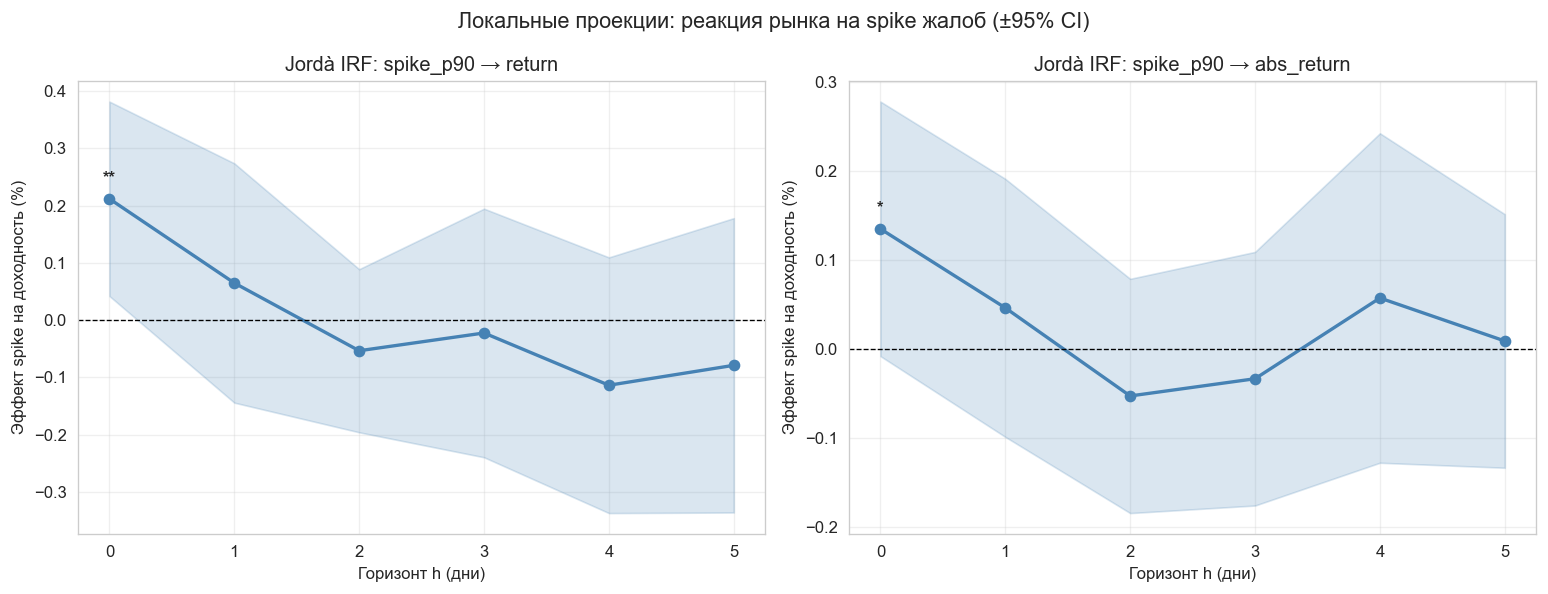


IRF: spike_p90 → return


,h,beta,se,ci_lo,ci_hi,p,Знач.,N
0,0,0.0021,0.0009,0.0004,0.0038,0.0145,**,1199
1,1,0.0006,0.0011,-0.0014,0.0027,0.5424,,1186
2,2,-0.0005,0.0007,-0.0020,0.0009,0.4621,,1173
3,3,-0.0002,0.0011,-0.0024,0.0019,0.8397,,1160
4,4,-0.0011,0.0011,-0.0034,0.0011,0.3181,,1147
5,5,-0.0008,0.0013,-0.0034,0.0018,0.5473,,1134



IRF: spike_p90 → abs_return


,h,beta,se,ci_lo,ci_hi,p,Знач.,N
0,0,0.0013,0.0007,-0.0001,0.0028,0.0650,*,1199
1,1,0.0005,0.0007,-0.0010,0.0019,0.5349,,1186
2,2,-0.0005,0.0007,-0.0018,0.0008,0.4286,,1173
3,3,-0.0003,0.0007,-0.0018,0.0011,0.6420,,1160
4,4,0.0006,0.0009,-0.0013,0.0024,0.5463,,1147
5,5,0.0001,0.0007,-0.0013,0.0015,0.9052,,1134


In [66]:
print('ЛОКАЛЬНЫЕ ПРОЕКЦИИ (JORDÀ IRF): реакция на spike жалоб')

horizons = range(0, 6)  # 0 до 5 дней вперёд
irf_results = {'return': [], 'abs_return': []}

for dv in ['return_w', 'abs_return']:
    dv_label = 'return' if 'return_w' in dv else 'abs_return'

    for h in horizons:
        # Создаём y_{t+h}
        panel_lp = panel_daily.sort_values(['company_raw', 'date']).copy()
        panel_lp[f'y_h{h}'] = panel_lp.groupby('company_raw')[dv].shift(-h)

        x_lp = ['spike_p90', 'market_return', 'lagged_return',
                 'systemic_banking_outage'] + MONTH_COLS_D
        x_lp = [c for c in x_lp if c in panel_lp.columns]

        panel_lp_clean = panel_lp.dropna(subset=[f'y_h{h}'] + x_lp)

        try:
            res = run_panel_model(
                panel_lp_clean, f'y_h{h}', x_lp,
                entity_col='company_raw', time_col='date',
                se_type='clustered', verbose=False)

            if res is not None and 'spike_p90' in res.params.index:
                ci = res.conf_int()
                irf_results[dv_label].append({
                    'h': h,
                    'beta': float(res.params['spike_p90']),
                    'se': float(res.std_errors['spike_p90']),
                    'ci_lo': float(ci.loc['spike_p90', 'lower']),
                    'ci_hi': float(ci.loc['spike_p90', 'upper']),
                    'p': float(res.pvalues['spike_p90']),
                    'N': res.nobs,
                })
        except Exception:
            pass

# Визуализация IRF
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (dv_label, data) in zip(axes, irf_results.items()):
    if not data:
        ax.set_visible(False)
        continue
    df_irf = pd.DataFrame(data)
    ax.fill_between(df_irf['h'], df_irf['ci_lo']*100, df_irf['ci_hi']*100,
                     alpha=0.2, color='steelblue')
    ax.plot(df_irf['h'], df_irf['beta']*100, 'o-', color='steelblue', linewidth=2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Горизонт h (дни)')
    ax.set_ylabel('Эффект spike на доходность (%)')
    ax.set_title(f'Jordà IRF: spike_p90 → {dv_label}')
    ax.grid(alpha=0.3)

    # Значимость
    for _, row in df_irf.iterrows():
        sig = '***' if row['p']<0.01 else ('**' if row['p']<0.05 else ('*' if row['p']<0.10 else ''))
        if sig:
            ax.annotate(sig, (row['h'], row['beta']*100),
                       textcoords="offset points", xytext=(0,10),
                       ha='center', fontsize=10, fontweight='bold')

fig.suptitle('Локальные проекции: реакция рынка на spike жалоб (±95% CI)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Fig_Jorda_IRF.png', dpi=150)
plt.show()

# Таблица IRF
for dv_label, data in irf_results.items():
    if data:
        df_irf = pd.DataFrame(data)
        df_irf['Знач.'] = df_irf['p'].apply(
            lambda p: '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else '')))
        print(f'\nIRF: spike_p90 → {dv_label}')
        display(df_irf[['h', 'beta', 'se', 'ci_lo', 'ci_hi', 'p', 'Знач.', 'N']].round(6))
        df_irf.to_csv(OUTPUT_DIR / f'Table_Jorda_IRF_{dv_label}.csv',
                      index=False, encoding='utf-8-sig')


In [67]:
print('СВОДНАЯ ТАБЛИЦА ВСЕХ ПАНЕЛЬНЫХ МОДЕЛЕЙ')


all_results = {
    'A1 Daily: event_flag': result_a1,
    'B1 Daily: log+spike': result_b1,
    'C1 Daily: расширенная': result_c1,
    'D1 Daily: spike-only': result_d1,
    'V1 Daily: |return|': result_v1,
    'V2 Daily: return²': result_v2,
    'HA Hourly: event_flag': result_ha,
    'HB Hourly: log+spike': result_hb,
    'HV Hourly: |return|': result_hv,
}

key_vars = ['event_flag', 'log_complaints', 'log_complaints_lag1',
            'spike_p90', 'spike_p90_lag1', 'market_return']

summary_rows = []
for model_name, res in all_results.items():
    if res is None:
        continue
    for var in key_vars:
        if var in res.params.index:
            p = float(res.pvalues[var])
            summary_rows.append({
                'Модель': model_name,
                'Переменная': var,
                'Коэф.': round(float(res.params[var]), 6),
                'SE': round(float(res.std_errors[var]), 6),
                't-stat': round(float(res.tstats[var]), 3),
                'p-value': round(p, 4),
                'Знач.': '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else '')),
                'R²(w)': round(res.rsquared_within, 4),
                'N': res.nobs,
            })

table_all = pd.DataFrame(summary_rows)
print('\nСводная таблица ключевых переменных:')
display(table_all)
table_all.to_csv(OUTPUT_DIR / 'Table_AllModels_Summary.csv',
                 index=False, encoding='utf-8-sig')

if len(table_all) > 0:
    pivot = table_all.pivot_table(
        index='Переменная',
        columns='Модель',
        values=['Коэф.', 'p-value'],
        aggfunc='first').round(4)
    display(pivot)
    pivot.to_csv(OUTPUT_DIR / 'Table_AllModels_Pivot.csv', encoding='utf-8-sig')


СВОДНАЯ ТАБЛИЦА ВСЕХ ПАНЕЛЬНЫХ МОДЕЛЕЙ

Сводная таблица ключевых переменных:


,Модель,Переменная,Коэф.,SE,t-stat,p-value,Знач.,R²(w),N
0,A1 Daily: event_flag,event_flag,0.0018,0.0025,0.7260,0.4677,,0.2536,1199
1,A1 Daily: event_flag,market_return,13.3999,0.9048,14.8100,0.0000,***,0.2536,1199
2,B1 Daily: log+spike,log_complaints,0.0001,0.0005,0.1190,0.9057,,0.2604,1199
3,B1 Daily: log+spike,log_complaints_lag1,-0.0006,0.0005,-1.0610,0.2889,,0.2604,1199
4,B1 Daily: log+spike,spike_p90,0.0018,0.0011,1.6460,0.1000,*,0.2604,1199
5,B1 Daily: log+spike,market_return,13.3527,0.9124,14.6350,0.0000,***,0.2604,1199
6,C1 Daily: расширенная,log_complaints,-0.0000,0.0009,-0.0450,0.9638,,0.2706,1199
7,C1 Daily: расширенная,log_complaints_lag1,-0.0003,0.0004,-0.7430,0.4576,,0.2706,1199
8,C1 Daily: расширенная,spike_p90,0.0018,0.0011,1.5330,0.1256,,0.2706,1199
9,C1 Daily: расширенная,market_return,12.4281,0.8309,14.9580,0.0000,***,0.2706,1199


p-value                      \
Модель              A1 Daily: event_flag B1 Daily: log+spike   
Переменная                                                     
event_flag                        0.4677                 NaN   
log_complaints                       NaN              0.9057   
log_complaints_lag1                  NaN              0.2889   
market_return                     0.0000              0.0000   
spike_p90                            NaN              0.1000   
spike_p90_lag1                       NaN                 NaN   

                                                                \
Модель              C1 Daily: расширенная D1 Daily: spike-only   
Переменная                                                       
event_flag                            NaN                  NaN   
log_complaints                     0.9638                  NaN   
log_complaints_lag1                0.4576                  NaN   
market_return                      0.0000               0.0000   
spike_p90                          0.1256               0.0225   
spike_p90_lag1                        NaN               0.6283   

                                                                \
Модель              HA Hourly: event_flag HB Hourly: log+spike   
Переменная                                                       
event_flag                            NaN                  NaN   
log_complaints                        NaN               0.3115   
log_complaints_lag1                   NaN               0.4978   
market_return                      0.0000               0.0000   
spike_p90                             NaN               0.6039   
spike_p90_lag1                        NaN                  NaN   

                                                                              \
Модель              HV Hourly: |return| V1 Daily: |return| V2 Daily: return²   
Переменная                                                                     
event_flag                          NaN                NaN               NaN   
log_complaints                   0.8867             0.2845            0.2614   
log_complaints_lag1                 NaN             0.0436            0.4613   
market_return                    0.0102             0.3268            0.0000   
spike_p90                        0.5362             0.3801            0.3823   
spike_p90_lag1                      NaN                NaN               NaN   

                                   Коэф.                      \
Модель              A1 Daily: event_flag B1 Daily: log+spike   
Переменная                                                     
event_flag                        0.0018                 NaN   
log_complaints                       NaN              0.0001   
log_complaints_lag1                  NaN             -0.0006   
market_return                    13.3999             13.3527   
spike_p90                            NaN              0.0018   
spike_p90_lag1                       NaN                 NaN   

                                                                \
Модель              C1 Daily: расширенная D1 Daily: spike-only   
Переменная                                                       
event_flag                            NaN                  NaN   
log_complaints                    -0.0000                  NaN   
log_complaints_lag1               -0.0003                  NaN   
market_return                     12.4281              12.6752   
spike_p90                          0.0018               0.0020   
spike_p90_lag1                        NaN               0.0004   

                                                                \
Модель              HA Hourly: event_flag HB Hourly: log+spike   
Переменная                                                       
event_flag                            NaN                  NaN   
log_complaints                        NaN              -0.0001   
log_complaints_lag1                   NaN  

---
## Проверки устойчивости 




In [68]:
#  ROBUSTNESS 1. Альтернативные пороги спайков (DAILY)
print('Robustness 1: Альтернативные пороги (DAILY, clustered SE)')

rob1_results = []
for thresh, label in [(0.85, 'P85'), (0.90, 'P90 (основной)'),
                       (0.95, 'P95'), (0.975, 'P97.5')]:
    panel_rob = panel_daily.copy()
    panel_rob['spike_thresh'] = panel_rob.groupby('company_raw')['complaints_per_mln'].transform(
        lambda x: (x > x.quantile(thresh)).astype(int))

    try:
        res = run_panel_model(
            panel_rob, 'return_w',
            ['spike_thresh', 'market_return', 'lagged_return'],
            entity_col='company_raw', time_col='date',
            se_type='clustered', verbose=False)
        if res is not None and 'spike_thresh' in res.params.index:
            rob1_results.append({
                'Порог': label,
                'Коэф.': round(float(res.params['spike_thresh']), 6),
                'SE': round(float(res.std_errors['spike_thresh']), 6),
                't-stat': round(float(res.tstats['spike_thresh']), 3),
                'p-value': round(float(res.pvalues['spike_thresh']), 4),
                'Знач.': '***' if res.pvalues['spike_thresh']<0.01 else (
                    '**' if res.pvalues['spike_thresh']<0.05 else (
                    '*' if res.pvalues['spike_thresh']<0.10 else '')),
                'N': res.nobs,
            })
    except Exception as e:
        print(f'  {label}: {e}')

# То же для |return|
rob1_vol = []
for thresh, label in [(0.85, 'P85'), (0.90, 'P90'), (0.95, 'P95'), (0.975, 'P97.5')]:
    panel_rob = panel_daily.copy()
    panel_rob['spike_thresh'] = panel_rob.groupby('company_raw')['complaints_per_mln'].transform(
        lambda x: (x > x.quantile(thresh)).astype(int))
    try:
        res = run_panel_model(
            panel_rob, 'abs_return',
            ['spike_thresh', 'market_return', 'lagged_return'],
            entity_col='company_raw', time_col='date',
            se_type='clustered', verbose=False)
        if res is not None and 'spike_thresh' in res.params.index:
            rob1_vol.append({
                'Порог': label,
                'DV': '|return|',
                'Коэф.': round(float(res.params['spike_thresh']), 6),
                'SE': round(float(res.std_errors['spike_thresh']), 6),
                't-stat': round(float(res.tstats['spike_thresh']), 3),
                'p-value': round(float(res.pvalues['spike_thresh']), 4),
                'Знач.': '***' if res.pvalues['spike_thresh']<0.01 else (
                    '**' if res.pvalues['spike_thresh']<0.05 else (
                    '*' if res.pvalues['spike_thresh']<0.10 else '')),
            })
    except Exception:
        pass

table_rob1 = pd.DataFrame(rob1_results)
print('\nReturn:')
display(table_rob1)

table_rob1_vol = pd.DataFrame(rob1_vol)
print('|Return|:')
display(table_rob1_vol)

pd.concat([table_rob1, table_rob1_vol], ignore_index=True).to_csv(
    OUTPUT_DIR / 'Table_Rob1_AltThresholds_Fixed.csv',
    index=False, encoding='utf-8-sig')


Robustness 1: Альтернативные пороги (DAILY, clustered SE)

Return:


,Порог,Коэф.,SE,t-stat,p-value,Знач.,N
0,P85,0.0003,0.0008,0.3680,0.7131,,1199
1,P90 (основной),0.0014,0.0008,1.8280,0.0678,*,1199
2,P95,0.0015,0.0014,1.0920,0.2752,,1199
3,P97.5,0.0019,0.0022,0.8530,0.3936,,1199


|Return|:


,Порог,DV,Коэф.,SE,t-stat,p-value,Знач.
0,P85,|return|,0.0018,0.0009,2.0510,0.0405,**
1,P90,|return|,0.0016,0.0008,2.1390,0.0327,**
2,P95,|return|,0.0021,0.0010,2.2350,0.0256,**
3,P97.5,|return|,0.0024,0.0017,1.4540,0.1462,


In [69]:
#  ROBUSTNESS 2. Без системных шоков
print('Robustness 2: Без системных шоков (DAILY)')
panel_no_sys = panel_daily[panel_daily['systemic_banking_outage'] == 0].copy()

x_rob2 = ['log_complaints', 'spike_p90', 'market_return', 'lagged_return']
x_rob2 = [c for c in x_rob2 if c in panel_no_sys.columns]

run_panel_model(
    panel_no_sys, 'return_w', x_rob2,
    entity_col='company_raw', time_col='date',
    se_type='clustered',
    label=f'Rob2 return: Без системных шоков (N={len(panel_no_sys)})')

run_panel_model(
    panel_no_sys, 'abs_return', x_rob2,
    entity_col='company_raw', time_col='date',
    se_type='clustered',
    label=f'Rob2 |return|: Без системных шоков (N={len(panel_no_sys)})')


Robustness 2: Без системных шоков (DAILY)

────────────────────────────────────────────────────────────
  Rob2 return: Без системных шоков (N=1173)
  entity FE | SE: clustered
  N=1173 | entities=13.0 | periods=92.0
  R²(within)=0.2573
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,-0.0002,0.0002,-0.9179,0.3588,
spike_p90,0.0020,0.0010,2.0571,0.0399,**
market_return,13.2741,0.9252,14.3473,0.0000,***
lagged_return,-0.0749,0.0224,-3.3420,0.0009,***



────────────────────────────────────────────────────────────
  Rob2 |return|: Без системных шоков (N=1173)
  entity FE | SE: clustered
  N=1173 | entities=13.0 | periods=92.0
  R²(within)=0.0049
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,0.0001,0.0003,0.4621,0.6441,
spike_p90,0.0011,0.0007,1.4998,0.1340,
market_return,0.4339,0.4386,0.9892,0.3228,
lagged_return,0.0252,0.0089,2.8446,0.0045,***


Dep. Variable:,abs_return,R-squared:,0.0049
Estimator:,PanelOLS,R-squared (Between):,-0.0404
No. Observations:,1173,R-squared (Within):,0.0049
Date:,"Thu, Apr 30 2026",R-squared (Overall):,0.0022
Time:,19:05:55,Log-likelihood,4069.0
Cov. Estimator:,Clustered,,
,,F-statistic:,1.4112
Entities:,13,P-value,0.2280
Avg Obs:,90.231,Distribution:,"F(4,1156)"
Min Obs:,88.000,,
Max Obs:,92.000,F-statistic (robust):,10.790


In [70]:
#  ROBUSTNESS 3. Без Ozon в окне редомициляции
print('Robustness 3: Без Ozon после редомициляции (DAILY)')
panel_no_ozon = panel_daily[
    ~((panel_daily['company_raw'] == 'ozon') &
      (panel_daily['date'] >= OZON_RESTRUCTURING_DATE))].copy()

x_rob3 = ['log_complaints', 'spike_p90', 'market_return', 'lagged_return']
x_rob3 = [c for c in x_rob3 if c in panel_no_ozon.columns]

run_panel_model(
    panel_no_ozon, 'return_w', x_rob3,
    entity_col='company_raw', time_col='date',
    se_type='clustered',
    label=f'Rob3: Без Ozon (N={len(panel_no_ozon)})')


Robustness 3: Без Ozon после редомициляции (DAILY)

────────────────────────────────────────────────────────────
  Rob3: Без Ozon (N=1108)
  entity FE | SE: clustered
  N=1108 | entities=12.0 | periods=94.0
  R²(within)=0.2534
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,-0.0003,0.0003,-1.1282,0.2595,
spike_p90,0.0017,0.0011,1.6029,0.1092,
market_return,12.9550,0.8896,14.5632,0.0000,***
lagged_return,-0.0708,0.0253,-2.8048,0.0051,***


Dep. Variable:,return_w,R-squared:,0.2534
Estimator:,PanelOLS,R-squared (Between):,-0.3667
No. Observations:,1108,R-squared (Within):,0.2534
Date:,"Thu, Apr 30 2026",R-squared (Overall):,0.2481
Time:,19:05:55,Log-likelihood,3583.0
Cov. Estimator:,Clustered,,
,,F-statistic:,92.656
Entities:,12,P-value,0.0000
Avg Obs:,92.333,Distribution:,"F(4,1092)"
Min Obs:,90.000,,
Max Obs:,94.000,F-statistic (robust):,56.075



### Robustness 7 и 8. Нормализация жалоб и исключение «новостных» дат


In [71]:
#  ROBUSTNESS 7. Нормированные жалобы (на млн активных пользователей)
print('=== Robustness 7: нормированные жалобы (DAILY, clustered SE) ===')


if 'complaints_per_mln' not in panel_daily.columns:
    panel_daily['users_mln']          = panel_daily['company_raw'].map(USERS_MLN)
    panel_daily['complaints_per_mln'] = panel_daily['complaints_sum'] / panel_daily['users_mln']

panel_daily['log_complaints_per_mln'] = np.log1p(panel_daily['complaints_per_mln'])
panel_daily['log_complaints_per_mln_lag1'] = (
    panel_daily.groupby('company_raw')['log_complaints_per_mln'].shift(1))

panel_daily['spike_p90_norm'] = panel_daily.groupby('company_raw')['complaints_per_mln'].transform(
    lambda x: (x > x.quantile(0.90)).astype(int))

x_rob7 = ['log_complaints_per_mln', 'log_complaints_per_mln_lag1', 'spike_p90_norm',
          'market_return', 'lagged_return']
x_rob7 = [c for c in x_rob7 if c in panel_daily.columns]

result_rob7_ret = run_panel_model(
    panel_daily, 'return_w', x_rob7,
    entity_col='company_raw', time_col='date',
    se_type='clustered',
    label='Rob7: return ~ normalized complaints')

# То же для волатильности
result_rob7_vol = run_panel_model(
    panel_daily, 'abs_return', x_rob7,
    entity_col='company_raw', time_col='date',
    se_type='clustered',
    label='Rob7: |return| ~ normalized complaints')

# Сравнение с основной моделью
comparison_rob7 = []
for label, res_main, res_norm in [
    ('return', result_b1, result_rob7_ret),
    ('|return|', result_v1, result_rob7_vol),
]:
    if res_main is None or res_norm is None:
        continue
    for var_main, var_norm in [('spike_p90', 'spike_p90_norm'),
                                ('log_complaints', 'log_complaints_per_mln')]:
        if var_main in res_main.params.index and var_norm in res_norm.params.index:
            comparison_rob7.append({
                'DV': label,
                'Абсолютные жалобы': f"{float(res_main.params[var_main]):+.5f} "
                                     f"(p={float(res_main.pvalues[var_main]):.3f})",
                'Нормированные жалобы': f"{float(res_norm.params[var_norm]):+.5f} "
                                        f"(p={float(res_norm.pvalues[var_norm]):.3f})",
                'Переменная': f'{var_main} vs {var_norm}',
            })

if comparison_rob7:
    table_rob7 = pd.DataFrame(comparison_rob7)
    print('\nСравнение с основными моделями:')
    display(table_rob7)
    table_rob7.to_csv(OUTPUT_DIR / 'Table_Rob7_Normalized_Comparison.csv',
                      index=False, encoding='utf-8-sig')
 


=== Robustness 7: нормированные жалобы (DAILY, clustered SE) ===

────────────────────────────────────────────────────────────
  Rob7: return ~ normalized complaints
  entity FE | SE: clustered
  N=1186 | entities=13.0 | periods=93.0
  R²(within)=0.2621
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints_per_mln,0.0002,0.0006,0.3517,0.7252,
log_complaints_per_mln_lag1,-0.0008,0.0006,-1.2989,0.1942,
spike_p90_norm,0.0017,0.0011,1.5115,0.1309,
market_return,13.3612,0.9204,14.5163,0.0000,***
lagged_return,-0.0613,0.0200,-3.0704,0.0022,***



────────────────────────────────────────────────────────────
  Rob7: |return| ~ normalized complaints
  entity FE | SE: clustered
  N=1186 | entities=13.0 | periods=93.0
  R²(within)=0.0089
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints_per_mln,0.0005,0.0003,1.6219,0.1051,
log_complaints_per_mln_lag1,-0.0006,0.0003,-2.1178,0.0344,**
spike_p90_norm,0.0012,0.0007,1.6347,0.1024,
market_return,0.2736,0.4269,0.6409,0.5217,
lagged_return,0.0241,0.0075,3.2072,0.0014,***



Сравнение с основными моделями:


,DV,Абсолютные жалобы,Нормированные жалобы,Переменная
0,return,+0.00177 (p=0.100),+0.00165 (p=0.131),spike_p90 vs spike_p90_norm
1,return,+0.00006 (p=0.906),+0.00021 (p=0.725),log_complaints vs log_complaints_per_mln
2,|return|,+0.00084 (p=0.380),+0.00121 (p=0.102),spike_p90 vs spike_p90_norm
3,|return|,+0.00053 (p=0.285),+0.00053 (p=0.105),log_complaints vs log_complaints_per_mln


In [72]:
#  ROBUSTNESS 8. Исключение дат, совпавших с позитивными
print('=== Robustness 8: без «новостных» дат (DAILY, clustered SE) ===')

if 'outlier_dates' in dir() and len(outlier_dates) > 0:
    mask = panel_daily.apply(
        lambda r: (r['date'].date(), r['company_raw']) not in outlier_dates,
        axis=1)
    panel_rob8 = panel_daily[mask].copy()
    excluded = len(panel_daily) - len(panel_rob8)
    print(f'Исключено строк: {excluded} '
          f'(из {len(panel_daily)}) — даты, совпавшие с позитивными новостями.')

    x_rob8 = ['log_complaints', 'spike_p90', 'market_return', 'lagged_return']
    x_rob8 = [c for c in x_rob8 if c in panel_rob8.columns]

    result_rob8_ret = run_panel_model(
        panel_rob8, 'return_w', x_rob8,
        entity_col='company_raw', time_col='date',
        se_type='clustered',
        label=f'Rob8: return без новостных дат (N={len(panel_rob8)})')

    result_rob8_vol = run_panel_model(
        panel_rob8, 'abs_return', x_rob8,
        entity_col='company_raw', time_col='date',
        se_type='clustered',
        label=f'Rob8: |return| без новостных дат (N={len(panel_rob8)})')


=== Robustness 8: без «новостных» дат (DAILY, clustered SE) ===
Исключено строк: 2 (из 1199) — даты, совпавшие с позитивными новостями.

────────────────────────────────────────────────────────────
  Rob8: return без новостных дат (N=1197)
  entity FE | SE: clustered
  N=1197 | entities=13.0 | periods=94.0
  R²(within)=0.2584
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,-0.0003,0.0003,-1.2676,0.2052,
spike_p90,0.0019,0.0010,1.8622,0.0628,*
market_return,13.3484,0.9118,14.6397,0.0000,***
lagged_return,-0.0632,0.0245,-2.5838,0.0099,***



────────────────────────────────────────────────────────────
  Rob8: |return| без новостных дат (N=1197)
  entity FE | SE: clustered
  N=1197 | entities=13.0 | periods=94.0
  R²(within)=0.0049
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,0.0001,0.0003,0.4478,0.6544,
spike_p90,0.0011,0.0008,1.4835,0.1382,
market_return,0.3074,0.4428,0.6943,0.4877,
lagged_return,0.0259,0.0090,2.8781,0.0041,***


In [73]:

#  ROBUSTNESS 5. Hausman Test: FE vs RE

x_haus = ['log_complaints', 'spike_p90', 'market_return', 'lagged_return']
x_haus = [c for c in x_haus if c in panel_daily.columns]

cols_needed = ['company_raw', 'date', 'return_w'] + x_haus
df_haus = panel_daily[cols_needed].dropna().copy()
df_haus_idx = df_haus.set_index(['company_raw', 'date'])
y_haus = df_haus_idx['return_w']
X_haus = sm.add_constant(df_haus_idx[x_haus].astype(float))

# FE
fe_model = PanelOLS(y_haus, X_haus, entity_effects=True,
                     drop_absorbed=True, check_rank=False)
fe_result = fe_model.fit(cov_type='clustered', cluster_entity=True)

# RE
re_model = RandomEffects(y_haus, X_haus)
re_result = re_model.fit(cov_type='clustered', cluster_entity=True)

print('\nFixed Effects:')
print(fe_result.params.drop('const', errors='ignore'))
print('\nRandom Effects:')
print(re_result.params.drop('const', errors='ignore'))


b_fe = fe_result.params.drop('const', errors='ignore')
b_re = re_result.params.drop('const', errors='ignore')
common = b_fe.index.intersection(b_re.index)
diff = (b_fe[common] - b_re[common]).values
V_fe = fe_result.cov.loc[common, common].values
V_re = re_result.cov.loc[common, common].values
V_diff = V_fe - V_re

try:
    hausman_stat = float(diff.T @ np.linalg.inv(V_diff) @ diff)
    hausman_p = 1 - stats.chi2.cdf(hausman_stat, df=len(common))
    print(f'\nHausman test: χ² = {hausman_stat:.3f}, p = {hausman_p:.4f}')
    print('[!] H0: RE consistent => если p < 0.05, используем FE.')
    if hausman_p < 0.05:
        print('=> ОТВЕРГАЕМ H0: FE предпочтительнее (есть корреляция αᵢ с X).')
    else:
        print('=> НЕ ОТВЕРГАЕМ H0: RE допустимы.')
except np.linalg.LinAlgError:
    print('\nHausman test: матрица вырождена, FE рекомендуется по умолчанию.')



Fixed Effects:
log_complaints   -0.0003
spike_p90         0.0020
market_return    13.3682
lagged_return    -0.0666
Name: parameter, dtype: float64

Random Effects:
log_complaints   -0.0002
spike_p90         0.0018
market_return    13.3342
lagged_return    -0.0585
Name: parameter, dtype: float64

Hausman test: χ² = -2.593, p = 1.0000
[!] H0: RE consistent => если p < 0.05, используем FE.
=> НЕ ОТВЕРГАЕМ H0: RE допустимы.


In [74]:
print('=== Robustness 6: entity FE vs entity+time FE (DAILY) ===')

x_r6 = ['log_complaints', 'spike_p90', 'market_return', 'lagged_return']
x_r6 = [c for c in x_r6 if c in panel_daily.columns]

print('\n--- A: Entity FE only ---')
run_panel_model(
    panel_daily, 'return_w', x_r6,
    entity_col='company_raw', time_col='date',
    entity_effects=True, time_effects=False,
    se_type='clustered',
    label='Entity FE only (DAILY)')

print('\n--- B: Entity + Time FE ---')
# Для time FE убираем market_return 
x_r6b = ['log_complaints', 'spike_p90', 'lagged_return']
x_r6b = [c for c in x_r6b if c in panel_daily.columns]
run_panel_model(
    panel_daily, 'return_w', x_r6b,
    entity_col='company_raw', time_col='date',
    entity_effects=True, time_effects=True,
    se_type='clustered',
    label='Entity + Time FE (DAILY)')


=== Robustness 6: entity FE vs entity+time FE (DAILY) ===

--- A: Entity FE only ---

────────────────────────────────────────────────────────────
  Entity FE only (DAILY)
  entity FE | SE: clustered
  N=1199 | entities=13.0 | periods=94.0
  R²(within)=0.2592
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,-0.0003,0.0003,-1.2392,0.2155,
spike_p90,0.0020,0.0010,1.9748,0.0485,**
market_return,13.3682,0.9183,14.5575,0.0000,***
lagged_return,-0.0666,0.0234,-2.8508,0.0044,***



--- B: Entity + Time FE ---

────────────────────────────────────────────────────────────
  Entity + Time FE (DAILY)
  entity FE, time FE | SE: clustered
  N=1199 | entities=13.0 | periods=94.0
  R²(within)=0.0057
────────────────────────────────────────────────────────────


,Коэф.,SE,t-stat,p-value,Знач.
log_complaints,-0.0001,0.0006,-0.1999,0.8416,
spike_p90,0.0020,0.0009,2.2934,0.0220,**
lagged_return,-0.0717,0.0229,-3.1330,0.0018,***


Dep. Variable:,return_w,R-squared:,0.0093
Estimator:,PanelOLS,R-squared (Between):,-0.1126
No. Observations:,1199,R-squared (Within):,0.0057
Date:,"Thu, Apr 30 2026",R-squared (Overall):,0.0047
Time:,19:05:56,Log-likelihood,4028.8
Cov. Estimator:,Clustered,,
,,F-statistic:,3.4234
Entities:,13,P-value,0.0167
Avg Obs:,92.231,Distribution:,"F(3,1090)"
Min Obs:,90.000,,
Max Obs:,94.000,F-statistic (robust):,7.0182


---
## Итоговый реестр сохранённых файлов

In [75]:
saved_files = sorted(OUTPUT_DIR.glob('*'))
print(f'Всего сохранено файлов: {len(saved_files)}')
print()
for f in saved_files:
    size = f.stat().st_size / 1024
    print(f'  {f.name:<55} {size:>7.1f} KB')

print()
print('='*65)
print('Все этапы исследования выполнены.')
print('Таблицы (.csv) и рисунки (.png) сохранены в папку:', OUTPUT_DIR.resolve())

Всего сохранено файлов: 55

  Fig_2_12_AR_Boxplot_Sectors.png                            96.4 KB
  Fig_A1_CoverageGantt.png                                   58.8 KB
  Fig_A2_TotalComplaints.png                                 61.2 KB
  Fig_B1_DailyComplaints.png                                493.5 KB
  Fig_B2_BoxplotComplaints.png                               89.2 KB
  Fig_B3_DensityComplaints.png                               62.9 KB
  Fig_B4_SeasonalHeatmap.png                                 47.6 KB
  Fig_C1_TopTagsEvents.png                                   62.9 KB
  Fig_C2_RegionalComplaints.png                              36.7 KB
  Fig_Coefficients_Corrected.png                             73.7 KB
  Fig_D1_NormalizedPrices.png                               295.8 KB
  Fig_D2_CorrelationHeatmap_Hourly.png                       72.2 KB
  Fig_D2_DailyReturns.png                                   308.5 KB
  Fig_E1_EventsOnTimeSeries.png                             427.7 KB
  Fig_